# Importing Packages 

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.ticker as mtick
import os
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score, 
    train_test_split, 
    GridSearchCV, 
    KFold, 
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.utils import resample
from sklearn.metrics import (
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_recall_curve,
    roc_curve,
    average_precision_score
)
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning, UndefinedMetricWarning

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import shap

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")

# Import data and EDA

## enrollment.csv

In [319]:
# Read in the data and take an initial look at the datasets
df_enrollment = pd.read_csv("csv/enrollment.csv")
display(df_enrollment.head())
display(df_enrollment.shape)


,enrollment_id,username,course_id
0,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila
1,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx
2,7,I1KwJ6EdCZnEPLfC8Q7yWpIkLOHn7h02,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx
3,13,hDbSkVrFRj9Ryk3c5E1JYJQLyxm4jLRb,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2
4,14,XOhIczT5nEeO52jMq1vN7QziDk8L2jnI,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila


(72394, 3)

In [13]:
# Check the number of unique users & course_id
unique_users = df_enrollment.username.nunique() 
unique_courses = df_enrollment.course_id.nunique()
print(f"Number of unique users: {unique_users}")
print(f"Number of unique courses: {unique_courses}")


Number of unique users: 53870
Number of unique courses: 39


There are 53,870 users enrolled in 39 unique courses, with a total of 72,394 enrollments. This indicates that, as mentioned in the instructions, each user can enroll in multiple courses.

## log.csv

In [321]:
# Read in the data and take an initial look at the datasets
df_log = pd.read_csv("csv/log.csv")
#display(df_log.head(20))
display(df_log.shape)
display(df_log.event.unique())

(4880067, 5)

array(['navigate', 'access', 'page_close', 'video', 'problem',
       'discussion', 'wiki'], dtype=object)

In [17]:
# Check the number of unique enrollment_id
display(df_log.enrollment_id.nunique())


72394

In [18]:
# Check for values associated with a specific enrollment
display(df_log[df_log.enrollment_id == 4])


,enrollment_id,time,source,event,object
0,4,2014-06-15T01:44:10,server,navigate,Oj6eQgzrdqBMlaCtaq1IkY6zruSrb71b
1,4,2014-06-15T01:44:13,server,access,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl
2,4,2014-06-15T01:44:13,server,access,qxvBNYTfiRkNcCvM0hcGwG6hvHdQwnd4
3,4,2014-06-15T01:44:35,server,access,LPxTHNUu4a88wyAL6vY8ebFrjaaySuKo
4,4,2014-06-15T02:05:21,server,access,ep57uq0N5Fxg1Irgy68ROj8HOuD4xbsi
...,...,...,...,...,...
94,4,2014-07-02T11:32:32,server,navigate,vPJ7ada7OqDfvYXMjnTQC3NExmLvWiUL
95,4,2014-07-02T11:32:33,browser,page_close,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl
96,4,2014-07-02T11:32:39,server,access,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl
97,4,2014-07-02T11:32:39,server,access,W2Za6xuXb0ETxjM50i4un55AGtcvHbBP


In [19]:
# Aggregate information for a specific enrollment, including as much detail as possible
df_log_dist_enroll_4 = df_log[df_log.enrollment_id == 4].groupby(['source', 'event', 'object']).agg({'time': ['min', 'max']}).reset_index()
 
df_log_dist_enroll_4.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_enroll_4.columns] 

display(df_log_dist_enroll_4)


,source,event,object,time_min,time_max
0,browser,page_close,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl,2014-06-15T02:27:52,2014-07-02T11:32:47
1,browser,problem,RMtgC2bTAqEeftenUUyia504wsyzeZWf,2014-06-16T00:47:20,2014-06-16T00:48:26
2,browser,problem,xg4ghT4Nbdoh1Z8Z3T5CQbggmtFxrnD7,2014-06-25T13:15:08,2014-06-25T13:15:08
3,browser,video,B5d404cq3fvYiuV0CZGRdIj5YiDNRLAq,2014-06-15T02:27:52,2014-06-15T02:27:52
4,browser,video,QfvY7s9HFrUNFIn7A5lwQo5mfY82kOHZ,2014-06-15T08:37:53,2014-06-15T08:37:53
5,browser,video,WFM7EIUwEpr7qhJJjRi5RtxtLBUyJIGb,2014-06-25T13:15:13,2014-06-26T13:33:50
6,server,access,1Q5vBuafwY9UtwES85wN8NM0ARi2qQFS,2014-06-15T02:27:12,2014-06-15T02:31:16
7,server,access,2cmZrZW2h6Il91itO3e89FGcABLWhf3W,2014-06-16T00:42:44,2014-06-16T00:42:44
8,server,access,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl,2014-06-15T01:44:13,2014-07-02T11:32:39
9,server,access,7hDDi7yn0BwBjuDSc85J1ijuI4RJ2Cfm,2014-06-23T03:04:31,2014-06-25T12:36:44


In [20]:
# Calculate time lapse for each event
df_log_dist_enroll_4['time_min'] = pd.to_datetime(df_log_dist_enroll_4['time_min'])
df_log_dist_enroll_4['time_max'] = pd.to_datetime(df_log_dist_enroll_4['time_max'])
df_log_dist_enroll_4['time_lapse'] = df_log_dist_enroll_4['time_max'] - df_log_dist_enroll_4['time_min']

# Display the dataframe with the calculated time lapse
display(df_log_dist_enroll_4)


,source,event,object,time_min,time_max,time_lapse
0,browser,page_close,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl,2014-06-15 02:27:52,2014-07-02 11:32:47,17 days 09:04:55
1,browser,problem,RMtgC2bTAqEeftenUUyia504wsyzeZWf,2014-06-16 00:47:20,2014-06-16 00:48:26,0 days 00:01:06
2,browser,problem,xg4ghT4Nbdoh1Z8Z3T5CQbggmtFxrnD7,2014-06-25 13:15:08,2014-06-25 13:15:08,0 days 00:00:00
3,browser,video,B5d404cq3fvYiuV0CZGRdIj5YiDNRLAq,2014-06-15 02:27:52,2014-06-15 02:27:52,0 days 00:00:00
4,browser,video,QfvY7s9HFrUNFIn7A5lwQo5mfY82kOHZ,2014-06-15 08:37:53,2014-06-15 08:37:53,0 days 00:00:00
5,browser,video,WFM7EIUwEpr7qhJJjRi5RtxtLBUyJIGb,2014-06-25 13:15:13,2014-06-26 13:33:50,1 days 00:18:37
6,server,access,1Q5vBuafwY9UtwES85wN8NM0ARi2qQFS,2014-06-15 02:27:12,2014-06-15 02:31:16,0 days 00:04:04
7,server,access,2cmZrZW2h6Il91itO3e89FGcABLWhf3W,2014-06-16 00:42:44,2014-06-16 00:42:44,0 days 00:00:00
8,server,access,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl,2014-06-15 01:44:13,2014-07-02 11:32:39,17 days 09:48:26
9,server,access,7hDDi7yn0BwBjuDSc85J1ijuI4RJ2Cfm,2014-06-23 03:04:31,2014-06-25 12:36:44,2 days 09:32:13


In [21]:
# Aggregate all information into one row for a specific enrollment
df_log_dist_enroll_4 = df_log[df_log.enrollment_id == 4].groupby(['event']).agg({
    'source': 'nunique', 
    'object': ['nunique', 'count'], 
    'time': ['min', 'max']
}).reset_index()

# Rename the columns to combine two levels into one by joining names with an underscore
df_log_dist_enroll_4.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_enroll_4.columns]

# Convert time columns to datetime
df_log_dist_enroll_4['time_min'] = pd.to_datetime(df_log_dist_enroll_4['time_min'])
df_log_dist_enroll_4['time_max'] = pd.to_datetime(df_log_dist_enroll_4['time_max'])

# Calculate time lapse
df_log_dist_enroll_4['time_lapse'] = df_log_dist_enroll_4['time_max'] - df_log_dist_enroll_4['time_min']

# Drop the original time_min and time_max columns 
df_log_dist_enroll_4.drop(columns=['time_min', 'time_max'], inplace=True)  #inplace=True：直接在原 DataFrame df 上修改

# Display the aggregated dataframe
display(df_log_dist_enroll_4)


,event,source_nunique,object_nunique,object_count,time_lapse
0,access,1,20,64,17 days 09:48:26
1,navigate,1,4,15,17 days 09:48:22
2,page_close,1,1,10,17 days 09:04:55
3,problem,2,2,6,9 days 12:27:48
4,video,1,3,4,11 days 11:05:58


## Form a feature portrait

In [23]:
# Aggregate data for all enrollments
df_log_dist = df_log.groupby(['enrollment_id', 'event']).agg({
    'object': ['nunique', 'count'], 
    'time': ['min', 'max']
}).reset_index()

# Rename the columns to combine two levels into one by joining names with an underscore
df_log_dist.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist.columns]

# Convert time columns to datetime
df_log_dist['time_min'] = pd.to_datetime(df_log_dist['time_min'])
df_log_dist['time_max'] = pd.to_datetime(df_log_dist['time_max'])

# Calculate time lapse
df_log_dist['time_lapse'] = df_log_dist['time_max'] - df_log_dist['time_min']

# Drop the original time_min and time_max columns
df_log_dist.drop(columns=['time_min', 'time_max'], inplace=True)
# object_nunique_xxx: How many different objects has this user touched on a certain event type? 
# object_count_xxx: How many objects has this user triggered in total on a certain event type? 
# time_lapse_xxx: How much time has been accumulated on this event type

# Pivot the table to get a wide-format dataframe   
df_log_dist_pivot = pd.pivot_table(df_log_dist, values=['object_nunique', 'object_count', 'time_lapse'], index='enrollment_id', columns='event').reset_index()

# Pivot the table to sum the time_lapse for each event                     
df_log_dist_pivot_time_lapse = pd.pivot_table(df_log_dist, values=['time_lapse'], index='enrollment_id', columns='event', aggfunc='sum').reset_index()

# Rename the columns to combine two levels into one by joining names with an underscore
df_log_dist_pivot.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_pivot.columns]
df_log_dist_pivot_time_lapse.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_pivot_time_lapse.columns]

# Display the head and shape of the pivot tables
print("Pivot Table:")
display(df_log_dist_pivot.head(50))
print("Shape:", df_log_dist_pivot.shape)

print("\nPivot Table with Time Lapse Sum:")
display(df_log_dist_pivot_time_lapse.head())
print("Shape:", df_log_dist_pivot_time_lapse.shape)


Pivot Table:


,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,...,object_nunique_problem,object_nunique_video,object_nunique_wiki,time_lapse_access,time_lapse_discussion,time_lapse_navigate,time_lapse_page_close,time_lapse_problem,time_lapse_video,time_lapse_wiki
0,4,64.0,NaN,15.0,10.0,6.0,4.0,NaN,20.0,NaN,...,2.0,3.0,NaN,17 days 09:48:26,NaT,17 days 09:48:22,17 days 09:04:55,9 days 12:27:48,11 days 11:05:58,NaT
1,5,226.0,34.0,30.0,87.0,170.0,86.0,NaN,27.0,1.0,...,41.0,38.0,NaN,27 days 19:14:39,21 days 00:55:04,29 days 13:04:14,27 days 15:33:34,27 days 15:29:23,27 days 19:05:06,NaT
2,7,203.0,33.0,20.0,60.0,94.0,69.0,NaN,27.0,1.0,...,27.0,27.0,NaN,25 days 23:34:20,4 days 02:36:31,25 days 23:31:56,25 days 23:33:30,18 days 22:30:36,25 days 23:33:29,NaT
3,13,200.0,4.0,15.0,25.0,150.0,69.0,NaN,25.0,1.0,...,39.0,35.0,NaN,22 days 18:19:01,0 days 00:00:40,22 days 18:15:13,22 days 00:34:49,5 days 07:49:58,22 days 00:34:48,NaT
4,14,60.0,NaN,20.0,5.0,12.0,5.0,NaN,31.0,NaN,...,3.0,5.0,NaN,15 days 23:56:52,NaT,15 days 23:15:03,13 days 00:41:55,10 days 10:20:34,13 days 00:41:56,NaT
5,18,90.0,3.0,14.0,18.0,17.0,10.0,1.0,27.0,1.0,...,3.0,9.0,1.0,25 days 11:52:18,0 days 00:11:15,25 days 11:41:21,23 days 04:33:12,25 days 01:29:07,10 days 11:04:20,0 days 00:00:00
6,20,59.0,1.0,35.0,34.0,NaN,12.0,1.0,14.0,1.0,...,NaN,7.0,1.0,24 days 13:54:06,0 days 00:00:00,24 days 13:46:28,24 days 13:54:44,NaT,24 days 13:37:22,0 days 00:00:00
7,22,66.0,NaN,1.0,38.0,64.0,36.0,NaN,15.0,NaN,...,14.0,19.0,NaN,1 days 00:17:30,NaT,0 days 00:00:00,1 days 00:13:46,0 days 23:50:45,0 days 23:33:44,NaT
8,23,53.0,NaN,18.0,28.0,NaN,14.0,NaN,10.0,NaN,...,NaN,7.0,NaN,18 days 08:21:38,NaT,18 days 08:21:39,18 days 08:19:12,NaT,6 days 22:07:44,NaT
9,26,146.0,1.0,21.0,61.0,5.0,31.0,NaN,24.0,1.0,...,2.0,13.0,NaN,8 days 05:13:23,0 days 00:00:00,8 days 05:54:35,8 days 05:55:10,1 days 03:56:24,8 days 04:41:10,NaT


Shape: (72394, 22)

Pivot Table with Time Lapse Sum:


,enrollment_id,time_lapse_access,time_lapse_discussion,time_lapse_navigate,time_lapse_page_close,time_lapse_problem,time_lapse_video,time_lapse_wiki
0,4,17 days 09:48:26,NaT,17 days 09:48:22,17 days 09:04:55,9 days 12:27:48,11 days 11:05:58,NaT
1,5,27 days 19:14:39,21 days 00:55:04,29 days 13:04:14,27 days 15:33:34,27 days 15:29:23,27 days 19:05:06,NaT
2,7,25 days 23:34:20,4 days 02:36:31,25 days 23:31:56,25 days 23:33:30,18 days 22:30:36,25 days 23:33:29,NaT
3,13,22 days 18:19:01,0 days 00:00:40,22 days 18:15:13,22 days 00:34:49,5 days 07:49:58,22 days 00:34:48,NaT
4,14,15 days 23:56:52,NaT,15 days 23:15:03,13 days 00:41:55,10 days 10:20:34,13 days 00:41:56,NaT


Shape: (72394, 8)


In [25]:
# Merge df_log_dist_pivot & df_log_dist_pivot_time_lasps datasets 
df_log_dist_pivot = df_log_dist_pivot.merge(df_log_dist_pivot_time_lapse, on = 'enrollment_id', how='left')
display(df_log_dist_pivot.head())
display(df_log_dist_pivot.shape)


,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,...,time_lapse_problem_x,time_lapse_video_x,time_lapse_wiki_x,time_lapse_access_y,time_lapse_discussion_y,time_lapse_navigate_y,time_lapse_page_close_y,time_lapse_problem_y,time_lapse_video_y,time_lapse_wiki_y
0,4,64.0,NaN,15.0,10.0,6.0,4.0,NaN,20.0,NaN,...,9 days 12:27:48,11 days 11:05:58,NaT,17 days 09:48:26,NaT,17 days 09:48:22,17 days 09:04:55,9 days 12:27:48,11 days 11:05:58,NaT
1,5,226.0,34.0,30.0,87.0,170.0,86.0,NaN,27.0,1.0,...,27 days 15:29:23,27 days 19:05:06,NaT,27 days 19:14:39,21 days 00:55:04,29 days 13:04:14,27 days 15:33:34,27 days 15:29:23,27 days 19:05:06,NaT
2,7,203.0,33.0,20.0,60.0,94.0,69.0,NaN,27.0,1.0,...,18 days 22:30:36,25 days 23:33:29,NaT,25 days 23:34:20,4 days 02:36:31,25 days 23:31:56,25 days 23:33:30,18 days 22:30:36,25 days 23:33:29,NaT
3,13,200.0,4.0,15.0,25.0,150.0,69.0,NaN,25.0,1.0,...,5 days 07:49:58,22 days 00:34:48,NaT,22 days 18:19:01,0 days 00:00:40,22 days 18:15:13,22 days 00:34:49,5 days 07:49:58,22 days 00:34:48,NaT
4,14,60.0,NaN,20.0,5.0,12.0,5.0,NaN,31.0,NaN,...,10 days 10:20:34,13 days 00:41:56,NaT,15 days 23:56:52,NaT,15 days 23:15:03,13 days 00:41:55,10 days 10:20:34,13 days 00:41:56,NaT


(72394, 29)

In [27]:
# Calculate the total time used for each enrollment_id
df_log_dist_time_lapse_total = df_log.groupby(['enrollment_id']).agg({'time': ['min', 'max']}).reset_index()

# Rename the columns to combine two levels into one by joining names with an underscore
df_log_dist_time_lapse_total.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_time_lapse_total.columns]

# Convert time columns to datetime
df_log_dist_time_lapse_total['time_min'] = pd.to_datetime(df_log_dist_time_lapse_total['time_min'])
df_log_dist_time_lapse_total['time_max'] = pd.to_datetime(df_log_dist_time_lapse_total['time_max'])

# Calculate time lapse
df_log_dist_time_lapse_total['time_lapse'] = df_log_dist_time_lapse_total['time_max'] - df_log_dist_time_lapse_total['time_min']

# Display the dataframe with time lapse
print("Time Lapse Total (Before Dropping time_min and time_max):")
display(df_log_dist_time_lapse_total.head())
print("Shape:", df_log_dist_time_lapse_total.shape)

# Drop the original time_min and time_max columns
df_log_dist_time_lapse_total.drop(columns=['time_min', 'time_max'], inplace=True)

# Display the dataframe after dropping time_min and time_max
print("\nTime Lapse Total (After Dropping time_min and time_max):")
display(df_log_dist_time_lapse_total.head())
print("Shape:", df_log_dist_time_lapse_total.shape)


Time Lapse Total (Before Dropping time_min and time_max):


,enrollment_id,time_min,time_max,time_lapse
0,4,2014-06-15 01:44:10,2014-07-02 11:32:47,17 days 09:48:37
1,5,2014-06-19 05:41:37,2014-07-18 23:08:33,29 days 17:26:56
2,7,2014-06-19 00:55:01,2014-07-15 00:29:59,25 days 23:34:58
3,13,2014-06-12 17:24:33,2014-07-05 11:43:45,22 days 18:19:12
4,14,2014-06-22 15:20:18,2014-07-08 15:25:52,16 days 00:05:34


Shape: (72394, 4)

Time Lapse Total (After Dropping time_min and time_max):


,enrollment_id,time_lapse
0,4,17 days 09:48:37
1,5,29 days 17:26:56
2,7,25 days 23:34:58
3,13,22 days 18:19:12
4,14,16 days 00:05:34


Shape: (72394, 2)


In [28]:
# Merge df_log_dist_pivot & df_log_dist_time_lapse_total datasets
df_log_dist_pivot = df_log_dist_pivot.merge(df_log_dist_time_lapse_total, on = 'enrollment_id', how='left')
display(df_log_dist_pivot.head())
display(df_log_dist_pivot.shape)


,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,...,time_lapse_video_x,time_lapse_wiki_x,time_lapse_access_y,time_lapse_discussion_y,time_lapse_navigate_y,time_lapse_page_close_y,time_lapse_problem_y,time_lapse_video_y,time_lapse_wiki_y,time_lapse
0,4,64.0,NaN,15.0,10.0,6.0,4.0,NaN,20.0,NaN,...,11 days 11:05:58,NaT,17 days 09:48:26,NaT,17 days 09:48:22,17 days 09:04:55,9 days 12:27:48,11 days 11:05:58,NaT,17 days 09:48:37
1,5,226.0,34.0,30.0,87.0,170.0,86.0,NaN,27.0,1.0,...,27 days 19:05:06,NaT,27 days 19:14:39,21 days 00:55:04,29 days 13:04:14,27 days 15:33:34,27 days 15:29:23,27 days 19:05:06,NaT,29 days 17:26:56
2,7,203.0,33.0,20.0,60.0,94.0,69.0,NaN,27.0,1.0,...,25 days 23:33:29,NaT,25 days 23:34:20,4 days 02:36:31,25 days 23:31:56,25 days 23:33:30,18 days 22:30:36,25 days 23:33:29,NaT,25 days 23:34:58
3,13,200.0,4.0,15.0,25.0,150.0,69.0,NaN,25.0,1.0,...,22 days 00:34:48,NaT,22 days 18:19:01,0 days 00:00:40,22 days 18:15:13,22 days 00:34:49,5 days 07:49:58,22 days 00:34:48,NaT,22 days 18:19:12
4,14,60.0,NaN,20.0,5.0,12.0,5.0,NaN,31.0,NaN,...,13 days 00:41:56,NaT,15 days 23:56:52,NaT,15 days 23:15:03,13 days 00:41:55,10 days 10:20:34,13 days 00:41:56,NaT,16 days 00:05:34


(72394, 30)

In [30]:
# Count the unique events, objects, and sources associated with each enrollment_id 
df_log_dist_event_object_sources = df_log.groupby(['enrollment_id']).agg({
    'event': 'nunique', 
    'object': ['nunique', 'count'], 
    'source': 'nunique'
}).reset_index()

# Rename the columns to combine two levels into one by joining names with an underscore
df_log_dist_event_object_sources.columns = ['_'.join(col) if col[1] != '' else col[0] for col in df_log_dist_event_object_sources.columns]

# Display the dataframe with counts of events, objects, and sources
print("Event/Object/Source Counts for Each Enrollment:")
display(df_log_dist_event_object_sources.head())
print("Shape:", df_log_dist_event_object_sources.shape)

# Display the unique counts of sources
print("\nUnique Counts of Sources:")
display(df_log_dist_event_object_sources.source_nunique.unique())


Event/Object/Source Counts for Each Enrollment:


,enrollment_id,event_nunique,object_nunique,object_count,source_nunique
0,4,5,29,99,2
1,5,6,111,633,2
2,7,6,86,479,2
3,13,6,100,463,2
4,14,5,44,102,2


Shape: (72394, 5)

Unique Counts of Sources:


array([2, 1])

In [31]:
# Merge df_log_dist_pivot & df_log_dist_event_object_sources datasets
df_log_dist_pivot = df_log_dist_pivot.merge(df_log_dist_event_object_sources, on='enrollment_id', how='left')
display(df_log_dist_pivot.head())
display(df_log_dist_pivot.shape)


,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,...,time_lapse_navigate_y,time_lapse_page_close_y,time_lapse_problem_y,time_lapse_video_y,time_lapse_wiki_y,time_lapse,event_nunique,object_nunique,object_count,source_nunique
0,4,64.0,NaN,15.0,10.0,6.0,4.0,NaN,20.0,NaN,...,17 days 09:48:22,17 days 09:04:55,9 days 12:27:48,11 days 11:05:58,NaT,17 days 09:48:37,5,29,99,2
1,5,226.0,34.0,30.0,87.0,170.0,86.0,NaN,27.0,1.0,...,29 days 13:04:14,27 days 15:33:34,27 days 15:29:23,27 days 19:05:06,NaT,29 days 17:26:56,6,111,633,2
2,7,203.0,33.0,20.0,60.0,94.0,69.0,NaN,27.0,1.0,...,25 days 23:31:56,25 days 23:33:30,18 days 22:30:36,25 days 23:33:29,NaT,25 days 23:34:58,6,86,479,2
3,13,200.0,4.0,15.0,25.0,150.0,69.0,NaN,25.0,1.0,...,22 days 18:15:13,22 days 00:34:49,5 days 07:49:58,22 days 00:34:48,NaT,22 days 18:19:12,6,100,463,2
4,14,60.0,NaN,20.0,5.0,12.0,5.0,NaN,31.0,NaN,...,15 days 23:15:03,13 days 00:41:55,10 days 10:20:34,13 days 00:41:56,NaT,16 days 00:05:34,5,44,102,2


(72394, 34)

I aggregated the data to analyze the activity of each enrollment_id, preparing it for a subsequent merge and the final machine learning model building.



## demographics.csv  

In [314]:
# Read in the data and take an initial look at the datasets
df_demographics = pd.read_csv("csv/demographics.csv")
display(df_demographics.head())
display(df_demographics.shape)


,username,gender,zip,highest_education
0,1ifSECGbSNOVMlDLiaHn3qIiep1xTruH,missing,15909,graduate
1,J7qSizLnQ0QAyxNWuoJFZmoENjvDHIBE,missing,60073,highschool
2,arO9I6f9CFBFHGxZhxQW6c433v3nbn9v,NaN,93428,some college
3,J6dRRTe1g3KLM8fQLfl7rrnqU1BufMgl,missing,1220,some college
4,tBYNgYMLcaid5WsG2NgVjslnqBmTbXuo,male,20747,highschool


(53870, 4)

In [35]:
# Check the number of unique username and zip
display(df_demographics.username.nunique())
list_df_demographics_zip = df_demographics.zip.unique().tolist()   #两种方法，都得到唯一值
display(len(list_df_demographics_zip))
display(df_demographics.zip.nunique())


53870

15907

15907

In enrollment.csv, we have 53,870 usernames, allowing us to simply merge df_demographics and df_enrollment on the username column.

## zip.csv

In [317]:
# Read in the data and take an initial look at the datasets
df_zip = pd.read_csv("csv/zip.csv")
display(df_zip.head())
display(df_zip.shape)


,Zipcode,ZipCodeType,City,State,LocationType,Lat,Long,Location,Decommisioned,TaxReturnsFiled,EstimatedPopulation,TotalWages
0,705,STANDARD,AIBONITO,PR,PRIMARY,18.14,-66.26,NA-US-PR-AIBONITO,False,NaN,NaN,NaN
1,610,STANDARD,ANASCO,PR,PRIMARY,18.28,-67.14,NA-US-PR-ANASCO,False,NaN,NaN,NaN
2,611,PO BOX,ANGELES,PR,PRIMARY,18.28,-66.79,NA-US-PR-ANGELES,False,NaN,NaN,NaN
3,612,STANDARD,ARECIBO,PR,PRIMARY,18.45,-66.73,NA-US-PR-ARECIBO,False,NaN,NaN,NaN
4,601,STANDARD,ADJUNTAS,PR,PRIMARY,18.16,-66.72,NA-US-PR-ADJUNTAS,False,NaN,NaN,NaN


(42522, 12)

In [39]:
# Check the number of unique Zipcode
display(df_zip.Zipcode.nunique())


42522

In [40]:
# Check if the zip codes in df_demographics have a match in df_zip
matching_zip_codes = df_zip[df_zip.Zipcode.isin(df_demographics['zip'])].shape
print(matching_zip_codes)


(15907, 12)


In the df_demographics, we have 15,907 unique Zipcodes, all of which can be found in df_zip. Therefore, we can perform a simple merge to combine the information from these two datasets later using the common Zipcode column.

## truth.csv & test.csv

In [43]:
# Read in the data and take an initial look at the datasets
df_truth = pd.read_csv("csv/truth.csv")
display(df_truth.head())
display(df_truth.shape)


,enrollment_id,dropout_flg
0,4,0
1,5,0
2,7,1
3,13,0
4,14,1


(71394, 2)

In [44]:
# Read in the data and take an initial look at the datasets 
df_test = pd.read_csv("csv/test.csv")
display(df_test.head())
display(df_test.shape)


,enrollment_id,dropout_flg
0,49,NaN
1,550,NaN
2,580,NaN
3,751,NaN
4,1621,NaN


(1000, 2)

We have 72,394 enrollment_ids in df_enrollment. Of these, 71,394 have flags for training and validating the model, while the remaining 1,000 enrollment_ids are in test.csv for prediction.

# Combining datasets

In [48]:
# Merge all datasets
df_combined = df_enrollment.merge(df_log_dist_pivot, on='enrollment_id', how='left')
df_combined = df_combined.merge(df_demographics, on='username', how='left')     
df_combined = df_combined.merge(df_zip.rename(columns={'Zipcode': 'zip'}), on='zip', how='left')
df_combined_train = df_combined.merge(df_truth, on='enrollment_id', how='inner') 
df_combined_test = df_combined.merge(df_test, on='enrollment_id', how='inner')

# Display the first few rows and the shape of the combined training dataset
print("Combined Training Dataset:")
display(df_combined_train.head())
print("Shape:", df_combined_train.shape)

# Display the first few rows and the shape of the combined test dataset
print("\nCombined Test Dataset:")
display(df_combined_test.head())
print("Shape:", df_combined_test.shape)


Combined Training Dataset:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,State,LocationType,Lat,Long,Location,Decommisioned,TaxReturnsFiled,EstimatedPopulation,TotalWages,dropout_flg
0,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,64.0,NaN,15.0,10.0,6.0,4.0,NaN,...,FL,PRIMARY,28.50,-81.37,NA-US-FL-ORLANDO,False,9630.0,13026.0,2.634592e+08,0
1,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,226.0,34.0,30.0,87.0,170.0,86.0,NaN,...,MD,PRIMARY,39.18,-77.19,NA-US-MD-MONTGOMERY VILLAGE,False,16250.0,27103.0,7.901124e+08,0
2,7,I1KwJ6EdCZnEPLfC8Q7yWpIkLOHn7h02,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,203.0,33.0,20.0,60.0,94.0,69.0,NaN,...,AZ,PRIMARY,33.24,-111.78,NA-US-AZ-CHANDLER,False,14899.0,30246.0,1.041948e+09,1
3,13,hDbSkVrFRj9Ryk3c5E1JYJQLyxm4jLRb,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,200.0,4.0,15.0,25.0,150.0,69.0,NaN,...,CA,PRIMARY,33.93,-118.33,NA-US-CA-INGLEWOOD,False,10227.0,18370.0,2.783558e+08,0
4,14,XOhIczT5nEeO52jMq1vN7QziDk8L2jnI,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,60.0,NaN,20.0,5.0,12.0,5.0,NaN,...,IA,PRIMARY,41.55,-90.60,NA-US-IA-DAVENPORT,False,10127.0,16702.0,3.440549e+08,1


Shape: (71394, 51)

Combined Test Dataset:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,State,LocationType,Lat,Long,Location,Decommisioned,TaxReturnsFiled,EstimatedPopulation,TotalWages,dropout_flg
0,49,2oTvbzieHn2y5oozeOgSnruqE6N0BtR5,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,337.0,1324.0,160.0,171.0,68.0,45.0,NaN,...,TX,PRIMARY,33.10,-96.66,NA-US-TX-ALLEN,False,26758.0,52358.0,1.705836e+09,NaN
1,550,VPdjVqsNJz0vApjLBU3Ub91sUJQs6bQA,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,23.0,NaN,12.0,3.0,2.0,1.0,1.0,...,LA,PRIMARY,29.83,-91.55,NA-US-LA-BALDWIN,False,1255.0,2287.0,3.723304e+07,NaN
2,580,lI1T6GH5teIzoXuk2SnQImyBaJNBXH97,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,142.0,54.0,29.0,20.0,36.0,13.0,NaN,...,OH,PRIMARY,41.47,-81.67,NA-US-OH-CLEVELAND,False,17993.0,28830.0,4.573687e+08,NaN
3,751,z04KmtFWoU6v2MNUFLGwDE6pRo1yPrDS,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,184.0,34.0,45.0,73.0,48.0,13.0,1.0,...,NY,PRIMARY,40.71,-73.99,NA-US-NY-NEW YORK,False,30434.0,38784.0,1.264532e+09,NaN
4,1621,hM78zuTWvc2c2WdiFwwJZnLKCiMEzZwE,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,101.0,11.0,13.0,29.0,122.0,25.0,NaN,...,CA,PRIMARY,38.03,-122.23,NA-US-CA-RODEO,False,3769.0,6725.0,1.608465e+08,NaN


Shape: (1000, 51)


# EDA On Final Combined Dataset

In [50]:
# Examine the dataframe size and data types
print("Combined Training Dataset Info:")
df_combined_train.info()

print("\nCombined Test Dataset Info:")
df_combined_test.info()

#object_nunique_xxx The number of unique objects of the user on a certain event type (after deduplication) 
#object_nunique_access = 5: The user has accessed 5 different resource objects (such as 5 different web pages or files) 
#object_count_xxx meaning: The total number of interactions of the user on a certain event type 
#object_count_access = 10: This user triggered a total of 10 access events (accessing resources)

Combined Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71394 entries, 0 to 71393
Data columns (total 51 columns):
 #   Column                     Non-Null Count  Dtype          
---  ------                     --------------  -----          
 0   enrollment_id              71394 non-null  int64          
 1   username                   71394 non-null  object         
 2   course_id                  71394 non-null  object         
 3   object_count_access        54158 non-null  float64        
 4   object_count_discussion    24148 non-null  float64        
 5   object_count_navigate      71369 non-null  float64        
 6   object_count_page_close    49957 non-null  float64        
 7   object_count_problem       24324 non-null  float64        
 8   object_count_video         45013 non-null  float64        
 9   object_count_wiki          18619 non-null  float64        
 10  object_nunique_access      54158 non-null  float64        
 11  object_nunique_discuss

# Missing Value Handling

In [52]:
# Convert time variables to hours 将 DataFrame 
list_time_var = df_combined_train.filter(regex='time').columns.tolist() 

for col in list_time_var:  
    df_combined_train[col] = pd.to_timedelta(df_combined_train[col], errors='coerce') 
    df_combined_train[col].fillna(pd.Timedelta(0), inplace=True) 
    # Calculate hours into new columns
    df_combined_train[col + '_in_hours'] = df_combined_train[col].apply(lambda x: x.total_seconds() / 3600 if not pd.isnull(x) else np.nan)
    del df_combined_train[col]   
    

# Display the first few rows and the shape of the combined training dataframe
print("Combined Training Dataset After Converting Time Variables:")
display(df_combined_train.head())
print("Shape:", df_combined_train.shape)


Combined Training Dataset After Converting Time Variables:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,64.0,NaN,15.0,10.0,6.0,4.0,NaN,...,275.099444,0.0,417.807222,0.000000,417.806111,417.081944,228.463333,275.099444,0.0,417.810278
1,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,226.0,34.0,30.0,87.0,170.0,86.0,NaN,...,667.085000,0.0,667.244167,504.917778,709.070556,663.559444,663.489722,667.085000,0.0,713.448889
2,7,I1KwJ6EdCZnEPLfC8Q7yWpIkLOHn7h02,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,203.0,33.0,20.0,60.0,94.0,69.0,NaN,...,623.558056,0.0,623.572222,98.608611,623.532222,623.558333,454.510000,623.558056,0.0,623.582778
3,13,hDbSkVrFRj9Ryk3c5E1JYJQLyxm4jLRb,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,200.0,4.0,15.0,25.0,150.0,69.0,NaN,...,528.580000,0.0,546.316944,0.011111,546.253611,528.580278,127.832778,528.580000,0.0,546.320000
4,14,XOhIczT5nEeO52jMq1vN7QziDk8L2jnI,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,60.0,NaN,20.0,5.0,12.0,5.0,NaN,...,312.698889,0.0,383.947778,0.000000,383.250833,312.698611,250.342778,312.698889,0.0,384.092778


Shape: (71394, 51)


In [53]:
# Convert time variables to hours in the test dataset
for col in list_time_var:
    df_combined_test[col] = pd.to_timedelta(df_combined_test[col], errors='coerce')
    df_combined_test[col].fillna(pd.Timedelta(0), inplace=True)
    # Calculate hours into new columns 
    df_combined_test[col + '_in_hours'] = df_combined_test[col].apply(lambda x: x.total_seconds() / 3600 if not pd.isnull(x) else np.nan)
    del df_combined_test[col]

# Display the first few rows and the shape of the combined test dataframe
print("Combined Test Dataset After Converting Time Variables:")
display(df_combined_test.head())
print("Shape:", df_combined_test.shape)


Combined Test Dataset After Converting Time Variables:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,49,2oTvbzieHn2y5oozeOgSnruqE6N0BtR5,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,337.0,1324.0,160.0,171.0,68.0,45.0,NaN,...,697.001944,0.0,709.856667,711.380556,711.442222,710.686667,652.811111,697.001944,0.0,711.442222
1,550,VPdjVqsNJz0vApjLBU3Ub91sUJQs6bQA,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,23.0,NaN,12.0,3.0,2.0,1.0,1.0,...,0.000000,0.0,23.354167,0.000000,23.233611,23.389167,0.000000,0.000000,0.0,23.546111
2,580,lI1T6GH5teIzoXuk2SnQImyBaJNBXH97,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,142.0,54.0,29.0,20.0,36.0,13.0,NaN,...,681.893056,0.0,683.127500,677.156944,681.415556,681.910556,608.785278,681.893056,0.0,683.147500
3,751,z04KmtFWoU6v2MNUFLGwDE6pRo1yPrDS,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,184.0,34.0,45.0,73.0,48.0,13.0,1.0,...,597.941944,0.0,631.396389,616.862222,631.604167,625.846944,605.113889,597.941944,0.0,631.604167
4,1621,hM78zuTWvc2c2WdiFwwJZnLKCiMEzZwE,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,101.0,11.0,13.0,29.0,122.0,25.0,NaN,...,241.068333,0.0,241.076944,240.808889,241.087500,241.066389,241.075000,241.068333,0.0,241.100000


Shape: (1000, 51)


In [54]:
# Fill missing values in the training and test datasets 
list_missing_values = df_combined_train.filter(regex='object|time').columns.tolist() 

for col in list_missing_values:
    df_combined_train[col].fillna(0, inplace=True)
    df_combined_test[col].fillna(0, inplace=True)

# Fill missing values in the 'gender' column in both datasets 
df_combined_train['gender'].fillna('unknown', inplace=True)
df_combined_test['gender'].fillna('unknown', inplace=True)

# Display the first few rows and the shape of the combined training dataframe
print("Combined Training Dataset After Filling Missing Values:")
display(df_combined_train.head())
print("Shape:", df_combined_train.shape)

# Display the first few rows and the shape of the combined test dataframe
print("\nCombined Test Dataset After Filling Missing Values:")
display(df_combined_test.head())
print("Shape:", df_combined_test.shape)


Combined Training Dataset After Filling Missing Values:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,64.0,0.0,15.0,10.0,6.0,4.0,0.0,...,275.099444,0.0,417.807222,0.000000,417.806111,417.081944,228.463333,275.099444,0.0,417.810278
1,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,226.0,34.0,30.0,87.0,170.0,86.0,0.0,...,667.085000,0.0,667.244167,504.917778,709.070556,663.559444,663.489722,667.085000,0.0,713.448889
2,7,I1KwJ6EdCZnEPLfC8Q7yWpIkLOHn7h02,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,203.0,33.0,20.0,60.0,94.0,69.0,0.0,...,623.558056,0.0,623.572222,98.608611,623.532222,623.558333,454.510000,623.558056,0.0,623.582778
3,13,hDbSkVrFRj9Ryk3c5E1JYJQLyxm4jLRb,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,200.0,4.0,15.0,25.0,150.0,69.0,0.0,...,528.580000,0.0,546.316944,0.011111,546.253611,528.580278,127.832778,528.580000,0.0,546.320000
4,14,XOhIczT5nEeO52jMq1vN7QziDk8L2jnI,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,60.0,0.0,20.0,5.0,12.0,5.0,0.0,...,312.698889,0.0,383.947778,0.000000,383.250833,312.698611,250.342778,312.698889,0.0,384.092778


Shape: (71394, 51)

Combined Test Dataset After Filling Missing Values:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,49,2oTvbzieHn2y5oozeOgSnruqE6N0BtR5,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,337.0,1324.0,160.0,171.0,68.0,45.0,0.0,...,697.001944,0.0,709.856667,711.380556,711.442222,710.686667,652.811111,697.001944,0.0,711.442222
1,550,VPdjVqsNJz0vApjLBU3Ub91sUJQs6bQA,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,23.0,0.0,12.0,3.0,2.0,1.0,1.0,...,0.000000,0.0,23.354167,0.000000,23.233611,23.389167,0.000000,0.000000,0.0,23.546111
2,580,lI1T6GH5teIzoXuk2SnQImyBaJNBXH97,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,142.0,54.0,29.0,20.0,36.0,13.0,0.0,...,681.893056,0.0,683.127500,677.156944,681.415556,681.910556,608.785278,681.893056,0.0,683.147500
3,751,z04KmtFWoU6v2MNUFLGwDE6pRo1yPrDS,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,184.0,34.0,45.0,73.0,48.0,13.0,1.0,...,597.941944,0.0,631.396389,616.862222,631.604167,625.846944,605.113889,597.941944,0.0,631.604167
4,1621,hM78zuTWvc2c2WdiFwwJZnLKCiMEzZwE,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,101.0,11.0,13.0,29.0,122.0,25.0,0.0,...,241.068333,0.0,241.076944,240.808889,241.087500,241.066389,241.075000,241.068333,0.0,241.100000


Shape: (1000, 51)


In [55]:
# Identify continuous variables in the training dataset
list_continuous_vars = df_combined_train.select_dtypes(include=[np.number]).columns.tolist()
#select_dtypes(include=[np.number]) 
list_continuous_vars.remove('enrollment_id')
list_continuous_vars.remove('dropout_flg')

# Display the list of continuous variables
print("List of Continuous Variables:")
display(len(list_continuous_vars))
display(list_continuous_vars)


List of Continuous Variables:


39

['object_count_access',
 'object_count_discussion',
 'object_count_navigate',
 'object_count_page_close',
 'object_count_problem',
 'object_count_video',
 'object_count_wiki',
 'object_nunique_access',
 'object_nunique_discussion',
 'object_nunique_navigate',
 'object_nunique_page_close',
 'object_nunique_problem',
 'object_nunique_video',
 'object_nunique_wiki',
 'event_nunique',
 'object_nunique',
 'object_count',
 'source_nunique',
 'zip',
 'Lat',
 'Long',
 'TaxReturnsFiled',
 'EstimatedPopulation',
 'TotalWages',
 'time_lapse_access_x_in_hours',
 'time_lapse_discussion_x_in_hours',
 'time_lapse_navigate_x_in_hours',
 'time_lapse_page_close_x_in_hours',
 'time_lapse_problem_x_in_hours',
 'time_lapse_video_x_in_hours',
 'time_lapse_wiki_x_in_hours',
 'time_lapse_access_y_in_hours',
 'time_lapse_discussion_y_in_hours',
 'time_lapse_navigate_y_in_hours',
 'time_lapse_page_close_y_in_hours',
 'time_lapse_problem_y_in_hours',
 'time_lapse_video_y_in_hours',
 'time_lapse_wiki_y_in_hours',

In [56]:

df_combined_missing_TotalWages_train = df_combined_train[df_combined_train.TotalWages.isnull()]

# Display the first few rows, selected columns, and shape of the training dataset with missing TotalWages
print("Training Dataset - Missing TotalWages:")
display(df_combined_missing_TotalWages_train.head())
display(df_combined_missing_TotalWages_train[['enrollment_id', 'TotalWages']].head())
print("Shape:", df_combined_missing_TotalWages_train.shape)

# List of enrollment_ids with missing TotalWages in the training dataset
list_id_missing_TotalWages_train = df_combined_missing_TotalWages_train.enrollment_id.tolist()
print("Number of Enrollment IDs with Missing TotalWages in Training Dataset:", len(list_id_missing_TotalWages_train))

# Check for enrollment_id with missing TotalWages in the test dataset
df_combined_missing_TotalWages_test = df_combined_test[df_combined_test.TotalWages.isnull()]

# Display the first few rows, selected columns, and shape of the test dataset with missing TotalWages
print("\nTest Dataset - Missing TotalWages:")
display(df_combined_missing_TotalWages_test.head())
display(df_combined_missing_TotalWages_test[['enrollment_id', 'TotalWages']].head())
print("Shape:", df_combined_missing_TotalWages_test.shape)

# List of enrollment_ids with missing TotalWages in the test dataset
list_id_missing_TotalWages_test = df_combined_missing_TotalWages_test.enrollment_id.tolist()
print("Number of Enrollment IDs with Missing TotalWages in Test Dataset:", len(list_id_missing_TotalWages_test))



Training Dataset - Missing TotalWages:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
157,433,PEDnL2c66c2DN92O9BTVM9D6p19gGbT6,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,134.0,62.0,37.0,61.0,57.0,43.0,1.0,...,372.625278,0.000000,527.994167,398.209722,528.005278,527.184167,396.140833,372.625278,0.000000,528.005278
165,446,WrZz6tVJHSis57GqcjtJtcmOQtpfVx23,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,29.0,0.0,6.0,18.0,8.0,12.0,0.0,...,14.262500,0.000000,14.413611,0.000000,14.336389,14.269167,0.543889,14.262500,0.000000,14.418056
328,940,EfoxsYvaiqTPtWZL7NNMHTBPpoZQt5UK,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,259.0,27.0,53.0,161.0,87.0,43.0,7.0,...,581.163611,222.171389,581.543889,224.245833,624.423056,581.540833,570.159722,581.163611,222.171389,624.439444
398,1150,ksCDqqqDq2M70HpvnLvXn71tE4T8Zj1p,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,179.0,118.0,63.0,127.0,48.0,63.0,8.0,...,674.888056,340.242500,676.319444,336.096389,676.518333,676.377500,668.389167,674.888056,340.242500,676.518611
461,1341,UhLO5kko2VQ90AI2af3XOU7N46nRv9TM,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,24.0,1.0,18.0,2.0,26.0,0.0,1.0,...,0.000000,0.000000,556.878889,0.000000,556.954722,265.611111,554.686389,0.000000,0.000000,556.954722


,enrollment_id,TotalWages
157,433,NaN
165,446,NaN
328,940,NaN
398,1150,NaN
461,1341,NaN


Shape: (453, 51)
Number of Enrollment IDs with Missing TotalWages in Training Dataset: 453

Test Dataset - Missing TotalWages:


,enrollment_id,username,course_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
211,41942,yq5rHqpCTagxs6XCaAXxmCSySzn2U3u8,81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,77.0,161.0,39.0,38.0,9.0,13.0,0.0,...,626.724444,0.0,626.791389,624.563056,643.382222,626.791111,624.554167,626.724444,0.0,643.388056
349,72561,1dgqJyVSP7FK36ZrWNfxAoOwO5F9BG2V,V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
368,75212,umgqnQJ37y6QmsMhUUaPYa8Ra9JvurY1,A3fsA9Zfv1X2fVEQhTw51lKENdNrEqT3,3.0,0.0,2.0,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.043056,0.000000,0.029444,0.000000,0.000000,0.000000,0.0,0.094444
492,100024,yIWuZECPMnNHsT4nnuxaCnrNgzyFmEU4,SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,9.0,0.0,6.0,1.0,13.0,0.0,0.0,...,0.000000,0.0,24.712778,0.000000,24.744444,0.000000,0.081667,0.000000,0.0,24.744444
780,152791,iMqHiXfdYvPMULl8VYyOXwJF8trdBBXq,5Gyp41oLVo7Gg7vF4vpmggWP5MU70QO6,31.0,10.0,11.0,22.0,14.0,7.0,1.0,...,209.555278,0.0,524.169167,194.554444,524.175278,524.127500,194.272778,209.555278,0.0,524.185278


,enrollment_id,TotalWages
211,41942,NaN
349,72561,NaN
368,75212,NaN
492,100024,NaN
780,152791,NaN


Shape: (5, 51)
Number of Enrollment IDs with Missing TotalWages in Test Dataset: 5


In [58]:
# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=3)  

# Impute missing values in the training dataset
imputed_train_data = imputer.fit_transform(df_combined_train[list_continuous_vars]) 

df_combined_train_imputed = pd.DataFrame(imputed_train_data, columns=list_continuous_vars)

# Display the first few rows and the shape of the imputed training dataset
print("Imputed Training Dataset:")
display(df_combined_train_imputed.head())
print("Shape:", df_combined_train_imputed.shape)

# Fill missing values for TotalWages in the training dataset
df_combined_train['TotalWages'] = df_combined_train_imputed['TotalWages']

# Display the first few rows and the shape of TotalWages in the training dataset
print("\nTraining Dataset - TotalWages After Imputation:")
display(df_combined_train[['enrollment_id', 'TotalWages']].head())
print("Shape of Missing TotalWages in Training Dataset After Imputation:", df_combined_train[df_combined_train.enrollment_id.isin(list_id_missing_TotalWages_train)].shape)


# Impute missing values in the test dataset using the same imputer
imputed_test_data = imputer.transform(df_combined_test[list_continuous_vars])

# Convert the imputed array back to a DataFrame
df_combined_test_imputed = pd.DataFrame(imputed_test_data, columns=list_continuous_vars)

# Display the first few rows and the shape of the imputed test dataset
print("\nImputed Test Dataset:")
display(df_combined_test_imputed.head())
print("Shape:", df_combined_test_imputed.shape)

# Fill missing values for TotalWages in the test dataset
df_combined_test['TotalWages'] = df_combined_test_imputed['TotalWages']

# Display the first few rows and the shape of TotalWages in the test dataset
print("\nTest Dataset - TotalWages After Imputation:")
display(df_combined_test[['enrollment_id', 'TotalWages']].head())
print("Shape of Missing TotalWages in Test Dataset After Imputation:", df_combined_test[df_combined_test.enrollment_id.isin(list_id_missing_TotalWages_test)].shape)


Imputed Training Dataset:


,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_navigate,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,64.0,0.0,15.0,10.0,6.0,4.0,0.0,20.0,0.0,4.0,...,275.099444,0.0,417.807222,0.000000,417.806111,417.081944,228.463333,275.099444,0.0,417.810278
1,226.0,34.0,30.0,87.0,170.0,86.0,0.0,27.0,1.0,6.0,...,667.085000,0.0,667.244167,504.917778,709.070556,663.559444,663.489722,667.085000,0.0,713.448889
2,203.0,33.0,20.0,60.0,94.0,69.0,0.0,27.0,1.0,6.0,...,623.558056,0.0,623.572222,98.608611,623.532222,623.558333,454.510000,623.558056,0.0,623.582778
3,200.0,4.0,15.0,25.0,150.0,69.0,0.0,25.0,1.0,2.0,...,528.580000,0.0,546.316944,0.011111,546.253611,528.580278,127.832778,528.580000,0.0,546.320000
4,60.0,0.0,20.0,5.0,12.0,5.0,0.0,31.0,0.0,5.0,...,312.698889,0.0,383.947778,0.000000,383.250833,312.698611,250.342778,312.698889,0.0,384.092778


Shape: (71394, 39)

Training Dataset - TotalWages After Imputation:


,enrollment_id,TotalWages
0,4,2.634592e+08
1,5,7.901124e+08
2,7,1.041948e+09
3,13,2.783558e+08
4,14,3.440549e+08


Shape of Missing TotalWages in Training Dataset After Imputation: (453, 51)

Imputed Test Dataset:


,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_navigate,...,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,337.0,1324.0,160.0,171.0,68.0,45.0,0.0,40.0,1.0,5.0,...,697.001944,0.0,709.856667,711.380556,711.442222,710.686667,652.811111,697.001944,0.0,711.442222
1,23.0,0.0,12.0,3.0,2.0,1.0,1.0,12.0,0.0,5.0,...,0.000000,0.0,23.354167,0.000000,23.233611,23.389167,0.000000,0.000000,0.0,23.546111
2,142.0,54.0,29.0,20.0,36.0,13.0,0.0,29.0,1.0,4.0,...,681.893056,0.0,683.127500,677.156944,681.415556,681.910556,608.785278,681.893056,0.0,683.147500
3,184.0,34.0,45.0,73.0,48.0,13.0,1.0,35.0,1.0,6.0,...,597.941944,0.0,631.396389,616.862222,631.604167,625.846944,605.113889,597.941944,0.0,631.604167
4,101.0,11.0,13.0,29.0,122.0,25.0,0.0,21.0,1.0,2.0,...,241.068333,0.0,241.076944,240.808889,241.087500,241.066389,241.075000,241.068333,0.0,241.100000


Shape: (1000, 39)

Test Dataset - TotalWages After Imputation:


,enrollment_id,TotalWages
0,49,1.705836e+09
1,550,3.723304e+07
2,580,4.573687e+08
3,751,1.264532e+09
4,1621,1.608465e+08


Shape of Missing TotalWages in Test Dataset After Imputation: (5, 51)


In [59]:
print("Remaining Missing Values in Training Dataset:")

# Check remaining missing values in the test dataset
print("\nRemaining Missing Values in Test Dataset:")
display(df_combined_test.isnull().sum())


Remaining Missing Values in Training Dataset:


enrollment_id                       0
username                            0
course_id                           0
object_count_access                 0
object_count_discussion             0
object_count_navigate               0
object_count_page_close             0
object_count_problem                0
object_count_video                  0
object_count_wiki                   0
object_nunique_access               0
object_nunique_discussion           0
object_nunique_navigate             0
object_nunique_page_close           0
object_nunique_problem              0
object_nunique_video                0
object_nunique_wiki                 0
event_nunique                       0
object_nunique                      0
object_count                        0
source_nunique                      0
gender                              0
zip                                 0
highest_education                   0
ZipCodeType                         0
City                                0
State       


Remaining Missing Values in Test Dataset:


enrollment_id                          0
username                               0
course_id                              0
object_count_access                    0
object_count_discussion                0
object_count_navigate                  0
object_count_page_close                0
object_count_problem                   0
object_count_video                     0
object_count_wiki                      0
object_nunique_access                  0
object_nunique_discussion              0
object_nunique_navigate                0
object_nunique_page_close              0
object_nunique_problem                 0
object_nunique_video                   0
object_nunique_wiki                    0
event_nunique                          0
object_nunique                         0
object_count                           0
source_nunique                         0
gender                                 0
zip                                    0
highest_education                      0
ZipCodeType     

# Check Values for Each Var

In [61]:
# Check all the columns in df_combined
print("All Columns in df_combined_train:")
display(df_combined_train.columns.tolist())


All Columns in df_combined_train:


['enrollment_id',
 'username',
 'course_id',
 'object_count_access',
 'object_count_discussion',
 'object_count_navigate',
 'object_count_page_close',
 'object_count_problem',
 'object_count_video',
 'object_count_wiki',
 'object_nunique_access',
 'object_nunique_discussion',
 'object_nunique_navigate',
 'object_nunique_page_close',
 'object_nunique_problem',
 'object_nunique_video',
 'object_nunique_wiki',
 'event_nunique',
 'object_nunique',
 'object_count',
 'source_nunique',
 'gender',
 'zip',
 'highest_education',
 'ZipCodeType',
 'City',
 'State',
 'LocationType',
 'Lat',
 'Long',
 'Location',
 'Decommisioned',
 'TaxReturnsFiled',
 'EstimatedPopulation',
 'TotalWages',
 'dropout_flg',
 'time_lapse_access_x_in_hours',
 'time_lapse_discussion_x_in_hours',
 'time_lapse_navigate_x_in_hours',
 'time_lapse_page_close_x_in_hours',
 'time_lapse_problem_x_in_hours',
 'time_lapse_video_x_in_hours',
 'time_lapse_wiki_x_in_hours',
 'time_lapse_access_y_in_hours',
 'time_lapse_discussion_y_in

## username

In [63]:
# Check the number of unique users
print("Number of Unique Users:", df_combined.username.nunique())

Number of Unique Users: 53870


In [64]:
# Check the dropout flag for each user
df_dist_username = df_combined_train.groupby('username').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate
df_dist_username['dropout_rate'] = round(df_dist_username['dropout_flg'] / df_dist_username['enrollment_id'], 4)

# Display the sorted dataframe by dropout rate and enrollment count
print("Users with Dropout Flag:")
display(df_dist_username.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))

Users with Dropout Flag:


,username,dropout_flg,enrollment_id,dropout_rate
10387,C6xrhZPOmVH2gCVNP26gSSPka2CcwgB5,11,11,1.0
44699,pwdsR2guw7jGBDVAdaksGODr7uJoy6bJ,10,10,1.0
7404,8fvsCrC8dcOje6DxrGntnTxmufYXJCrq,9,9,1.0
25590,TY4t65XwSRMNK0q3MPTxoH0jDDniCwnz,9,9,1.0
6165,7FUJzRatex45Tiw3cL91Uz5fZD5gpQMy,8,8,1.0
...,...,...,...,...
53256,zw0Qldup41SY8zxpYJuaiEkbL6bPjWn4,0,1,0.0
53258,zwULmFeRowgNxt1Wa0GovPX5gRTGXecE,0,1,0.0
53279,zxmge3ZElgX2vkJ2cCOzkeMQCnk45k6Y,0,1,0.0
53288,zyTzpV42RZHatDegRPFJWyjQrWKYdtB6,0,1,0.0


In [65]:
# Visualize the distribution of dropout rates 
fig = px.histogram(df_dist_username, x='dropout_rate', title='Histogram of Dropout Rate', nbins=10)
fig.show()


## course_id

In [67]:
# Check the number of unique course_id
df_combined.course_id.nunique()

39

In [68]:
# Check the dropout flag for each course 
df_dist_course_id = df_combined_train.groupby('course_id').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each course
df_dist_course_id['dropout_rate'] = round(df_dist_course_id['dropout_flg'] / df_dist_course_id['enrollment_id'], 4)

# Display the top courses sorted by dropout rate and enrollment count
print("Courses with Dropout Flag:")
display(df_dist_course_id.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))


Courses with Dropout Flag:


,course_id,dropout_flg,enrollment_id,dropout_rate
30,fbPkOYLVPtPgIt0MxizjfFJov3JbHyAi,1198,1288,0.9301
9,9zpXzW9zCfU8KGBWkhlsGH8B8czISH4J,776,835,0.9293
31,gvEwgd64UX4t3K7ftZwXiMkFuxFUAqQE,427,462,0.9242
36,tXbz2ZYaRyb2ZsWUBPoYzAmisOhHQrYl,566,613,0.9233
32,mTmmr5zd8l4wXhwiULwjSmSbi9ktcFmV,772,847,0.9115
4,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,461,517,0.8917
25,WM572q68zD5VW8pcvVTc1RhhFUq3iRFN,341,383,0.8903
3,5Gyp41oLVo7Gg7vF4vpmggWP5MU70QO6,1540,1770,0.8701
23,TAYxxh39I2LZnftBpL0LfF2NxzrCKpkx,604,696,0.8678
34,q6A6QG7qMpyNcznyT2XaIxnfNGkZRxXl,713,824,0.8653


In [69]:
# Define a method for outputting images
DESKTOP = os.path.join(os.path.expanduser("~"), "Desktop")
FIG_DIR = os.path.join(DESKTOP, "data1030_figures")
os.makedirs(FIG_DIR, exist_ok=True)

def finalize_plot(fig_name, dpi=300):
    save_path = os.path.join(FIG_DIR, f"{fig_name}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
   
    plt.show()


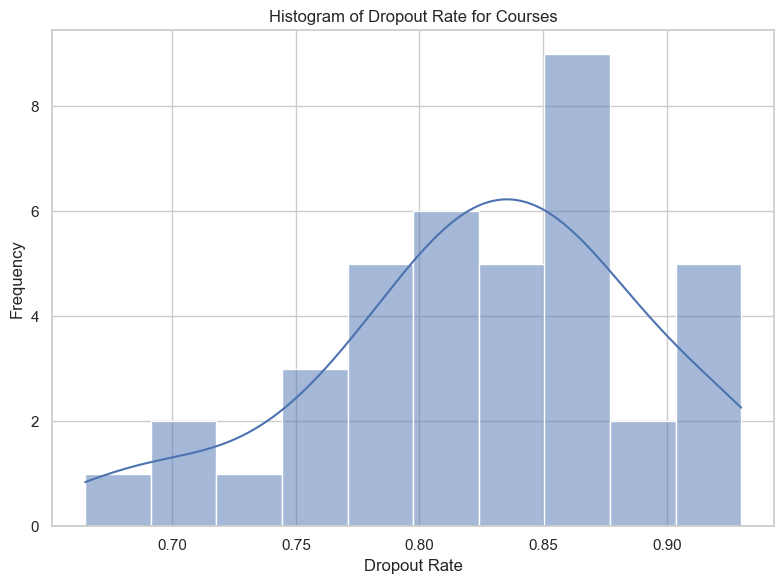

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Visualize the distribution of dropout rates for courses
plt.figure(figsize=(8, 6))

sns.histplot(
    data=df_dist_course_id,
    x='dropout_rate',
    bins=10,           
    kde=True           
)

plt.title('Histogram of Dropout Rate for Courses')
plt.xlabel('Dropout Rate')
plt.ylabel('Frequency')

finalize_plot("hist_dropout_rate_for_courses")


## object_count_vars

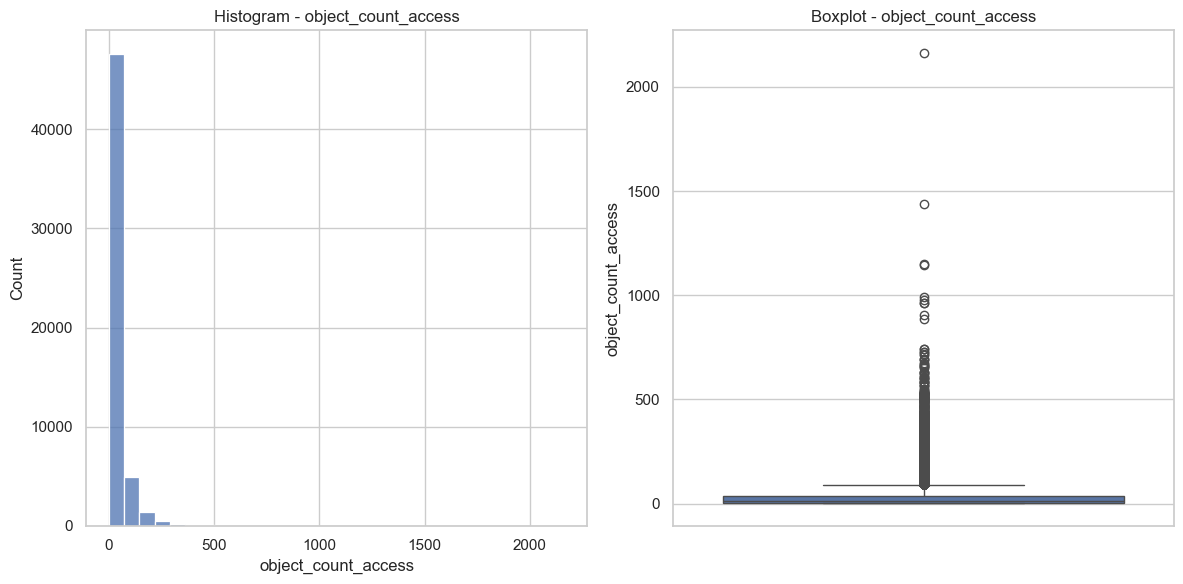

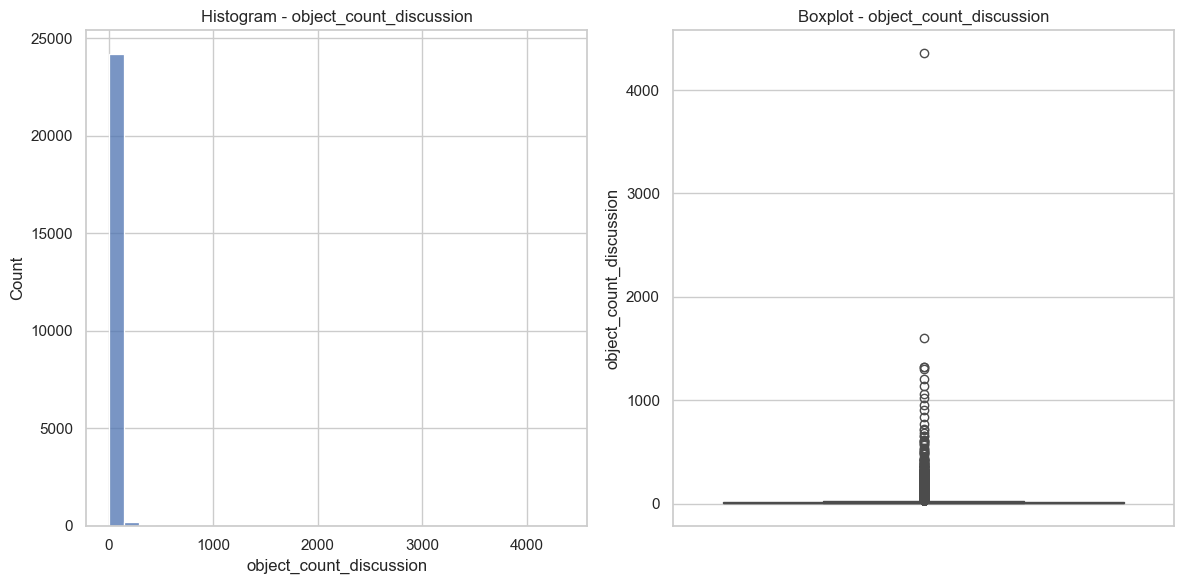

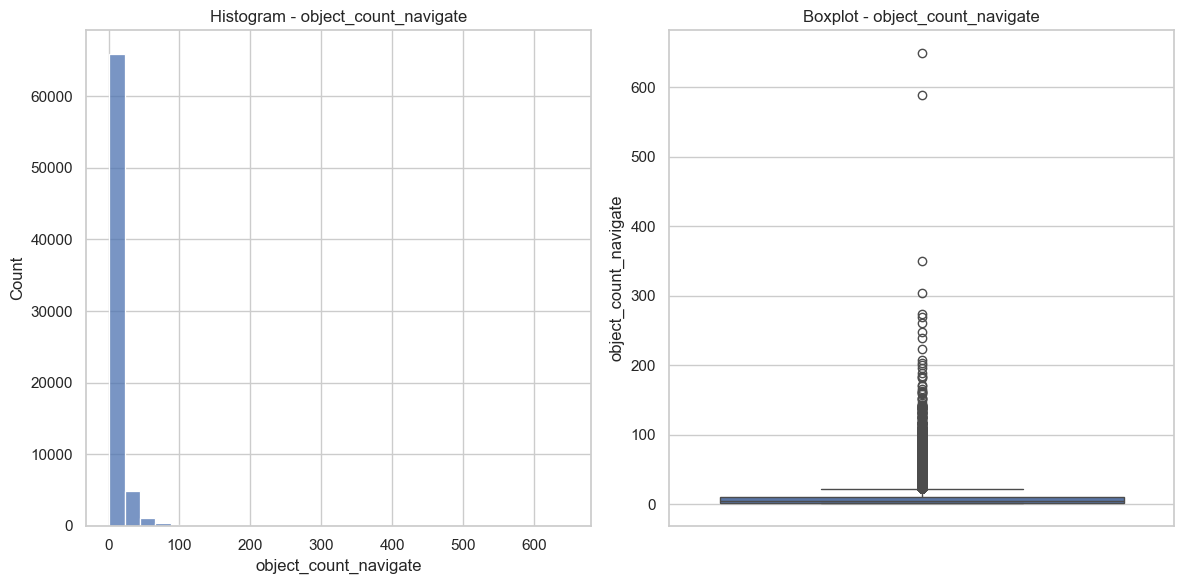

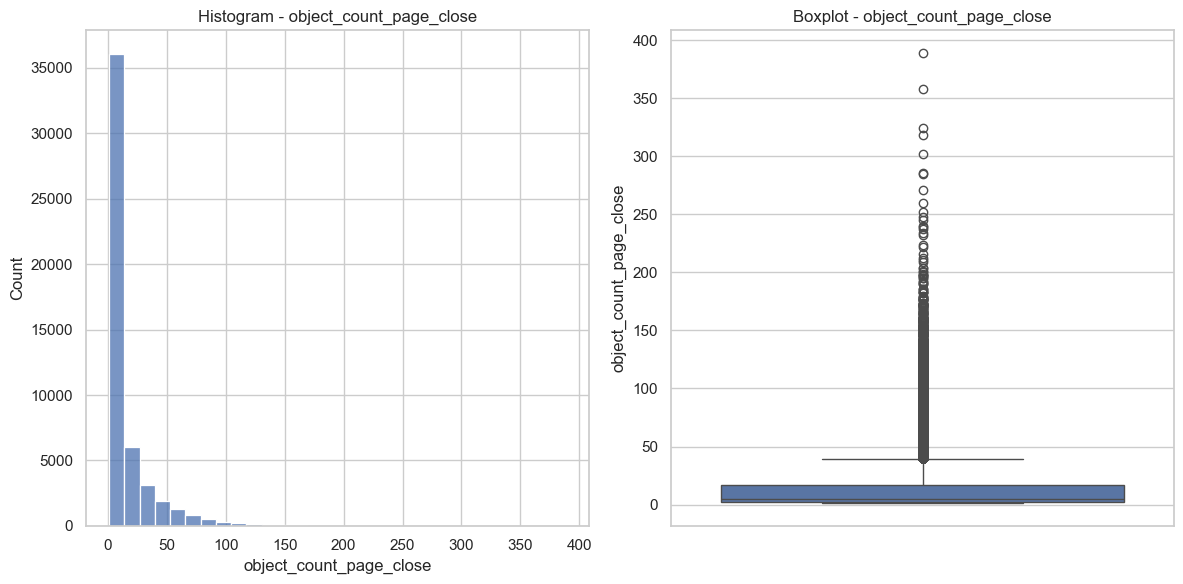

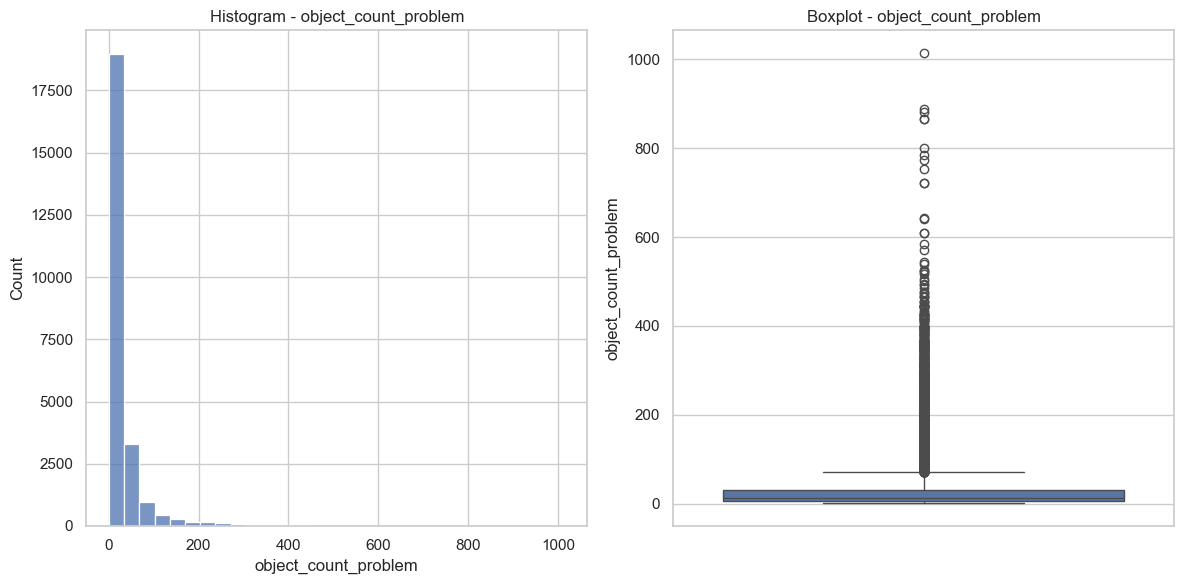

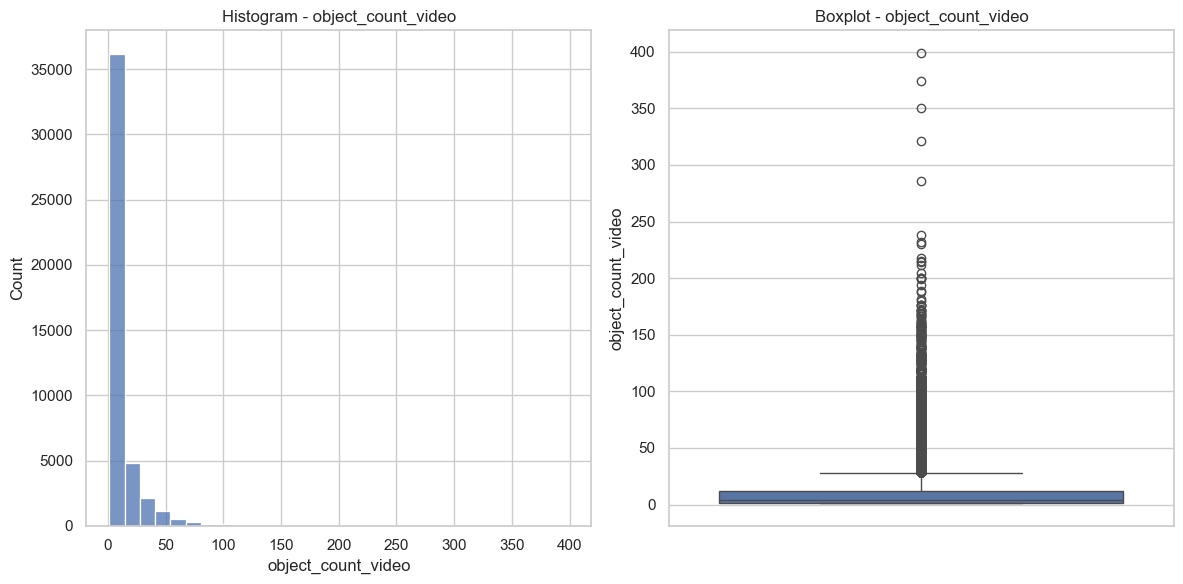

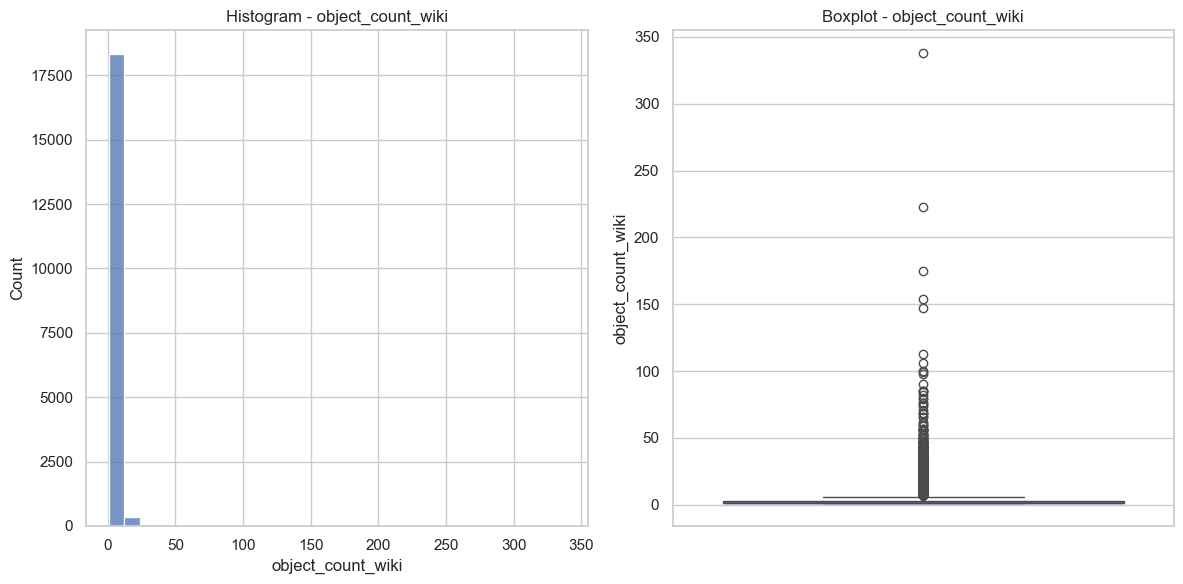

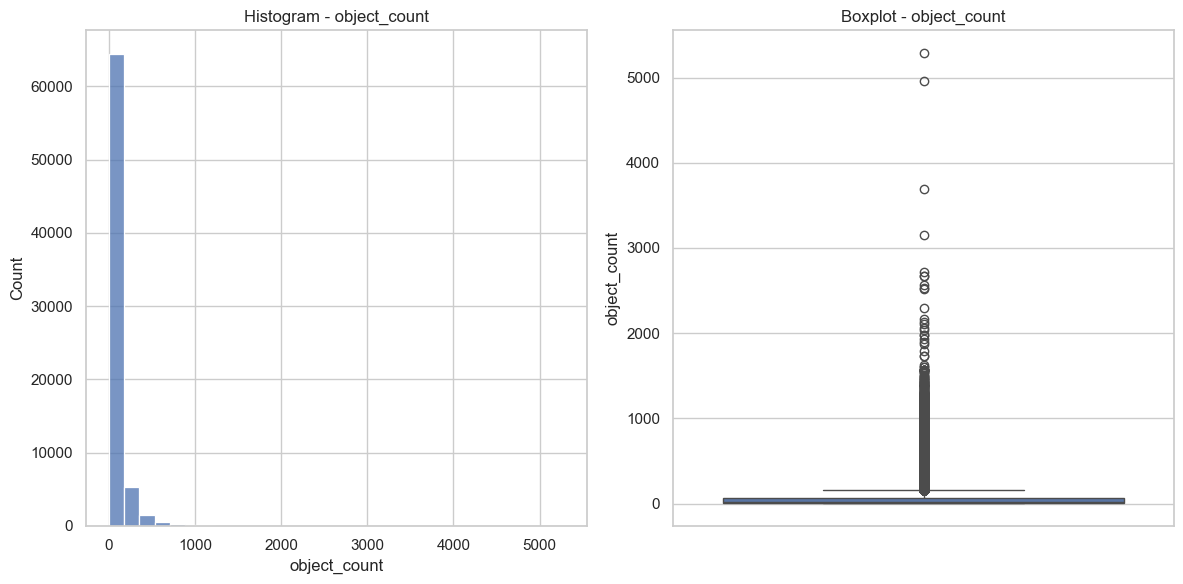

In [72]:

sns.set_style("whitegrid")

list_object_count_vars = df_combined.filter(regex="object_count").columns.tolist()

for var in list_object_count_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Histogram
    sns.histplot(df_combined[var].dropna(), ax=axes[0], kde=False, bins=30)
    axes[0].set_title(f"Histogram - {var}")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(y=df_combined[var], ax=axes[1])
    axes[1].set_title(f"Boxplot - {var}")
    axes[1].set_ylabel(var)


    finalize_plot(f"object_count_{var}_hist_box")


The distribution of each variable is right-skewed.

In [74]:
# Aggregate object counts by dropout flag
df_dist_dropout_flg_object_count = df_combined_train.filter(regex='object_count|dropout_flg').groupby('dropout_flg').sum().reset_index()

# Aggregate enrollment counts by dropout flag
df_dist_dropout_flg = df_combined_train.groupby('dropout_flg').agg({'enrollment_id': 'count'}).reset_index()

# Merge the aggregated dataframes
df_dist_dropout_flg_agg = df_dist_dropout_flg.merge(df_dist_dropout_flg_object_count, on='dropout_flg', how='inner')

# Display the aggregated dataframe
print("Aggregated Dataframe by Dropout Flag:")
display(df_dist_dropout_flg_agg)

# Calculate the mean object counts per enrollment 平均每个 enrollment 的 object_count
for column in list_object_count_vars:
    df_dist_dropout_flg_agg[column] = round(df_dist_dropout_flg_agg[column] / df_dist_dropout_flg_agg['enrollment_id'], 4)

# Display the final aggregated dataframe with mean object counts
print("\nFinal Aggregated Dataframe with Mean Object Counts per Enrollment:")
display(df_dist_dropout_flg_agg)


Aggregated Dataframe by Dropout Flag:


,dropout_flg,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_count
0,0,14823,1111946.0,255804.0,295768.0,444809.0,480732.0,277200.0,27526.0,2893785
1,1,56571,724020.0,118255.0,301466.0,287053.0,262912.0,194730.0,25187.0,1913623



Final Aggregated Dataframe with Mean Object Counts per Enrollment:


,dropout_flg,enrollment_id,object_count_access,object_count_discussion,object_count_navigate,object_count_page_close,object_count_problem,object_count_video,object_count_wiki,object_count
0,0,14823,75.0149,17.2572,19.9533,30.0080,32.4315,18.7007,1.8570,195.2226
1,1,56571,12.7984,2.0904,5.3290,5.0742,4.6475,3.4422,0.4452,33.8269


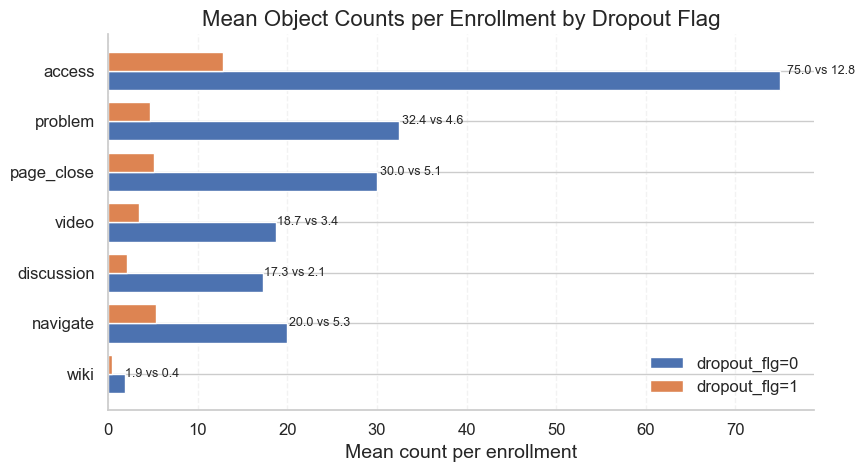

In [75]:
df_agg = df_dist_dropout_flg_agg.copy()
feat_cols = [c for c in df_agg.columns if c.startswith("object_count_")]
row0 = df_agg.loc[df_agg["dropout_flg"] == 0, feat_cols].iloc[0]
row1 = df_agg.loc[df_agg["dropout_flg"] == 1, feat_cols].iloc[0]
plot_df = pd.DataFrame({
    "feature": [c.replace("object_count_", "") for c in feat_cols],
    "dropout_0": row0.values,
    "dropout_1": row1.values
})
plot_df["diff"] = plot_df["dropout_0"] - plot_df["dropout_1"]
plot_df = plot_df.sort_values("diff", ascending=True) 

# Set global font parameters
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 16,         
    "axes.titlesize": 16,     
    "axes.labelsize": 14,     
    "xtick.labelsize": 12,  
    "ytick.labelsize": 12,   
    "legend.fontsize": 12,    
})

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(plot_df))
h = 0.38
ax.barh(y - h/2, plot_df["dropout_0"], height=h, label="dropout_flg=0")
ax.barh(y + h/2, plot_df["dropout_1"], height=h, label="dropout_flg=1")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Mean count per enrollment")
ax.set_title("Mean Object Counts per Enrollment by Dropout Flag")
for i, (v0, v1) in enumerate(zip(plot_df["dropout_0"], plot_df["dropout_1"])):
    vmax = max(v0, v1)
    ax.text(vmax * 1.01, i, f"{v0:.1f} vs {v1:.1f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
plt.subplots_adjust(left=0.4, right=0.98)

finalize_plot("mean_object_counts_by_dropout")


- Insights
    - Activity Levels: 
        - Users who do not drop out of courses (dropout_flg = 0) show much higher activity levels across all types of objects compared to users who drop out (dropout_flg = 1).
</br>
</br>
    - Engagement with Different Objects: 
        - Non-dropout users engage more frequently with all types of objects, especially access events, problem-solving objects, and page closings.
        - The engagement level for video and wiki objects is also significantly higher among non-dropout users.
</br>
</br>
    - Dropout Behavior:
        - The lower mean object counts for dropout users suggest they are less engaged with the course material, which might be a significant factor contributing to their dropout.
</br>
</br>
- Recommendations
    - Increase Engagement:
        - Identify ways to increase user engagement with all types of objects, especially those that have the highest discrepancy between dropout and non-dropout users, such as access events and problem-solving objects.
</br>
</br>
    - Early Intervention:
        - Develop early intervention strategies to support users who show signs of low engagement to prevent dropouts.
</br>
</br>
    - Personalized Support:
        - Provide personalized support and resources to users who exhibit lower engagement levels, helping them stay on track with their courses.

## object_nunique_var

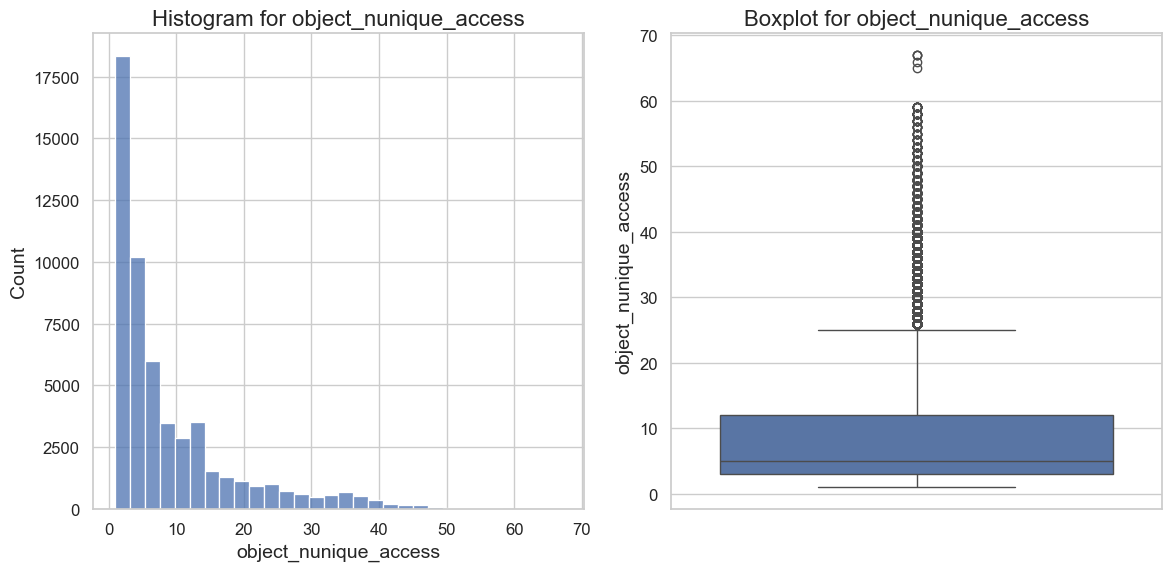

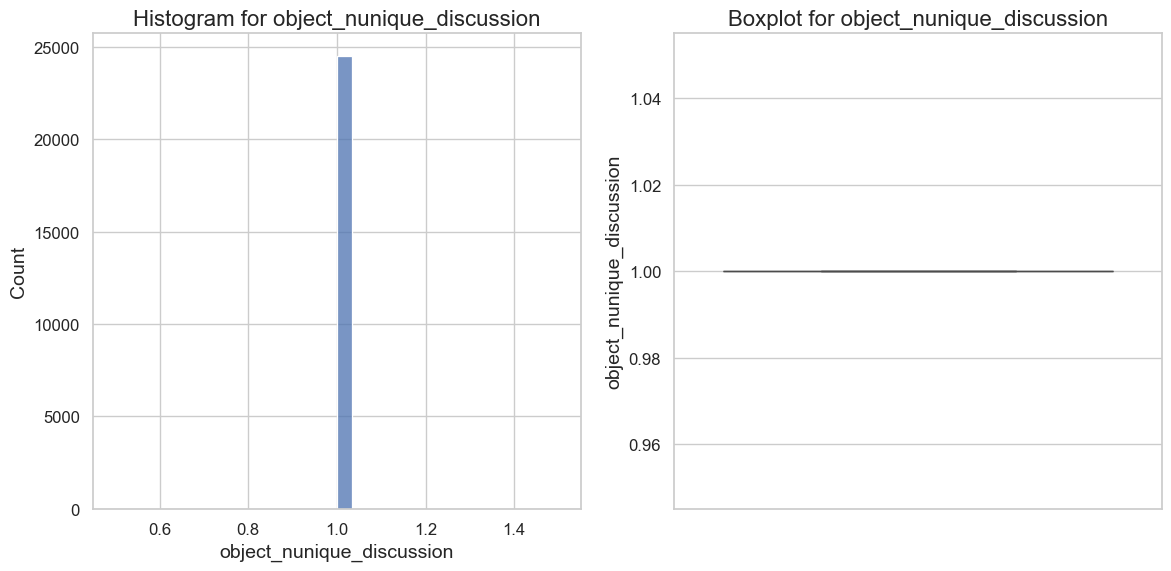

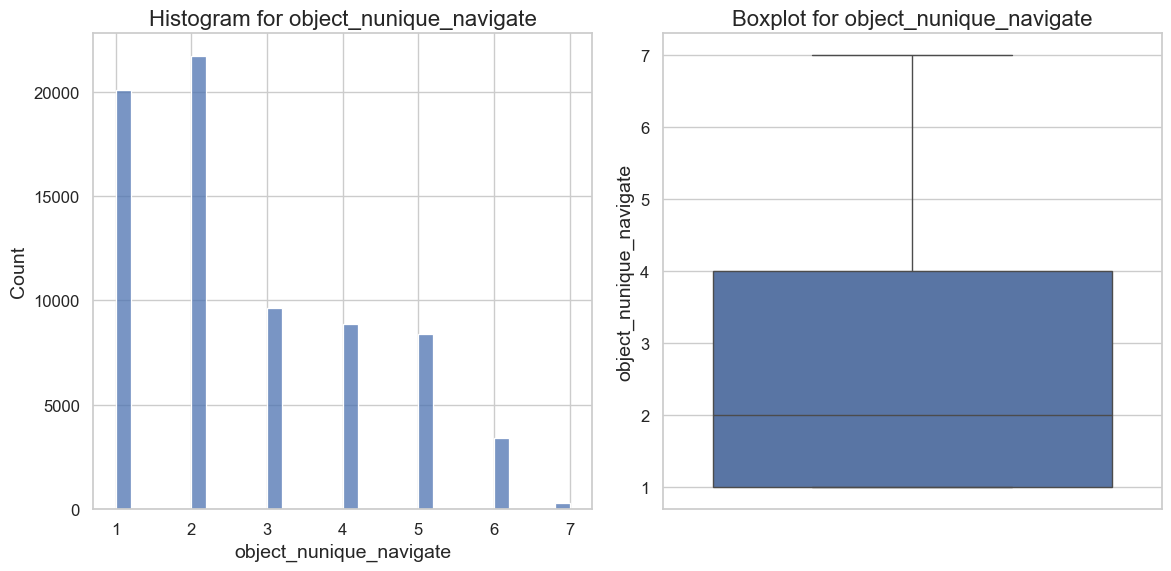

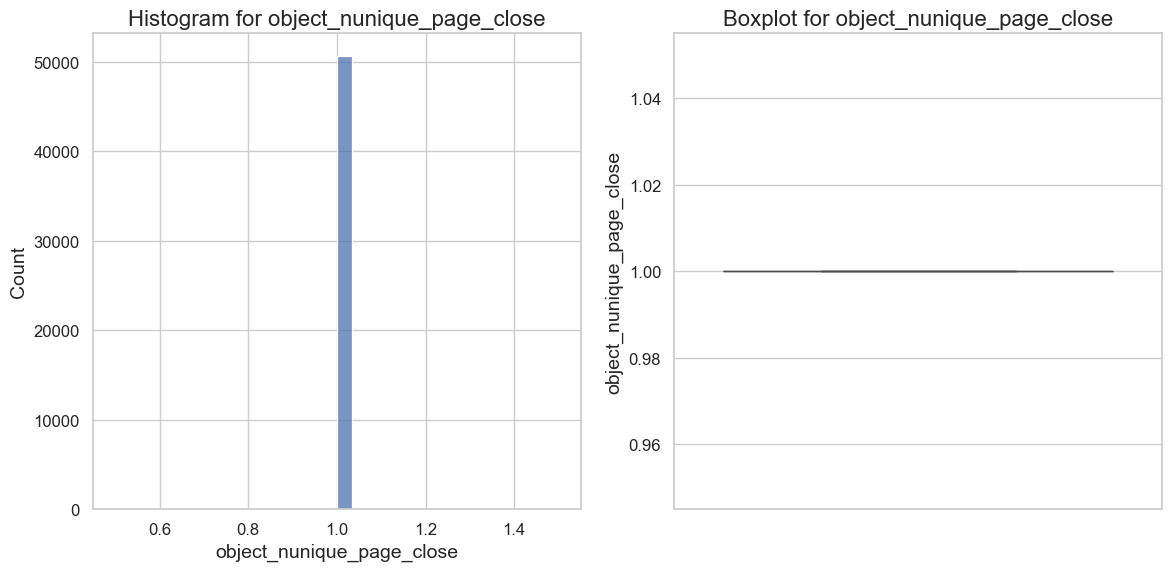

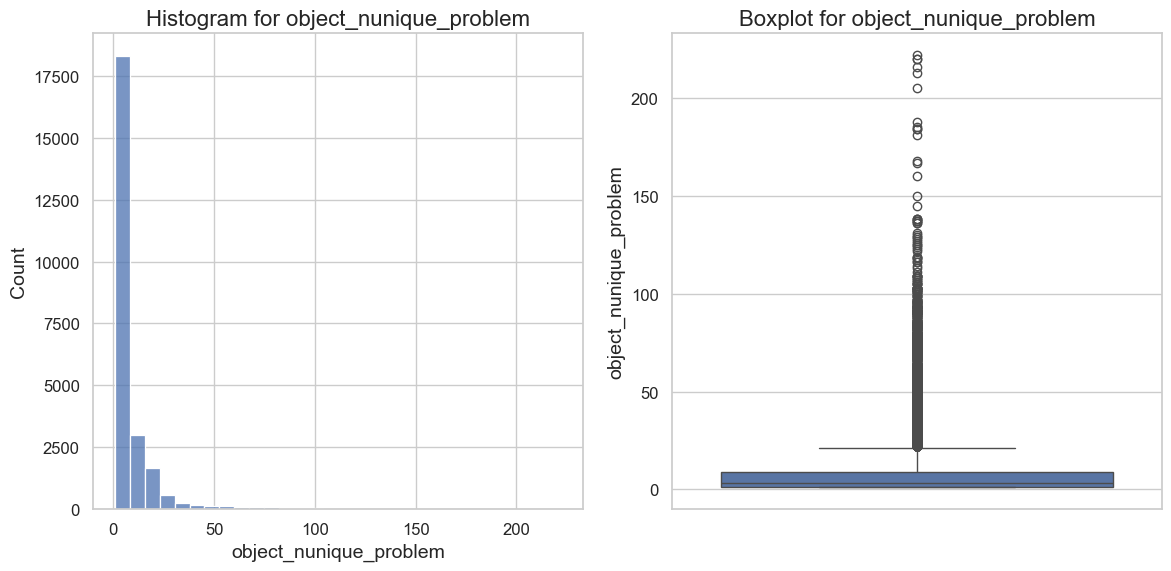

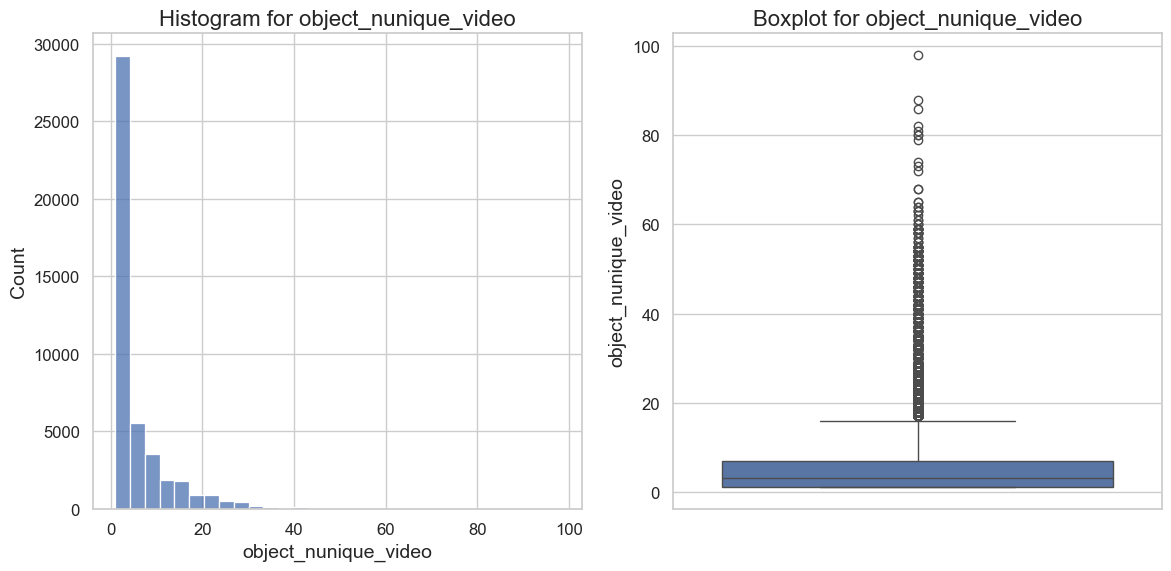

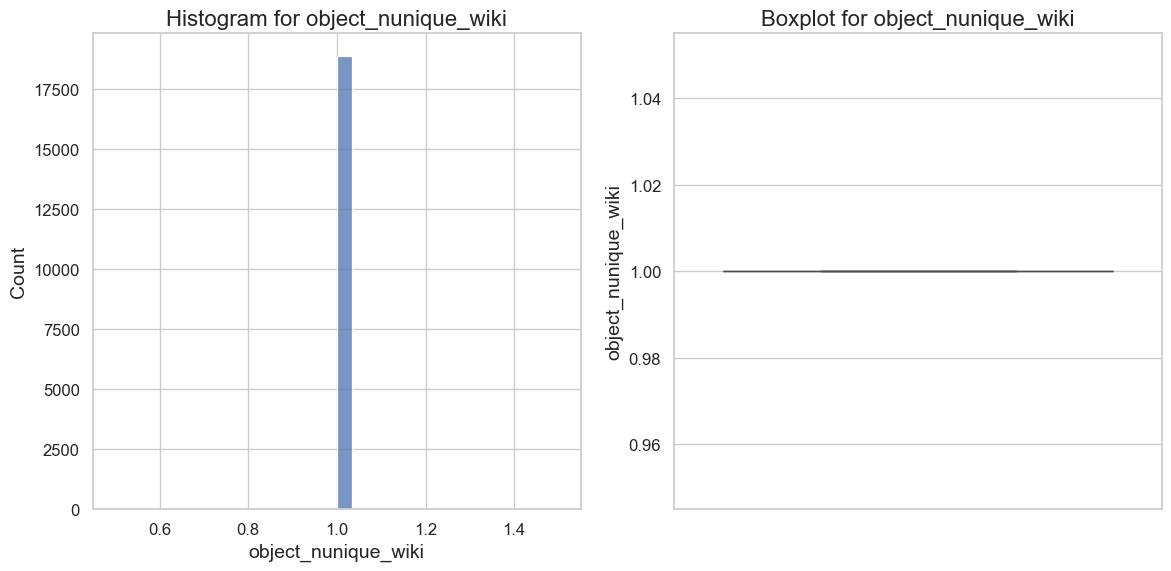

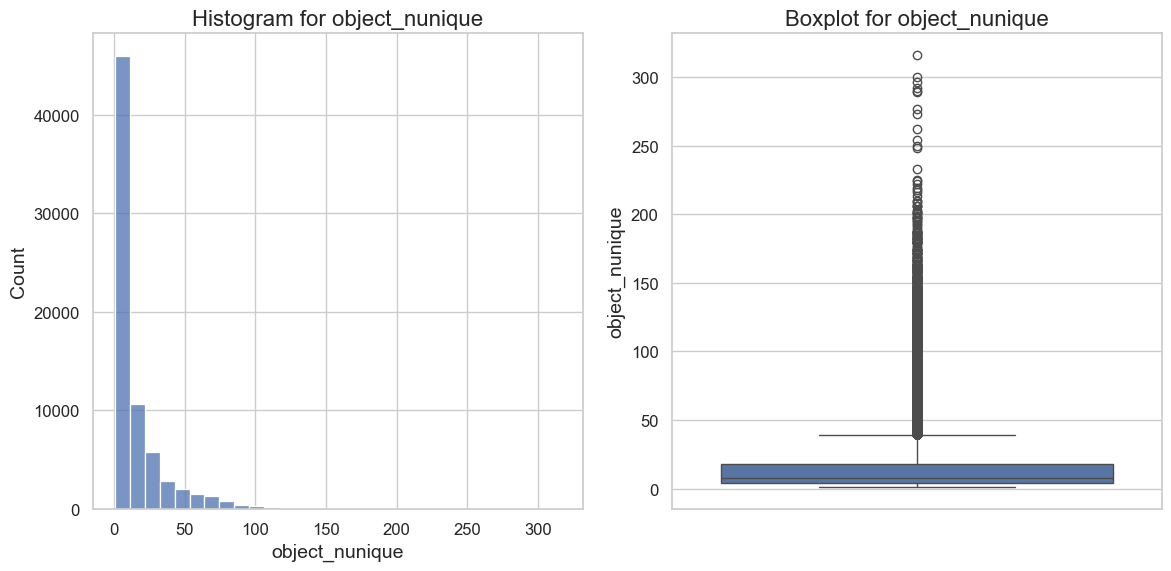

In [78]:
# Check the number of times each unique object occurred
list_object_count_vars = df_combined.filter(regex='object_nunique').columns.tolist()
for var in list_object_count_vars:
    # Set the style for the plots (optional)
    sns.set_style("whitegrid")
    # Create a figure with subplots for histogram and boxplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Creating a 1x2 grid of subplots
    # Plotting histogram using Seaborn
    sns.histplot(df_combined[var], ax=axes[0], kde=False, bins=30)
    axes[0].set_title('Histogram for ' + var)
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Count')
    # Plotting boxplot using Seaborn
    sns.boxplot(y=df_combined[var], ax=axes[1])
    axes[1].set_title('Boxplot for ' + var)
    axes[1].set_ylabel(var)

    fig_name = var.replace('/', '_').replace('\\', '_').replace(' ', '_')
    finalize_plot(f"hist_box_{fig_name}")

Some object_nunique variables are right-skewed, and some only have a few associated values.

In [80]:
# Aggregate unique object counts by dropout flag
df_dist_dropout_flg_object_nunique = df_combined_train.filter(regex='object_nunique|dropout_flg').groupby('dropout_flg').sum().reset_index()

# Aggregate enrollment counts by dropout flag
df_dist_dropout_flg = df_combined_train.groupby('dropout_flg').agg({'enrollment_id': 'count'}).reset_index()

# Merge the aggregated dataframes
df_dist_dropout_flg_agg = df_dist_dropout_flg.merge(df_dist_dropout_flg_object_nunique, on='dropout_flg', how='inner')

# Display the aggregated dataframe by dropout flag
print("Aggregated Dataframe by Dropout Flag:")
display(df_dist_dropout_flg_agg)

# Calculate the mean unique object counts per enrollment
for column in list_object_count_vars:
    df_dist_dropout_flg_agg[column] = round(df_dist_dropout_flg_agg[column] / df_dist_dropout_flg_agg['enrollment_id'], 4)

# Display the final aggregated dataframe with mean unique object counts per enrollment
print("\nFinal Aggregated Dataframe with Mean Unique Object Counts per Enrollment:")
display(df_dist_dropout_flg_agg)


Aggregated Dataframe by Dropout Flag:


,dropout_flg,enrollment_id,object_nunique_access,object_nunique_discussion,object_nunique_navigate,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,object_nunique
0,0,14823,254453.0,9316.0,53631.0,13610.0,127627.0,142639.0,7092.0,574266
1,1,56571,243898.0,14832.0,135826.0,36347.0,67488.0,118757.0,11527.0,562147



Final Aggregated Dataframe with Mean Unique Object Counts per Enrollment:


,dropout_flg,enrollment_id,object_nunique_access,object_nunique_discussion,object_nunique_navigate,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,object_nunique
0,0,14823,17.1661,0.6285,3.6181,0.9182,8.6101,9.6228,0.4784,38.7416
1,1,56571,4.3114,0.2622,2.4010,0.6425,1.1930,2.0993,0.2038,9.9370


Found 8 metrics to visualize:
['object_nunique_access', 'object_nunique_discussion', 'object_nunique_navigate', 'object_nunique_page_close', 'object_nunique_problem', 'object_nunique_video', 'object_nunique_wiki', 'object_nunique']


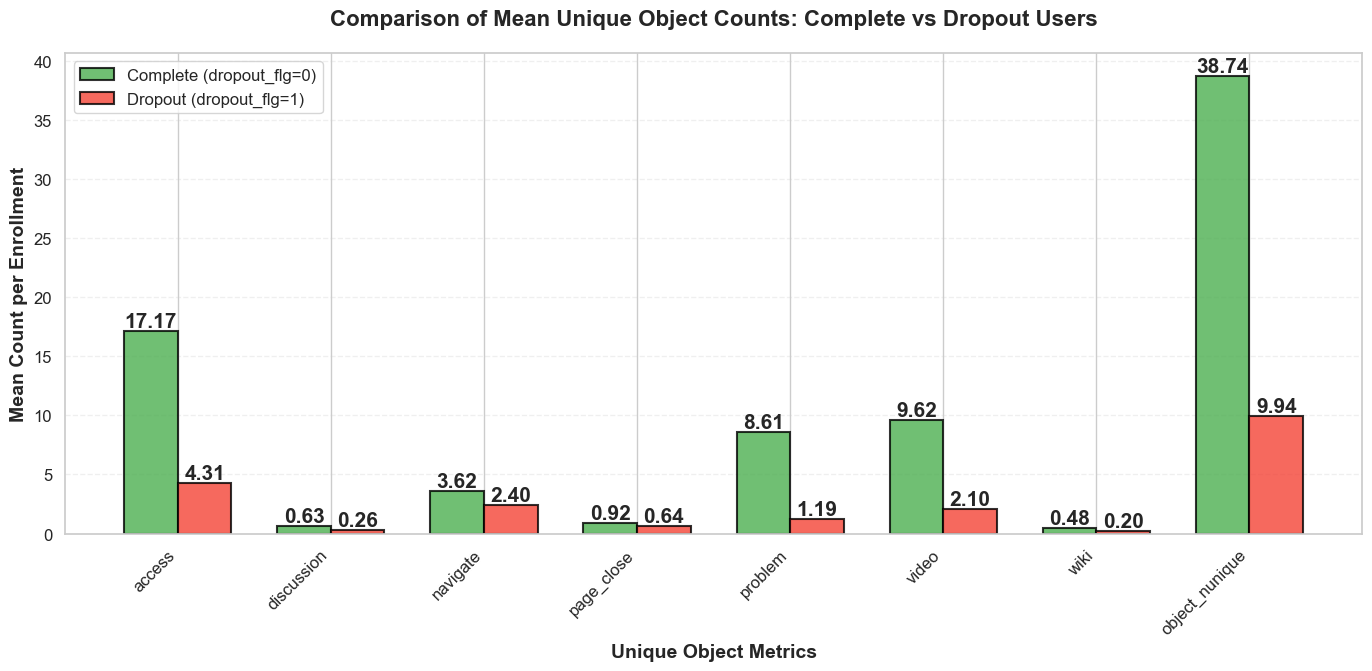

In [81]:
nunique_cols = [col for col in df_dist_dropout_flg_agg.columns
                if col.startswith('object_nunique')]
print(f"Found {len(nunique_cols)} metrics to visualize:")
print(nunique_cols)

dropout_0_data = df_dist_dropout_flg_agg[df_dist_dropout_flg_agg['dropout_flg'] == 0][nunique_cols].values[0]
dropout_1_data = df_dist_dropout_flg_agg[df_dist_dropout_flg_agg['dropout_flg'] == 1][nunique_cols].values[0]


fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(nunique_cols))
width = 0.35

bars1 = ax.bar(x - width/2, dropout_0_data, width,
               label='Complete (dropout_flg=0)',
               color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, dropout_1_data, width,
               label='Dropout (dropout_flg=1)',
               color='#F44336', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Unique Object Metrics', fontweight='bold')
ax.set_ylabel('Mean Count per Enrollment', fontweight='bold')
ax.set_title('Comparison of Mean Unique Object Counts: Complete vs Dropout Users',
             fontweight='bold', pad=20)
# Remove the prefix "object_nunique_"
labels = [c.replace("object_nunique_", "") for c in nunique_cols]

# Optional: rename the overall count feature to a more interpretable label
labels = ["overall_unique" if lab == "object_unique" else lab for lab in labels]

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=15,
            fontweight='bold'
        )

plt.subplots_adjust(left=0.4, right=0.98)

finalize_plot("object_nunique_grouped_bar")


- Insights:
    - Activity Levels:
        - Non-dropout users (dropout_flg = 0):
            - Engage significantly more with various objects compared to dropout users.
            - Have higher mean counts of unique access events (17.1661), unique problem objects (8.6101), and unique video objects (9.6228).

        - Dropout users (dropout_flg = 1):
            - Exhibit lower engagement levels, reflected in lower mean counts of unique access events (4.3114), unique problem objects (1.1930), and unique video objects (2.0993).
</br>
</br>
    - Engagement with Different Objects:
        - Non-dropout users:
            - Show higher engagement across all object types, especially access events, problem-solving objects, and videos.
            - Unique navigation events and page closes also show higher engagement levels among non-dropout users.

        - Dropout users:
            - Lower engagement levels across all object types, suggesting a correlation between engagement and course completion.
</br>
</br>
    - Dropout Behavior:
        - The lower mean unique object counts for dropout users suggest that they are less engaged with the course material.
        - Engagement with problem-solving objects and videos appears to be a significant factor, as the discrepancy between dropout and non-dropout users is notable in these categories.
</br>
</br>
- Recommendations:
    - Increase Engagement:
        - Identify and implement strategies to boost user engagement with key objects, especially those with the highest discrepancy between dropout and non-dropout users, such as access events, problem-solving objects, and videos.
        - Enhance course content and interactivity to maintain user interest and engagement.
</br>
</br>
    - Early Intervention:
        - Develop and deploy early intervention strategies to support users who show signs of low engagement.
        - Utilize predictive models to identify at-risk users early in the course and provide targeted support to prevent dropouts.
</br>
</br>
    - Personalized Support:
        - Offer personalized support and resources to users exhibiting lower engagement levels.
        - Implement personalized learning paths and additional resources to help users stay on track and complete their courses.


## event_nunique

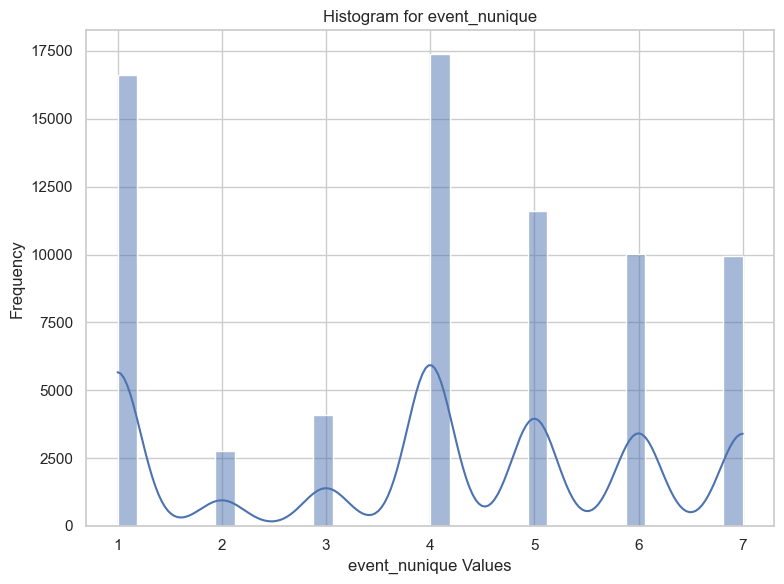

In [84]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))

# Plot the histogram for 'event_nunique' with KDE
sns.histplot(data=df_combined['event_nunique'], kde=True)

plt.title('Histogram for event_nunique')
plt.xlabel('event_nunique Values')
plt.ylabel('Frequency')

finalize_plot("event_nunique_histogram")

In [85]:
# Aggregate the mean unique event counts by dropout flag
df_dist_dropout_flg_event_nunique = df_combined_train.filter(regex='event_nunique|dropout_flg').groupby('dropout_flg').mean().reset_index()

# Display the aggregated dataframe
print("Aggregated Dataframe of Mean Unique Event Counts by Dropout Flag:")
display(df_dist_dropout_flg_event_nunique)


Aggregated Dataframe of Mean Unique Event Counts by Dropout Flag:


,dropout_flg,event_nunique
0,0,5.568576
1,1,3.624560


The average number of unique events is lower for the dropout group compared to the group that did not drop out.

## source_nunique

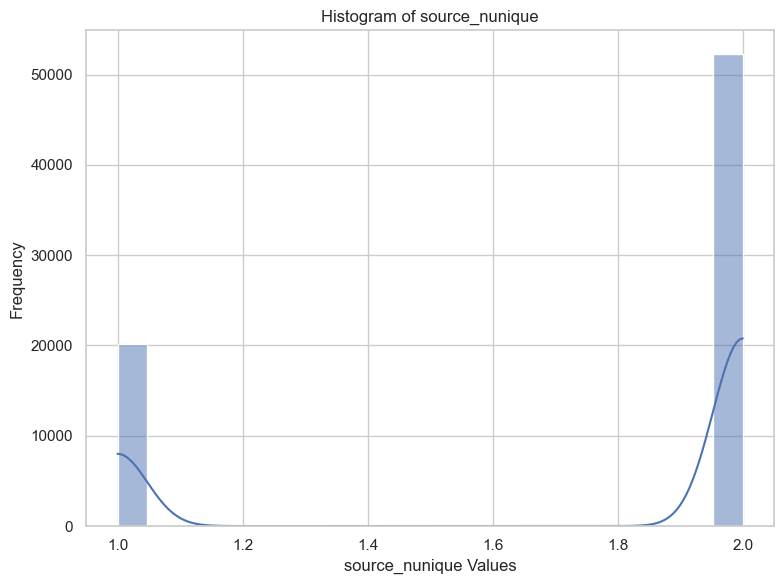

In [88]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))
sns.histplot(data=df_combined['source_nunique'], kde=True)
plt.title('Histogram of source_nunique')
plt.xlabel('source_nunique Values')
plt.ylabel('Frequency')

finalize_plot("source_nunique_histogram")


In [89]:
# Aggregate the mean unique source counts by dropout flag
df_dist_dropout_flg_source_nunique = df_combined_train.filter(regex='source_nunique|dropout_flg').groupby('dropout_flg').mean().reset_index()

# Display the aggregated dataframe
print("Aggregated Dataframe of Mean Unique Source Counts by Dropout Flag:")
display(df_dist_dropout_flg_source_nunique)


Aggregated Dataframe of Mean Unique Source Counts by Dropout Flag:


,dropout_flg,source_nunique
0,0,1.935033
1,1,1.666101


The average number of unique sources is slightly lower for the group of enrollments that eventually drop out compared to the group of enrollments that do not drop out.

## gender

In [92]:
# Check the unique values in the 'gender' column
display(df_combined.gender.unique())


array(['male', 'female', nan, 'other', 'missing'], dtype=object)

In [93]:
# Check the dropout flag distribution by gender
df_dist_gender = df_combined_train.groupby('gender').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each gender
df_dist_gender['dropout_rate'] = round(df_dist_gender['dropout_flg'] / df_dist_gender['enrollment_id'], 4)

# Display the dropout distribution by gender, sorted by dropout rate and enrollment count
print("Dropout Distribution by Gender:")
display(df_dist_gender.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False).head())


Dropout Distribution by Gender:


,gender,dropout_flg,enrollment_id,dropout_rate
1,male,13533,16962,0.7978
3,other,3485,4377,0.7962
2,missing,10256,12921,0.7937
0,female,14768,18626,0.7929
4,unknown,14529,18508,0.7850


The dropout rate is very similar across different gender types.

## zip

In [96]:
# Check the number of unique zips
display(df_combined.zip.nunique())


15907

In [97]:
# Check the dropout flag distribution by zip code
df_dist_zip = df_combined_train.groupby('zip').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each zip code
df_dist_zip['dropout_rate'] = round(df_dist_zip['dropout_flg'] / df_dist_zip['enrollment_id'], 4)

# Display the dropout distribution by zip code, sorted by dropout rate and enrollment count
print("Dropout Distribution by Zip Code:")
display(df_dist_zip.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))


Dropout Distribution by Zip Code:


,zip,dropout_flg,enrollment_id,dropout_rate
14919,95008,21,21,1.0
15099,95624,21,21,1.0
14107,90805,20,20,1.0
5512,33196,19,19,1.0
3394,22003,17,17,1.0
...,...,...,...,...
15792,99349,0,1,0.0
15804,99506,0,1,0.0
15807,99514,0,1,0.0
15822,99629,0,1,0.0


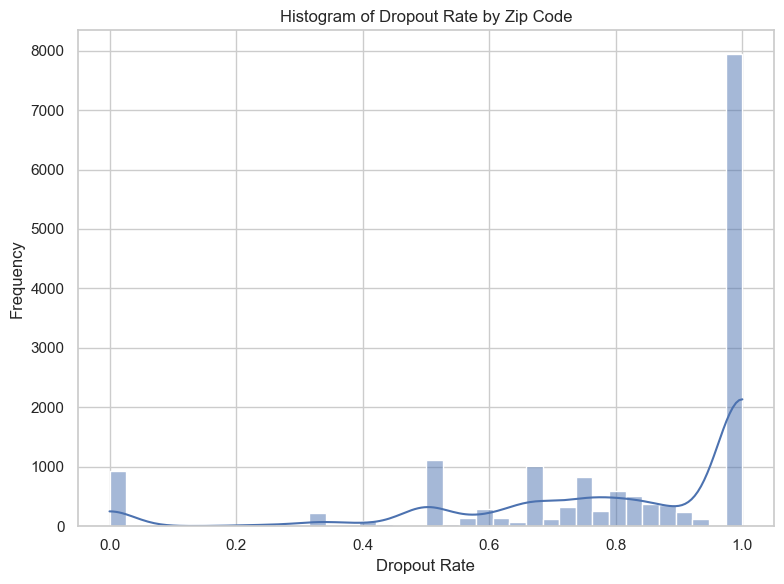

In [98]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))
sns.histplot(data=df_dist_zip['dropout_rate'], kde=True)
plt.title('Histogram of Dropout Rate by Zip Code')
plt.xlabel('Dropout Rate')
plt.ylabel('Frequency')
plt.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.9)

finalize_plot("hist_dropout_rate_by_zip")

## highest_education

In [100]:
# Check the unique values in the 'highest_education' column
df_combined.highest_education.unique()


array(['some college', 'highschool', 'missing', 'graduate', 'college',
       'no highschool'], dtype=object)

In [101]:
# Check the dropout flag distribution by highest education level
df_dist_highest_education = df_combined_train.groupby('highest_education').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each education level
df_dist_highest_education['dropout_rate'] = round(df_dist_highest_education['dropout_flg'] / df_dist_highest_education['enrollment_id'], 4)

# Display the dropout distribution by highest education level, sorted by dropout rate and enrollment count
print("Dropout Distribution by Highest Education Level:")
display(df_dist_highest_education.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False).head())


Dropout Distribution by Highest Education Level:


,highest_education,dropout_flg,enrollment_id,dropout_rate
3,missing,6168,6980,0.8837
4,no highschool,6739,8347,0.8074
2,highschool,16203,20098,0.8062
5,some college,14428,18627,0.7746
1,graduate,4521,6006,0.7527


In [102]:
import matplotlib.ticker as mtick

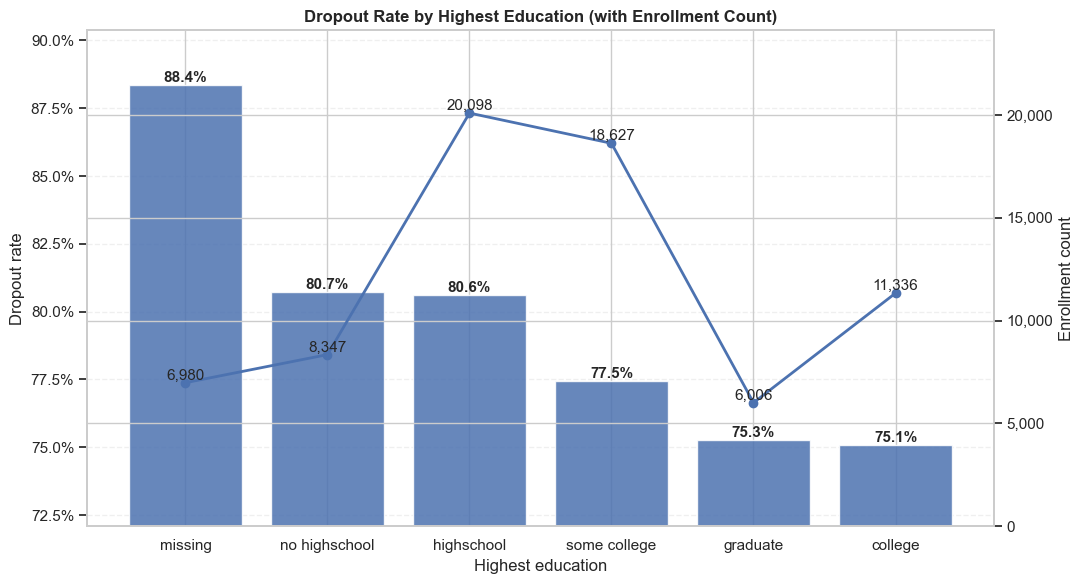

In [103]:
df_plot = df_dist_highest_education.copy()
df_plot = df_plot.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False).reset_index(drop=True)

x = df_plot['highest_education'].astype(str)
rate = df_plot['dropout_rate'].astype(float)
cnt = df_plot['enrollment_id'].astype(float)

fig, ax1 = plt.subplots(figsize=(11, 6))

bars = ax1.bar(x, rate, alpha=0.85)
ax1.set_ylabel("Dropout rate")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

y_min = max(0, rate.min() - 0.03)
y_max = min(1.0, rate.max() + 0.02)
ax1.set_ylim(y_min, y_max)

for b, r in zip(bars, rate):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{r:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(x, cnt, marker='o', linewidth=2)
ax2.set_ylabel("Enrollment count")
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax2.set_ylim(0, cnt.max() * 1.20)

for xi, c in zip(x, cnt):
    ax2.text(xi, c, f"{int(c):,}", ha="center", va="bottom", fontsize=11)

ax1.set_title("Dropout Rate by Highest Education (with Enrollment Count)", fontweight="bold")
ax1.set_xlabel("Highest education")
plt.xticks(rotation=25, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.subplots_adjust(left=0.3, right=0.98)

finalize_plot("dropout_rate_by_education_dual_axis")

#### - High Dropout Rates Among Users with Missing Education Data:
    - Users with missing education data (highest_education = missing) have the highest dropout rate of 88.4%. This suggests that users who haven't provided their education level are significantly more likely to drop out.
</br>
</br>
- Dropout Rates by Education Level:
    - Higher educational attainment is associated with lower dropout rates.
</br>
</br>
- Trend in Dropout Rates:
    - There is a general trend that users with higher education levels have lower dropout rates. This suggests that education level is a significant factor in predicting course completion.
</br>
</br>
- Potential Focus Areas:
    - Interventions could be tailored to support users with lower education levels or those who did not disclose their education information, as these groups are at a higher risk of dropping out.

## ZipCodeType

In [106]:
# Check the unique values in the 'ZipCodeType' column
df_combined.ZipCodeType.unique()


array(['STANDARD', 'PO BOX', 'UNIQUE'], dtype=object)

In [107]:
# Check the dropout flag distribution by ZipCodeType
df_dist_ZipCodeType = df_combined_train.groupby('ZipCodeType').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each ZipCodeType
df_dist_ZipCodeType['dropout_rate'] = round(df_dist_ZipCodeType['dropout_flg'] / df_dist_ZipCodeType['enrollment_id'], 4)

# Display the dropout distribution by ZipCodeType, sorted by dropout rate and enrollment count
print("Dropout Distribution by ZipCodeType:")
display(df_dist_ZipCodeType.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False).head())


Dropout Distribution by ZipCodeType:


,ZipCodeType,dropout_flg,enrollment_id,dropout_rate
1,STANDARD,55657,70224,0.7926
0,PO BOX,904,1157,0.7813
2,UNIQUE,10,13,0.7692


- High Dropout Rates for All ZipCodeTypes:
    - The dropout rates are high across all ZipCodeTypes, with the highest dropout rate observed for the STANDARD type (79.26%), followed by PO BOX (78.13%), and UNIQUE (76.92%).
</br>
</br>
- Prevalence of Standard Zip Codes:
    - The majority of enrollments are associated with STANDARD zip codes, making up a significant portion of the dataset with 70,224 enrollments. This suggests that standard residential or business addresses are the most common among the users.
</br>
</br>
- Dropout Rate Comparison:
    - While STANDARD zip codes have the highest dropout rate, the difference between the dropout rates for different ZipCodeTypes is relatively small.
    - This indicates that the type of zip code might not be a strong determinant of dropout risk, although STANDARD zip codes slightly edge out in terms of higher dropout rates.

## City

In [110]:
# Check the unique values in the 'City' column
df_combined.City.nunique()

7898

In [111]:
# Check the dropout flag distribution by City
df_dist_City = df_combined_train.groupby('City').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each City
df_dist_City['dropout_rate'] = round(df_dist_City['dropout_flg'] / df_dist_City['enrollment_id'], 4)

# Display the dropout distribution by City, sorted by dropout rate and enrollment count
print("Dropout Distribution by City:")
display(df_dist_City.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))


Dropout Distribution by City:


,City,dropout_flg,enrollment_id,dropout_rate
4270,MASON,20,20,1.0
4446,MIAMI BEACH,19,19,1.0
775,BRIDGETON,18,18,1.0
3206,HOPEWELL,18,18,1.0
3208,HOPKINS,18,18,1.0
...,...,...,...,...
7763,WOOD LAKE,0,1,0.0
7764,WOOD RIDGE,0,1,0.0
7786,WOODSTOCK VALLEY,0,1,0.0
7805,WRIGHTWOOD,0,1,0.0


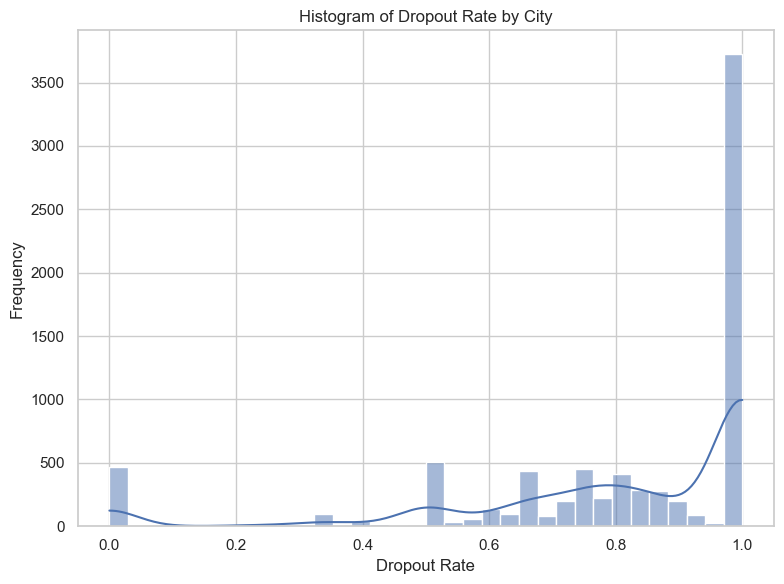

In [112]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))
sns.histplot(data=df_dist_City['dropout_rate'], kde=True)
plt.title('Histogram of Dropout Rate by City')
plt.xlabel('Dropout Rate')
plt.ylabel('Frequency')

finalize_plot("hist_dropout_rate_by_city")


## State

In [114]:
# Check the unique values in the 'State' column
df_combined.State.nunique()


51

In [115]:
# Check the dropout flag distribution by State
df_dist_State = df_combined_train.groupby('State').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each State
df_dist_State['dropout_rate'] = round(df_dist_State['dropout_flg'] / df_dist_State['enrollment_id'], 4)

# Display the dropout distribution by State, sorted by dropout rate and enrollment count
print("Dropout Distribution by State:")
display(df_dist_State.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))


Dropout Distribution by State:


,State,dropout_flg,enrollment_id,dropout_rate
50,WY,117,141,0.8298
25,MS,501,609,0.8227
26,MT,183,223,0.8206
41,SD,135,165,0.8182
29,NE,326,399,0.8170
21,ME,250,306,0.8170
13,ID,284,349,0.8138
40,SC,900,1113,0.8086
5,CO,989,1224,0.8080
16,KS,514,637,0.8069


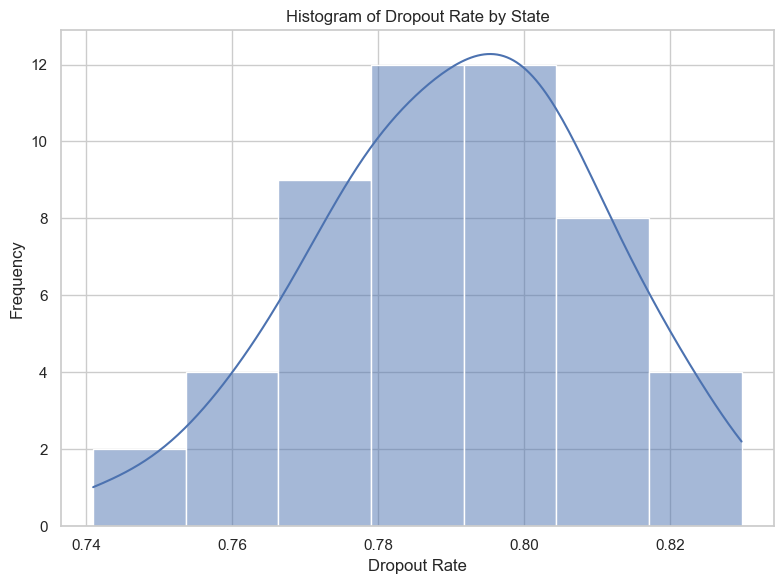

In [116]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))
sns.histplot(data=df_dist_State['dropout_rate'], kde=True)
plt.title('Histogram of Dropout Rate by State')
plt.xlabel('Dropout Rate')
plt.ylabel('Frequency')

finalize_plot("hist_dropout_rate_by_state")

## LocationType

In [118]:
# Check the unique values in the 'LocationType' column
df_combined.LocationType.nunique()


1

In [119]:
# Delete the 'LocationType' variable since it only has one unique value and therefore lacks predictive power
del df_combined['LocationType']
del df_combined_train['LocationType']
del df_combined_test['LocationType']


## Lat & Long 经纬度

In [121]:
# Check the number of unique Lat & Long
display(df_combined.Lat.nunique())
display(df_combined.Long.nunique())


2163

4130

In [122]:
df_dist_dropout_flg_Lat_Long = (
    df_combined_train
    .filter(regex='Lat|Long|dropout_flg')
    .groupby('dropout_flg')
    .agg({
        'Lat': ['mean', 'max', 'min'],
        'Long': ['mean', 'max', 'min']
    })
    .reset_index()
)

print("Aggregated Latitude and Longitude Statistics by Dropout Flag:")
display(df_dist_dropout_flg_Lat_Long)

lat_corr = df_combined_train['dropout_flg'].corr(df_combined_train['Lat'])
print("Correlation between dropout_flg and Lat:", lat_corr)

long_corr = df_combined_train['dropout_flg'].corr(df_combined_train['Long'])
print("Correlation between dropout_flg and Long:", long_corr)


Aggregated Latitude and Longitude Statistics by Dropout Flag:


dropout_flg        Lat                     Long              
                    mean    max    min       mean    max    min
0           0  37.681644  64.81  19.49 -91.811573 -67.81 -161.8
1           1  37.648660  70.63  19.07 -91.754204 -67.11 -166.4

Correlation between dropout_flg and Lat: -0.0025650290432120706
Correlation between dropout_flg and Long: 0.0014170147232859468


- Latitude and Dropout Rates:
    - The mean latitude for both dropout (dropout_flg = 1) and non-dropout (dropout_flg = 0) groups is very close, with values of 37.648660 and 37.681644, respectively.
    - The maximum and minimum latitudes are slightly higher and lower for the dropout group compared to the non-dropout group.
</br>
</br>
- Longitude and Dropout Rates:
    - The mean longitude for both dropout and non-dropout groups is also very similar, with values of -91.754204 and -91.811573, respectively.
    - The range of longitudes (maximum and minimum) is slightly broader for the dropout group, with a more extreme minimum longitude.
</br>
</br>
- Correlation Analysis:
    - The correlation between dropout_flg and latitude (Lat) is very weak and negative (-0.0026), indicating almost no relationship.
    - The correlation between dropout_flg and longitude (Long) is also very weak and positive (0.0014), suggesting no significant relationship.
</br>
</br>
- Geographical Influence:
    - The very weak correlations suggest that latitude and longitude have minimal to no direct influence on the likelihood of dropout.
    - Geographical location, as represented by latitude and longitude, does not appear to be a strong predictor of dropout rates in this dataset.

## Location

In [125]:
# Check the number of unique Location
df_combined.Location.nunique()


10970

In [126]:
# Check the dropout flag distribution by Location
df_dist_Location = df_combined_train.groupby('Location').agg({
    'dropout_flg': 'sum', 
    'enrollment_id': 'count'
}).reset_index()

# Calculate the dropout rate for each Location
df_dist_Location['dropout_rate'] = round(df_dist_Location['dropout_flg'] / df_dist_Location['enrollment_id'], 4)

# Display the dropout distribution by Location, sorted by dropout rate and enrollment count
print("Dropout Distribution by Location:")
display(df_dist_Location.sort_values(by=['dropout_rate', 'enrollment_id'], ascending=False))


Dropout Distribution by Location:


,Location,dropout_flg,enrollment_id,dropout_rate
609,NA-US-CA-CAMPBELL,21,21,1.0
1662,NA-US-FL-MIAMI BEACH,19,19,1.0
1028,NA-US-CA-SAN CLEMENTE,18,18,1.0
9906,NA-US-VA-ANNANDALE,17,17,1.0
1413,NA-US-CT-SHELTON,16,16,1.0
...,...,...,...,...
10787,NA-US-WV-DELBARTON,0,1,0.0
10810,NA-US-WV-HARTS,0,1,0.0
10815,NA-US-WV-HUTTONSVILLE,0,1,0.0
10842,NA-US-WV-OAK HILL,0,1,0.0


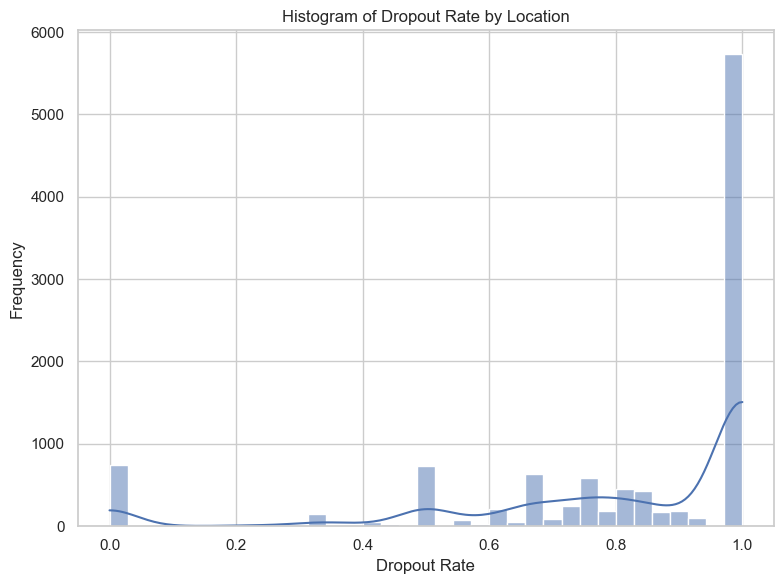

In [127]:
sns.set(style='whitegrid')

plt.figure(figsize=(8, 6))
sns.histplot(data=df_dist_Location['dropout_rate'], kde=True)
plt.title('Histogram of Dropout Rate by Location')
plt.xlabel('Dropout Rate')
plt.ylabel('Frequency')

finalize_plot("hist_dropout_rate_by_location")

## Decommisioned

In [129]:
# Check the number of unique Decommisioned
df_combined.Decommisioned.nunique()


1

In [130]:
# Delete the 'Decommisioned' variable since it only has one unique value
del df_combined['Decommisioned']
del df_combined_train['Decommisioned']
del df_combined_test['Decommisioned']


## TaxReturnsFiled

In [132]:
# Check the number of unique TaxReturnsFiled
df_combined.TaxReturnsFiled.nunique()


10304

In [133]:
# Aggregate tax returns filed statistics by dropout flag
df_dist_dropout_flg_TaxReturnsFiled = df_combined_train.filter(regex='TaxReturnsFiled|dropout_flg').groupby('dropout_flg').agg({
    'TaxReturnsFiled': ['mean', 'max', 'min']
}).reset_index()

# Display the aggregated dataframe
print("Aggregated Tax Returns Filed Statistics by Dropout Flag:")
display(df_dist_dropout_flg_TaxReturnsFiled)

# Display the correlation between dropout flag and tax returns filed
tax_returns_corr = df_combined_train['dropout_flg'].corr(df_combined_train['TaxReturnsFiled'])
print("Correlation between dropout_flg and TaxReturnsFiled:", tax_returns_corr)


Aggregated Tax Returns Filed Statistics by Dropout Flag:


dropout_flg TaxReturnsFiled                
                         mean      max    min
0           0    12787.909667  70484.0  252.0
1           1    12819.137243  70484.0  250.0

Correlation between dropout_flg and TaxReturnsFiled: 0.0015110083676973568


- Tax Returns Filed and Dropout Rates:
    - The mean number of tax returns filed is very similar for both dropout (dropout_flg = 1) and non-dropout (dropout_flg = 0) groups, with values of 12819.137243 and 12787.909667, respectively.
    - The maximum number of tax returns filed is the same for both groups, at 70,484.
    - The minimum number of tax returns filed is also nearly identical between the two groups, with values of 250 for the dropout group and 252 for the non-dropout group.
</br>
</br>
- Correlation Analysis:
    - The correlation between dropout_flg and TaxReturnsFiled is extremely weak and positive (0.0015), indicating almost no relationship.
    - This suggests that the number of tax returns filed is not a significant factor in -predicting dropout rates in this dataset.
</br>
</br>
- Minimal Impact of Tax Returns Filed:
    - Given the very weak correlation and similar statistics across both groups, the number of tax returns filed does not appear to influence the likelihood of dropping out.
    - This variable may not provide valuable predictive power for dropout rates.

## EstimatedPopulation

In [136]:
# Check the number of unique TaxReturnsFiled
df_combined.EstimatedPopulation.nunique()


12148

In [137]:
# Aggregate estimated population statistics by dropout flag
df_dist_dropout_flg_EstimatedPopulation = df_combined_train.filter(regex='EstimatedPopulation|dropout_flg').groupby('dropout_flg').agg({
    'EstimatedPopulation': ['mean', 'max', 'min']
}).reset_index()

# Display the aggregated dataframe
print("Aggregated Estimated Population Statistics by Dropout Flag:")
display(df_dist_dropout_flg_EstimatedPopulation)

# Display the correlation between dropout flag and estimated population
estimated_population_corr = df_combined_train['dropout_flg'].corr(df_combined_train['EstimatedPopulation'])
print("Correlation between dropout_flg and EstimatedPopulation:", estimated_population_corr)


Aggregated Estimated Population Statistics by Dropout Flag:


dropout_flg EstimatedPopulation                
                             mean      max    min
0           0        22333.020846  88503.0  338.0
1           1        22398.058475  88503.0  359.0

Correlation between dropout_flg and EstimatedPopulation: 0.0018024350917152778


- EstimatedPopulation shows slight differences in mean and minimum values between dropouts and non-dropouts. This small difference indicates that on average, the population sizes do not vary much between dropouts and non-dropouts.
</br>
</br>
- The extremely low correlation indicates that there is virtually no linear relationship between the estimated population size and dropout status. Therefore, EstimatedPopulation alone is not a strong predictor of whether someone will be flagged as a dropout.

## TotalWages

In [140]:
# Check the number of unique TotalWages
df_combined.TotalWages.nunique()


15872

In [141]:
# Calculate statistics for TotalWages grouped by dropout_flg
df_dist_dropout_flg_TotalWages = df_combined_train.filter(regex='TotalWages|drop').groupby('dropout_flg').agg({
    'TotalWages': ['mean', 'max', 'min']
}).reset_index()

# Display the aggregated statistics
display(df_dist_dropout_flg_TotalWages)


dropout_flg    TotalWages                         
                       mean           max        min
0           0  5.343965e+08  2.124002e+09  5293006.0
1           1  5.376323e+08  2.132870e+09  2774530.0

- Similarity in Mean and Maximum Values: 
    - The mean and maximum total wages are very similar between dropouts and non-dropouts, indicating that there is no substantial difference in total wages at the higher end of the distribution.
</br>
</br>   
- Differences in Minimum Values: 
    - The lower minimum total wages for dropouts suggest that there is a greater occurrence of lower wage values among dropouts, which might indicate economic challenges or less stable employment situations for this group.
</br>
</br>
- Implications for Predictive Modeling: 
    - While the differences in mean and maximum total wages are small, the differences in minimum wages could be an important factor to consider in predictive models. Features related to economic stability, employment history, and other financial metrics may provide additional insights into dropout status.

## time_lasps

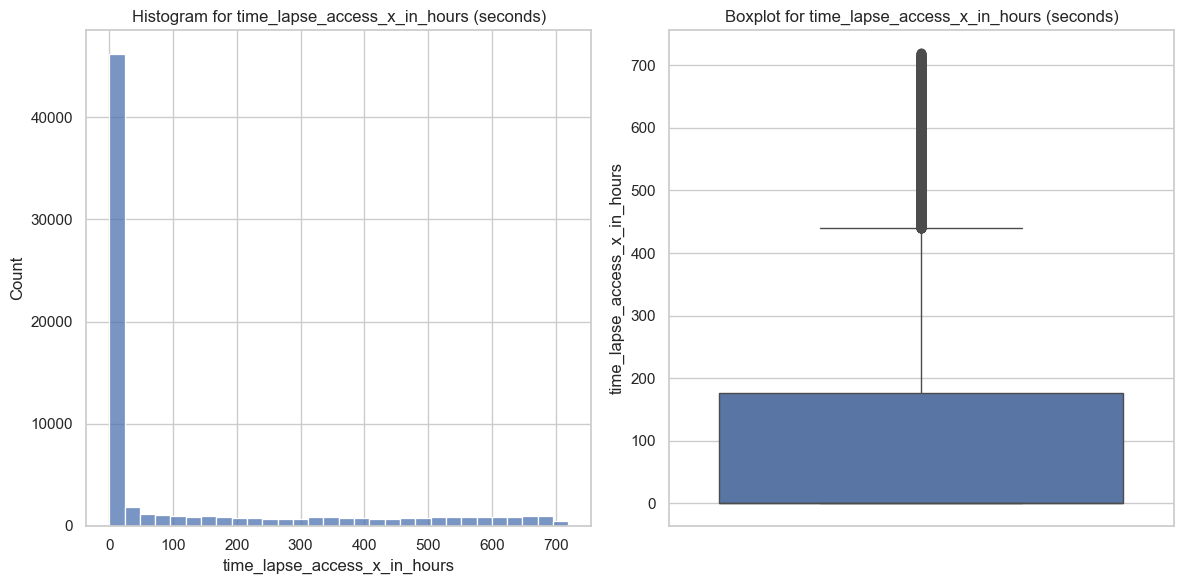

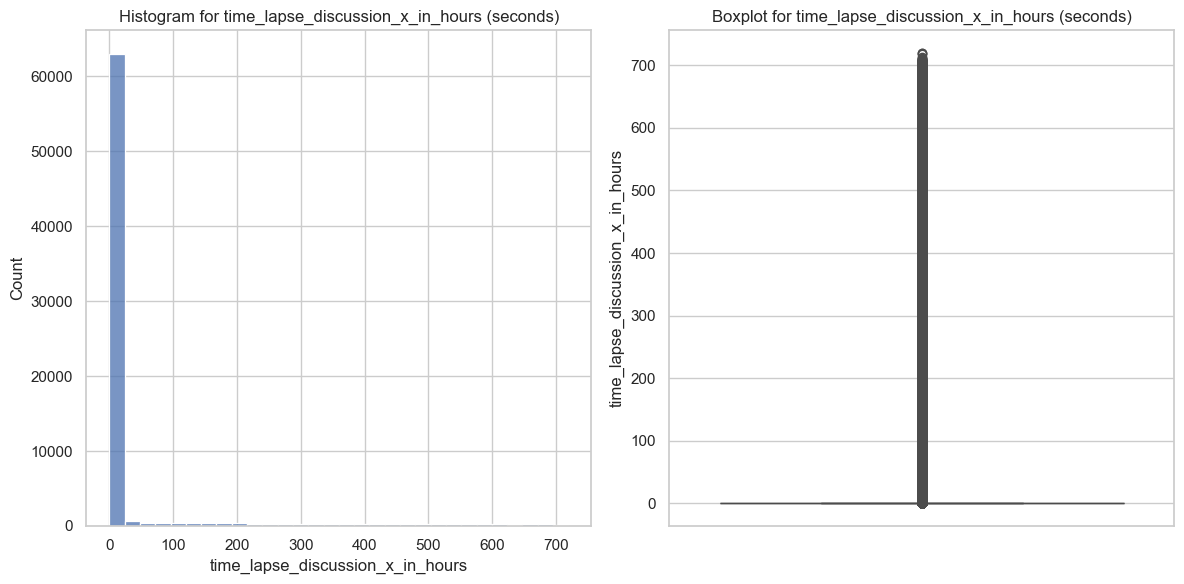

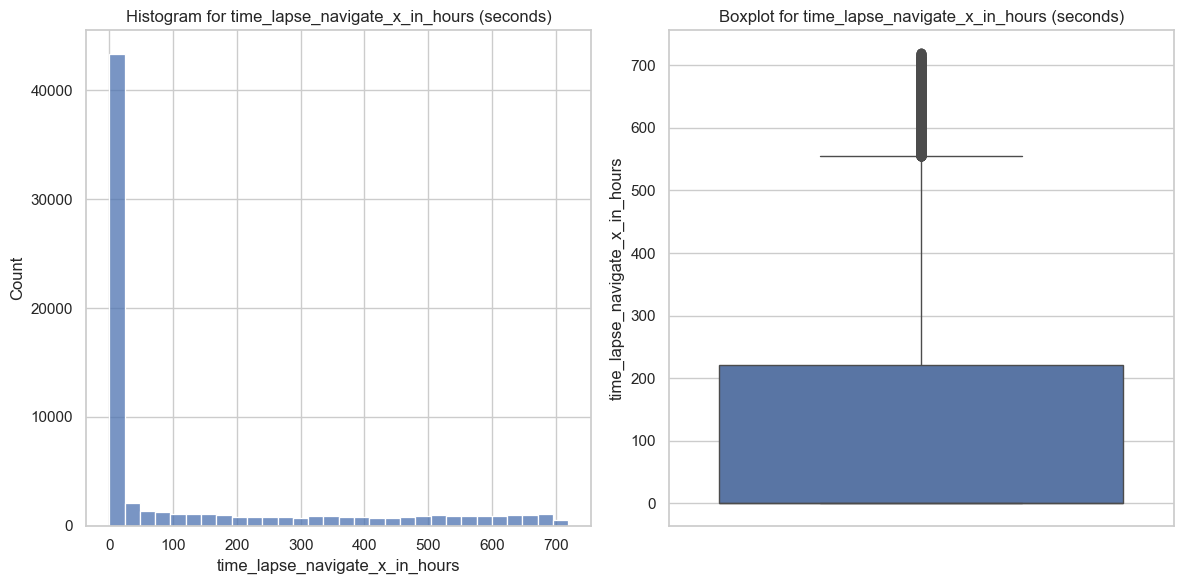

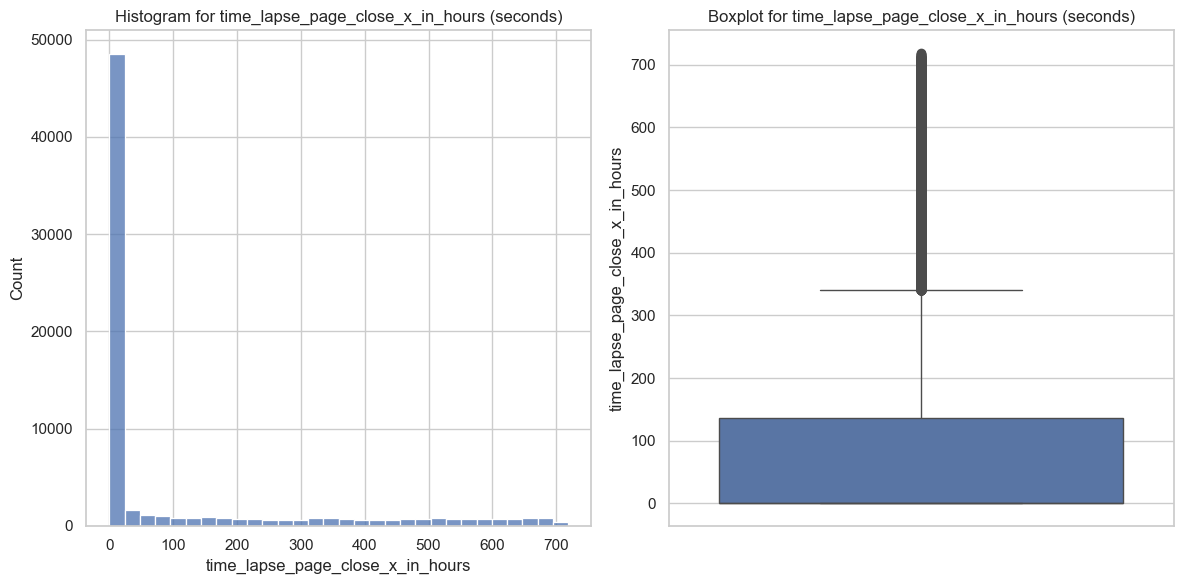

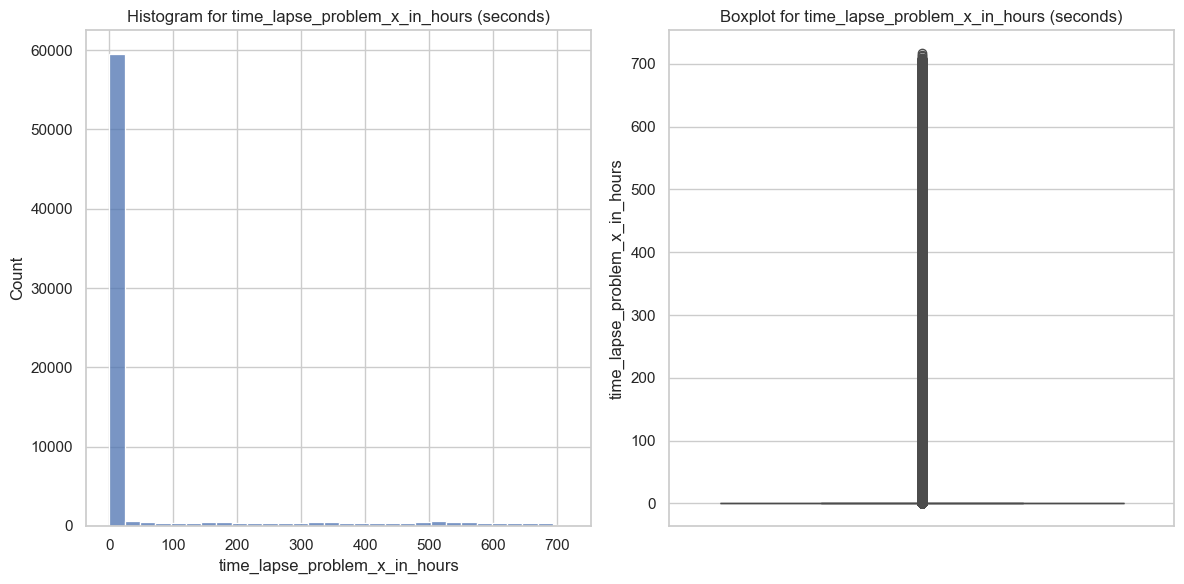

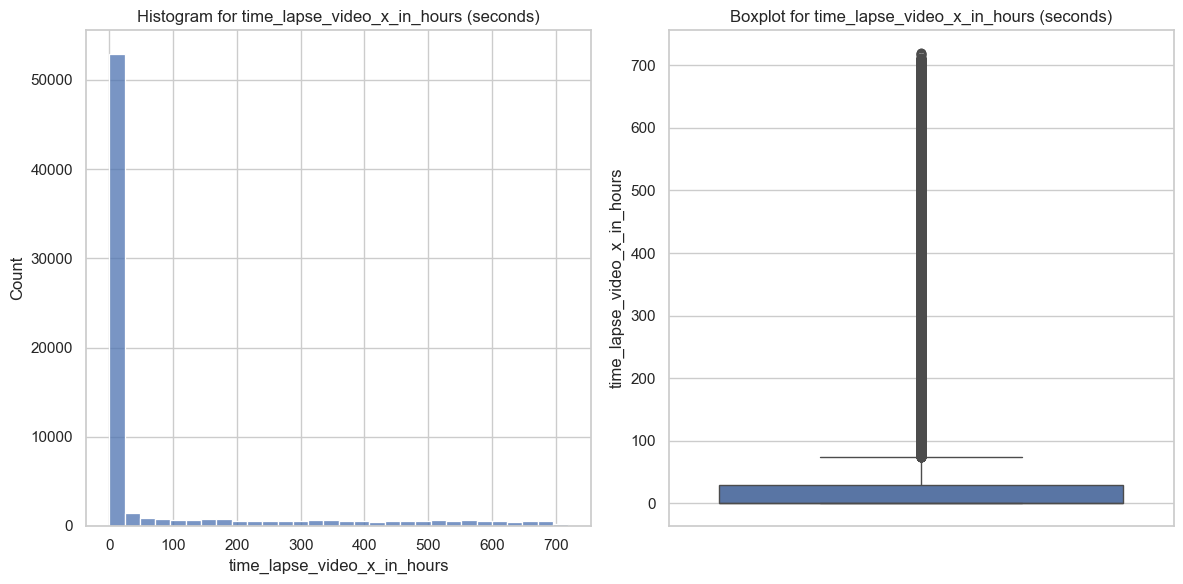

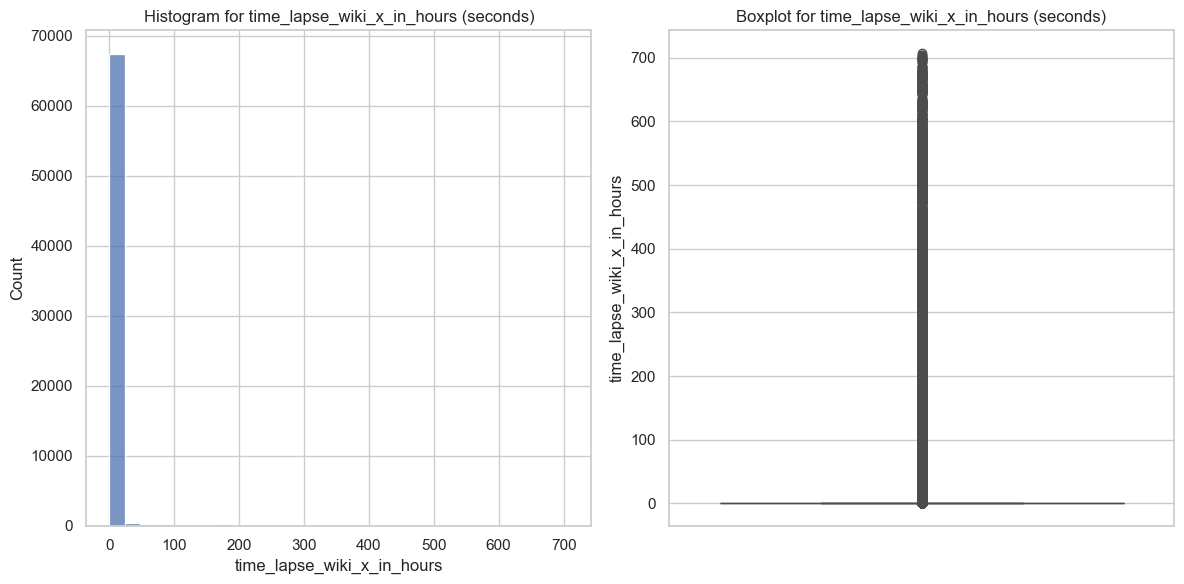

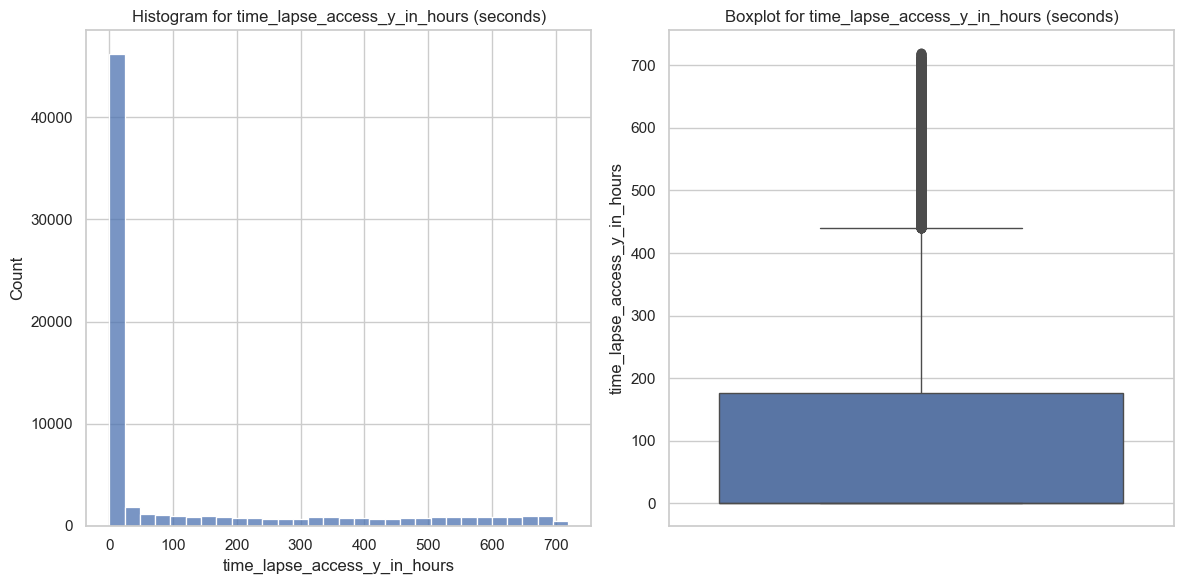

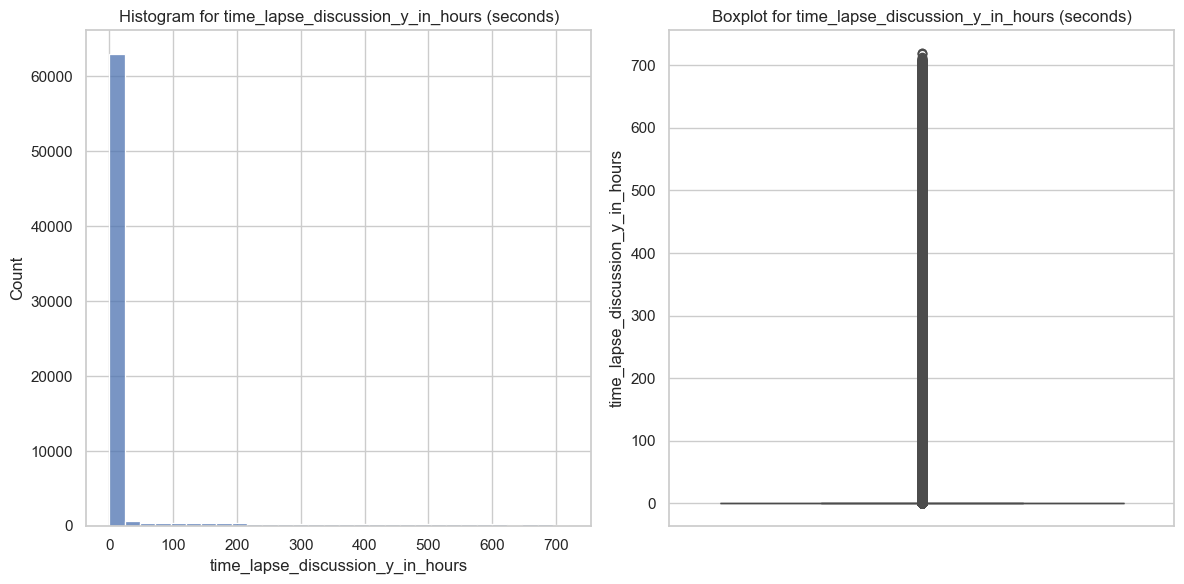

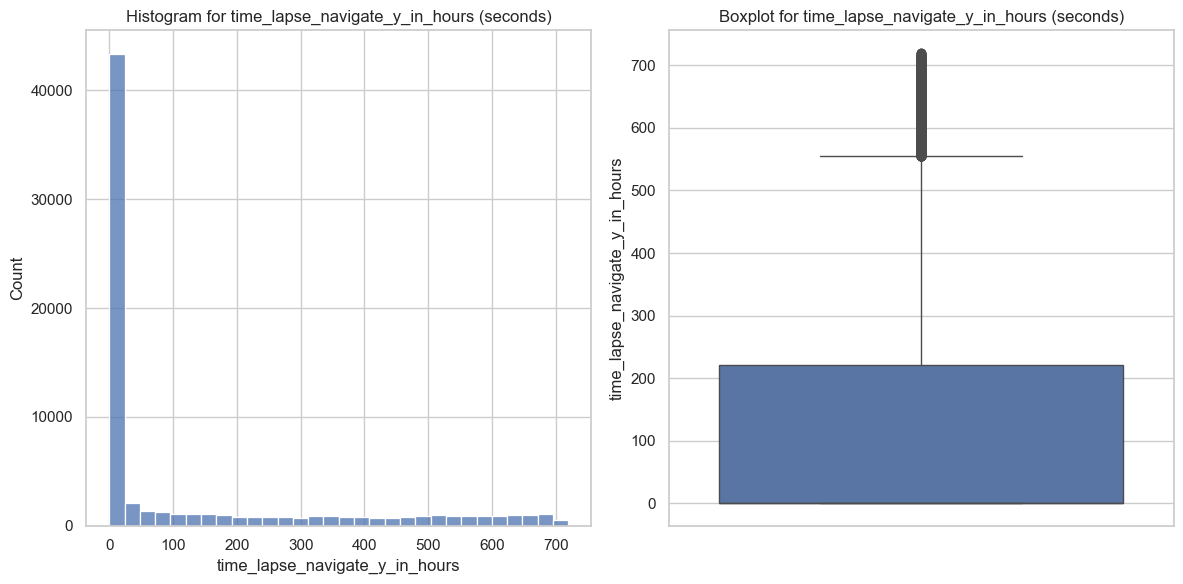

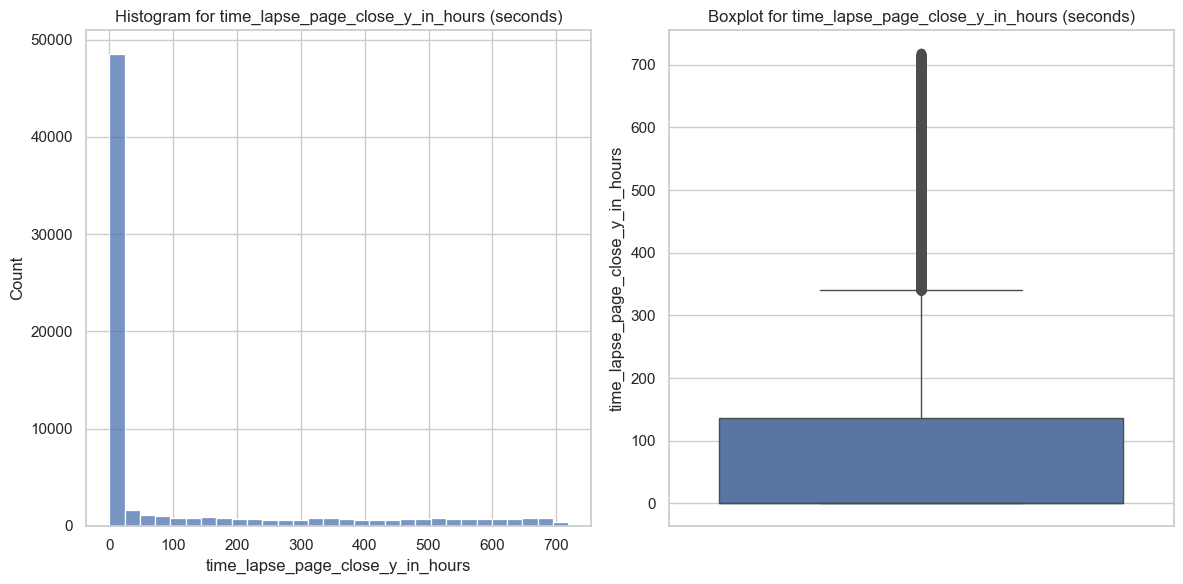

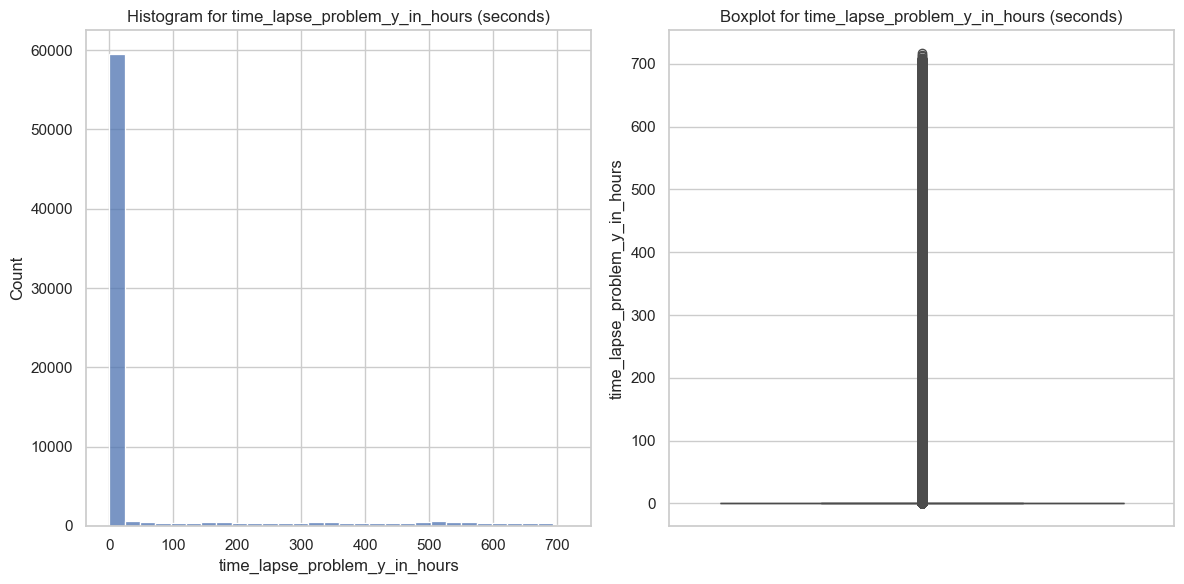

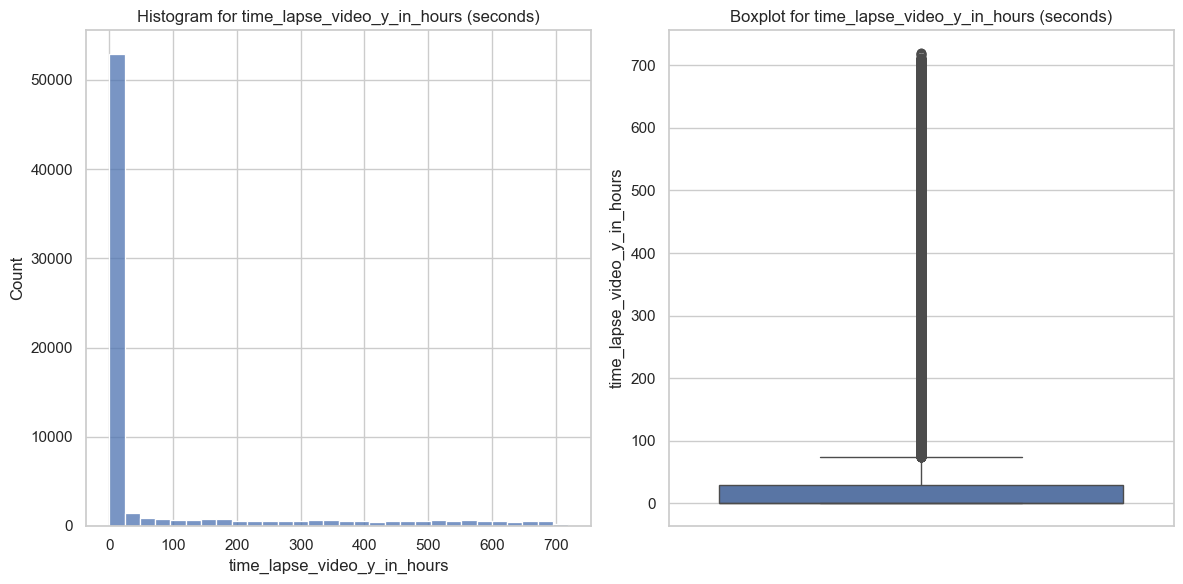

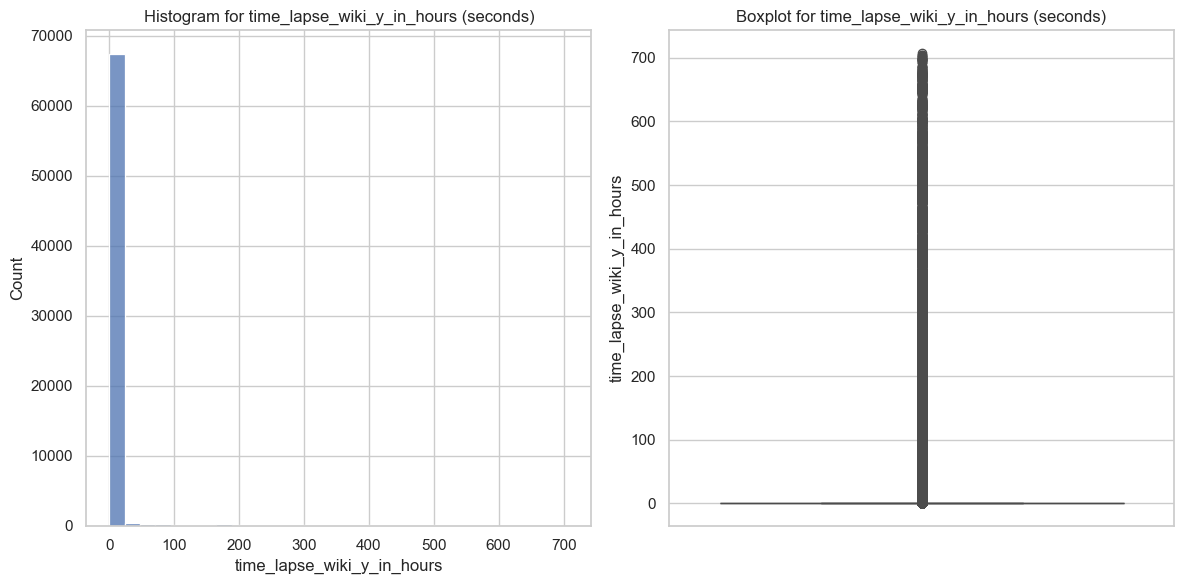

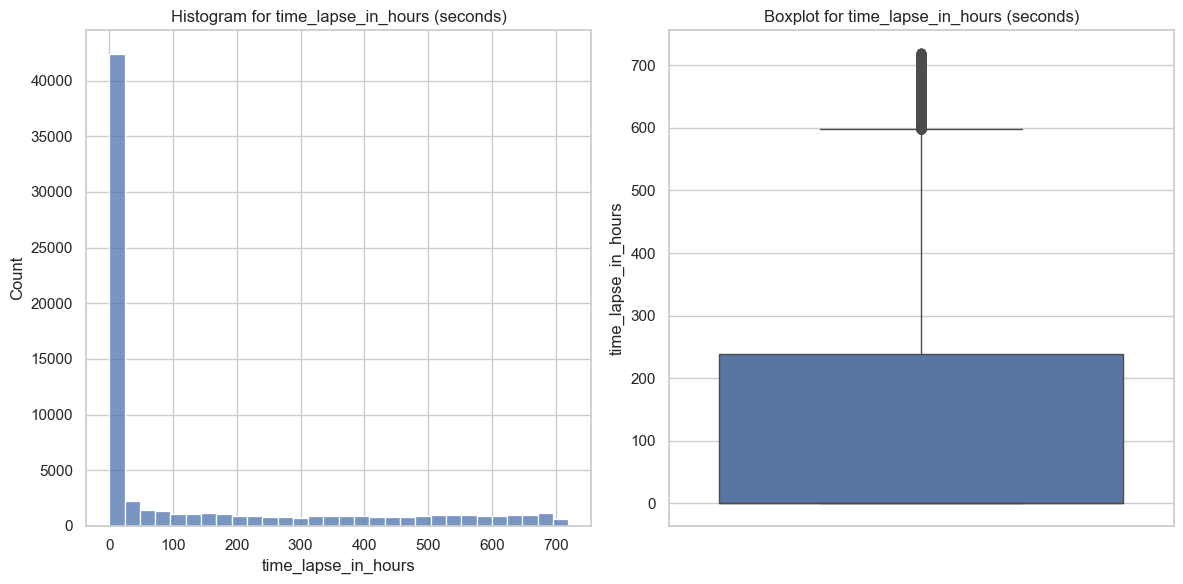

In [144]:
list_time_lapse_vars = df_combined_train.filter(regex='time_lapse').columns.tolist()
for var in list_time_lapse_vars:
    sns.set_style("whitegrid")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    sns.histplot(df_combined_train[var], ax=axes[0], kde=False, bins=30)
    axes[0].set_title('Histogram for ' + var + ' (seconds)')
    
    sns.boxplot(y=df_combined_train[var], ax=axes[1])
    axes[1].set_title('Boxplot for ' + var + ' (seconds)')
    
    fig_name = var.replace('/', '_').replace('\\', '_').replace(' ', '_')
    finalize_plot(f"hist_box_{fig_name}")

The distribution of each variable exhibits right skewness.

In [146]:
# Aggregate time_lasps variables by dropout_flg and calculate the sum
df_dist_dropout_flg_time_lapse = df_combined_train.filter(regex='time_lapse|drop').groupby('dropout_flg').sum().reset_index()

# Count the number of enrollments by dropout_flg
df_dist_dropout_flg = df_combined_train.groupby('dropout_flg').agg({'enrollment_id': 'count'}).reset_index()

# Merge the two aggregated dataframes
df_dist_dropout_flg_agg = df_dist_dropout_flg.merge(df_dist_dropout_flg_time_lapse, on='dropout_flg', how='inner')
display(df_dist_dropout_flg_agg) 

# Calculate the average time_lasps variables in hours per enrollment_id
for column in list_time_lapse_vars:
    df_dist_dropout_flg_agg[column] = round(df_dist_dropout_flg_agg[column] / df_dist_dropout_flg_agg['enrollment_id'], 4)

display(df_dist_dropout_flg_agg) 


,dropout_flg,enrollment_id,time_lapse_access_x_in_hours,time_lapse_discussion_x_in_hours,time_lapse_navigate_x_in_hours,time_lapse_page_close_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,0,14823,5.151487e+06,1.927825e+06,5.309623e+06,4.752128e+06,3187809.940,3.853087e+06,773669.257500,5.151487e+06,1.927825e+06,5.309623e+06,4.752128e+06,3187809.940,3.853087e+06,773669.257500,5.454361e+06
1,1,56571,3.660020e+06,7.093658e+05,4.348334e+06,3.174940e+06,1005523.245,2.281469e+06,295146.187222,3.660020e+06,7.093658e+05,4.348334e+06,3.174940e+06,1005523.245,2.281469e+06,295146.187222,4.512958e+06


,dropout_flg,enrollment_id,time_lapse_access_x_in_hours,time_lapse_discussion_x_in_hours,time_lapse_navigate_x_in_hours,time_lapse_page_close_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_video_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_access_y_in_hours,time_lapse_discussion_y_in_hours,time_lapse_navigate_y_in_hours,time_lapse_page_close_y_in_hours,time_lapse_problem_y_in_hours,time_lapse_video_y_in_hours,time_lapse_wiki_y_in_hours,time_lapse_in_hours
0,0,14823,347.5334,130.0563,358.2016,320.5915,215.0584,259.9397,52.1938,347.5334,130.0563,358.2016,320.5915,215.0584,259.9397,52.1938,367.9661
1,1,56571,64.6978,12.5394,76.8651,56.1231,17.7745,40.3293,5.2173,64.6978,12.5394,76.8651,56.1231,17.7745,40.3293,5.2173,79.7751


- Non-dropouts (dropout_flg = 0) have higher total and average time spent across all activity categories compared to dropouts (dropout_flg = 1). This suggests that non-dropouts are generally more engaged with the course materials.
- Across the top engagement-related features, non-dropout users consistently exhibit higher engagement levels than dropout users.

Top features by KS: ['time_lapse_access_x_in_hours', 'time_lapse_page_close_x_in_hours', 'time_lapse_navigate_x_in_hours', 'time_lapse_problem_x_in_hours', 'time_lapse_video_x_in_hours', 'time_lapse_discussion_x_in_hours']


,feature,ks
0,time_lapse_access_x_in_hours,0.544294
3,time_lapse_page_close_x_in_hours,0.531031
2,time_lapse_navigate_x_in_hours,0.526570
4,time_lapse_problem_x_in_hours,0.507788
5,time_lapse_video_x_in_hours,0.485323
1,time_lapse_discussion_x_in_hours,0.369848
6,time_lapse_wiki_x_in_hours,0.199553


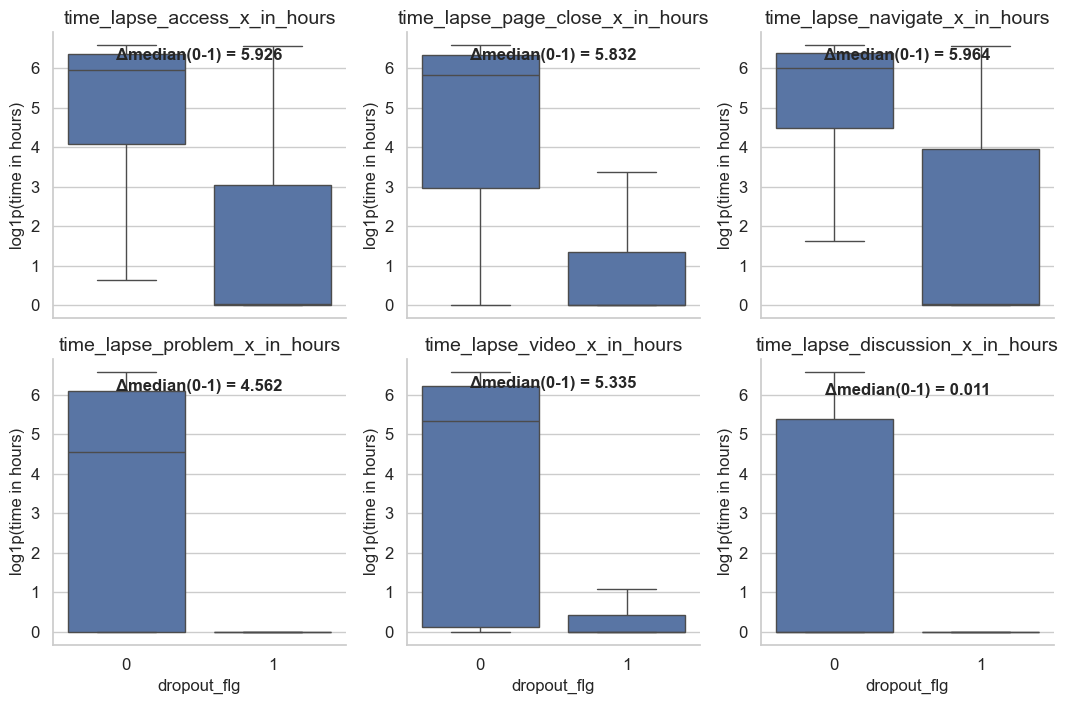

In [148]:
K = 6
scores = []
filtered_time_lapse_vars = [
    c for c in list_time_lapse_vars
    if c.endswith("_x_in_hours")
]
for col in filtered_time_lapse_vars:
    s0 = df_combined_train.loc[df_combined_train['dropout_flg'] == 0, col].dropna().astype(float)
    s1 = df_combined_train.loc[df_combined_train['dropout_flg'] == 1, col].dropna().astype(float)
    if len(s0) < 30 or len(s1) < 30:
        continue
    x0 = np.log1p(s0.values)
    x1 = np.log1p(s1.values)
    ks = ks_2samp(x0, x1).statistic
    scores.append((col, ks))

score_df = pd.DataFrame(scores, columns=['feature', 'ks']).sort_values('ks', ascending=False)
topK = score_df.head(K)['feature'].tolist()
print("Top features by KS:", topK)
display(score_df.head(10))

# ========= Convert to a longer table (retain only TopK) =========
plot_df = df_combined_train[['dropout_flg'] + topK].copy().dropna(subset=topK)
long_df = plot_df.melt(
    id_vars='dropout_flg',
    value_vars=topK,
    var_name='feature',
    value_name='hours'
)
long_df['log_hours'] = np.log1p(long_df['hours'])

# ========= picture Box plot (TopK points surface) marked in digits =========
sns.set(style="whitegrid")
g = sns.FacetGrid(long_df, col="feature", col_wrap=3, sharey=False, height=3.6)
g.map_dataframe(
    sns.boxplot,
    x="dropout_flg",
    y="log_hours",
    showfliers=False,
    whis=1.5
)

for ax in g.axes.flat:
    feat = ax.get_title().replace("feature = ", "")
    tmp = long_df[long_df['feature'] == feat]
    med0 = tmp.loc[tmp['dropout_flg'] == 0, 'log_hours'].median()
    med1 = tmp.loc[tmp['dropout_flg'] == 1, 'log_hours'].median()
    delta = med0 - med1
    y_top = tmp['log_hours'].quantile(0.98)
    ax.text(0.5, y_top, f"Δmedian(0-1) = {delta:.3f}",
            ha="center", va="top", fontsize=12, fontweight="bold")
    ax.set_xlabel("dropout_flg")
    ax.set_ylabel("log1p(time in hours)")
    ax.tick_params(axis='both', labelsize=12)

g.set_titles("{col_name}", size=14)

plt.tight_layout()
finalize_plot("boxplot_top6_time_lapse_by_dropout")

The box plots of the top engagement-related features show a consistent and robust separation between dropout and non-dropout users.

Across all selected features, non-dropout users exhibit substantially higher median engagement levels, while dropout users concentrate near the lower end of the distribution. Importantly, the observed differences are driven by shifts in the median rather than extreme outliers, indicating systematic behavioral differences rather than noise from a small number of highly active users.

This pattern suggests that sustained and consistent engagement intensity is strongly associated with course completion, and validates the discriminative power of these features for downstream modeling.

# Multicolinearity Issue Checking

In [151]:
# Identify continuous variables
list_continuous_vars = df_combined_train.select_dtypes(include=[np.number]).columns.tolist()
list_continuous_vars.remove('enrollment_id')
list_continuous_vars.remove('dropout_flg')

# Calculate correlation matrix
correlation_matrix = df_combined_train[list_continuous_vars].corr()

# Calculate VIF for each variable 
vif_data = pd.DataFrame()
vif_data["Variable"] = list_continuous_vars
vif_data["VIF"] = [variance_inflation_factor(df_combined_train[list_continuous_vars].values, i) for i in range(len(list_continuous_vars))]

print("\nVariance Inflation Factors:")
display(vif_data)
# display(correlation_matrix)



Variance Inflation Factors:


,Variable,VIF
0,object_count_access,inf
1,object_count_discussion,9.007199e+15
2,object_count_navigate,6.928615e+14
3,object_count_page_close,inf
4,object_count_problem,inf
5,object_count_video,3.002400e+15
6,object_count_wiki,3.916174e+14
7,object_nunique_access,9.260120e+02
8,object_nunique_discussion,5.086186e+00
9,object_nunique_navigate,8.064710e+01


业务意义
VIF > 10：变量与其他自变量高度相关，可能冗余

In [153]:
# Function to calculate VIF 
dict_removed_var = {}
def calculate_vif(df, excluded_vars):
    vif_data = pd.DataFrame()
    continuous_vars = [col for col in df.select_dtypes(include=[np.number]).columns if col not in excluded_vars]
    vif_data["Variable"] = continuous_vars
    vif_data["VIF"] = [variance_inflation_factor(df[continuous_vars].values, i) for i in range(len(continuous_vars))]
    return vif_data

# Initial excluded variables (those with 'inf' VIF) 
excluded_vars = ['enrollment_id', 'dropout_flg', 'object_count_access', 'object_count_discussion', 'object_count_page_close', 'object_count_problem', 'object_count']

# Recalculate VIF
vif_data = calculate_vif(df_combined_train, excluded_vars)
print("\nVariance Inflation Factors after initial removal:")
display(vif_data)

# Iteratively remove variables with high VIF and recalculate
iteration = 0
while vif_data['VIF'].max() > 10:   
    max_vif_var = vif_data.sort_values('VIF', ascending=False).iloc[0]['Variable']
    max_vif_value = vif_data.sort_values('VIF', ascending=False).iloc[0]['VIF']
    print(f"\nIteration {iteration}: Removed variable '{max_vif_var}' with VIF {max_vif_value}")
    excluded_vars.append(max_vif_var)                          
    vif_data = calculate_vif(df_combined_train, excluded_vars) 
    dict_removed_var[max_vif_var] = vif_data                   
    iteration += 1

display(vif_data)



Variance Inflation Factors after initial removal:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



Iteration 0: Removed variable 'time_lapse_page_close_x_in_hours' with VIF inf

Iteration 1: Removed variable 'time_lapse_discussion_x_in_hours' with VIF inf

Iteration 2: Removed variable 'time_lapse_access_y_in_hours' with VIF inf

Iteration 3: Removed variable 'time_lapse_video_x_in_hours' with VIF inf

Iteration 4: Removed variable 'time_lapse_wiki_y_in_hours' with VIF inf

Iteration 5: Removed variable 'time_lapse_problem_y_in_hours' with VIF inf

Iteration 6: Removed variable 'time_lapse_navigate_y_in_hours' with VIF inf

Iteration 7: Removed variable 'object_nunique' with VIF 4966.8268194713055

Iteration 8: Removed variable 'EstimatedPopulation' with VIF 169.32793505216432

Iteration 9: Removed variable 'source_nunique' with VIF 154.748995071269

Iteration 10: Removed variable 'Long' with VIF 107.42523773653393

Iteration 11: Removed variable 'time_lapse_in_hours' with VIF 81.2246709342444

Iteration 12: Removed variable 'event_nunique' with VIF 71.44202662100777

Iteration 13:

,Variable,VIF
0,object_count_navigate,3.994986
1,object_count_video,6.916545
2,object_count_wiki,1.464140
3,object_nunique_access,6.431171
4,object_nunique_discussion,2.780985
5,object_nunique_page_close,4.393119
6,object_nunique_problem,2.121399
7,object_nunique_video,8.651603
8,object_nunique_wiki,2.376366
9,zip,3.619889


In [154]:
# Display the dictionary with VIF data after each removal
for var, vif_df in dict_removed_var.items():
   print(f"\nVIF after removing {var}:")
   display(vif_df)


VIF after removing time_lapse_page_close_x_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_discussion_x_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_access_y_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_video_x_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_wiki_y_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_problem_y_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing time_lapse_navigate_y_in_hours:


,Variable,VIF
0,object_count_navigate,4.363939
1,object_count_video,7.094268
2,object_count_wiki,1.472413
3,object_nunique_access,915.937660
4,object_nunique_discussion,5.077212
5,object_nunique_navigate,79.835633
6,object_nunique_page_close,32.575236
7,object_nunique_problem,591.603277
8,object_nunique_video,403.019945
9,object_nunique_wiki,4.827681



VIF after removing object_nunique:


,Variable,VIF
0,object_count_navigate,4.363720
1,object_count_video,6.943884
2,object_count_wiki,1.472412
3,object_nunique_access,6.900543
4,object_nunique_discussion,5.053896
5,object_nunique_navigate,13.493890
6,object_nunique_page_close,32.362524
7,object_nunique_problem,2.135065
8,object_nunique_video,8.818156
9,object_nunique_wiki,4.809695



VIF after removing EstimatedPopulation:


,Variable,VIF
0,object_count_navigate,4.363719
1,object_count_video,6.943842
2,object_count_wiki,1.472411
3,object_nunique_access,6.900477
4,object_nunique_discussion,5.053894
5,object_nunique_navigate,13.493719
6,object_nunique_page_close,32.326479
7,object_nunique_problem,2.135058
8,object_nunique_video,8.818152
9,object_nunique_wiki,4.809522



VIF after removing source_nunique:


,Variable,VIF
0,object_count_navigate,4.360960
1,object_count_video,6.942704
2,object_count_wiki,1.472376
3,object_nunique_access,6.899795
4,object_nunique_discussion,4.653580
5,object_nunique_navigate,13.358048
6,object_nunique_page_close,22.876540
7,object_nunique_problem,2.134551
8,object_nunique_video,8.787696
9,object_nunique_wiki,4.427781



VIF after removing Long:


,Variable,VIF
0,object_count_navigate,4.360400
1,object_count_video,6.942576
2,object_count_wiki,1.472200
3,object_nunique_access,6.889073
4,object_nunique_discussion,4.570488
5,object_nunique_navigate,13.154565
6,object_nunique_page_close,22.437927
7,object_nunique_problem,2.134327
8,object_nunique_video,8.785866
9,object_nunique_wiki,4.313111



VIF after removing time_lapse_in_hours:


,Variable,VIF
0,object_count_navigate,4.338746
1,object_count_video,6.933188
2,object_count_wiki,1.471805
3,object_nunique_access,6.883939
4,object_nunique_discussion,4.570430
5,object_nunique_navigate,13.145962
6,object_nunique_page_close,22.437513
7,object_nunique_problem,2.134156
8,object_nunique_video,8.782154
9,object_nunique_wiki,4.312449



VIF after removing event_nunique:


,Variable,VIF
0,object_count_navigate,4.324923
1,object_count_video,6.929676
2,object_count_wiki,1.469662
3,object_nunique_access,6.707066
4,object_nunique_discussion,2.938066
5,object_nunique_navigate,12.842205
6,object_nunique_page_close,4.703512
7,object_nunique_problem,2.124602
8,object_nunique_video,8.756282
9,object_nunique_wiki,3.563341



VIF after removing time_lapse_access_x_in_hours:


,Variable,VIF
0,object_count_navigate,4.321171
1,object_count_video,6.929655
2,object_count_wiki,1.469642
3,object_nunique_access,6.514954
4,object_nunique_discussion,2.935118
5,object_nunique_navigate,12.840684
6,object_nunique_page_close,4.702817
7,object_nunique_problem,2.123394
8,object_nunique_video,8.652899
9,object_nunique_wiki,3.562056



VIF after removing object_nunique_navigate:


,Variable,VIF
0,object_count_navigate,3.995251
1,object_count_video,6.916848
2,object_count_wiki,1.464152
3,object_nunique_access,6.456725
4,object_nunique_discussion,2.781559
5,object_nunique_page_close,4.418455
6,object_nunique_problem,2.123386
7,object_nunique_video,8.652391
8,object_nunique_wiki,2.376603
9,zip,3.620030



VIF after removing time_lapse_page_close_y_in_hours:


,Variable,VIF
0,object_count_navigate,3.994986
1,object_count_video,6.916545
2,object_count_wiki,1.464140
3,object_nunique_access,6.431171
4,object_nunique_discussion,2.780985
5,object_nunique_page_close,4.393119
6,object_nunique_problem,2.121399
7,object_nunique_video,8.651603
8,object_nunique_wiki,2.376366
9,zip,3.619889


In [155]:
df_combined_train.columns


Index(['enrollment_id', 'username', 'course_id', 'object_count_access',
       'object_count_discussion', 'object_count_navigate',
       'object_count_page_close', 'object_count_problem', 'object_count_video',
       'object_count_wiki', 'object_nunique_access',
       'object_nunique_discussion', 'object_nunique_navigate',
       'object_nunique_page_close', 'object_nunique_problem',
       'object_nunique_video', 'object_nunique_wiki', 'event_nunique',
       'object_nunique', 'object_count', 'source_nunique', 'gender', 'zip',
       'highest_education', 'ZipCodeType', 'City', 'State', 'Lat', 'Long',
       'Location', 'TaxReturnsFiled', 'EstimatedPopulation', 'TotalWages',
       'dropout_flg', 'time_lapse_access_x_in_hours',
       'time_lapse_discussion_x_in_hours', 'time_lapse_navigate_x_in_hours',
       'time_lapse_page_close_x_in_hours', 'time_lapse_problem_x_in_hours',
       'time_lapse_video_x_in_hours', 'time_lapse_wiki_x_in_hours',
       'time_lapse_access_y_in_hours', 

In [156]:
# Ensure 'enrollment_id' and 'dropout_flg' are not in the list of excluded variables 
list_excluded_vars_final = list(set(excluded_vars) - set(['enrollment_id', 'dropout_flg']))

# Drop the excluded variables from the train and test datasets
df_combined_train = df_combined_train.drop(columns=list_excluded_vars_final)
df_combined_test = df_combined_test.drop(columns=list_excluded_vars_final)

# Display the results
print("Train DataFrame:")
display(df_combined_train.head())
print("Train DataFrame shape:", df_combined_train.shape)
print()
print("Test DataFrame:")
display(df_combined_test.head())
print("Test DataFrame shape:", df_combined_test.shape)


Train DataFrame:


,enrollment_id,username,course_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,...,Lat,Location,TaxReturnsFiled,TotalWages,dropout_flg,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,15.0,4.0,0.0,20.0,0.0,1.0,2.0,...,28.50,NA-US-FL-ORLANDO,9630.0,2.634592e+08,0,417.806111,228.463333,0.0,0.000000,275.099444
1,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,30.0,86.0,0.0,27.0,1.0,1.0,41.0,...,39.18,NA-US-MD-MONTGOMERY VILLAGE,16250.0,7.901124e+08,0,709.070556,663.489722,0.0,504.917778,667.085000
2,7,I1KwJ6EdCZnEPLfC8Q7yWpIkLOHn7h02,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,20.0,69.0,0.0,27.0,1.0,1.0,27.0,...,33.24,NA-US-AZ-CHANDLER,14899.0,1.041948e+09,1,623.532222,454.510000,0.0,98.608611,623.558056
3,13,hDbSkVrFRj9Ryk3c5E1JYJQLyxm4jLRb,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,15.0,69.0,0.0,25.0,1.0,1.0,39.0,...,33.93,NA-US-CA-INGLEWOOD,10227.0,2.783558e+08,0,546.253611,127.832778,0.0,0.011111,528.580000
4,14,XOhIczT5nEeO52jMq1vN7QziDk8L2jnI,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,20.0,5.0,0.0,31.0,0.0,1.0,3.0,...,41.55,NA-US-IA-DAVENPORT,10127.0,3.440549e+08,1,383.250833,250.342778,0.0,0.000000,312.698889


Train DataFrame shape: (71394, 28)

Test DataFrame:


,enrollment_id,username,course_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,...,Lat,Location,TaxReturnsFiled,TotalWages,dropout_flg,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,49,2oTvbzieHn2y5oozeOgSnruqE6N0BtR5,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,160.0,45.0,0.0,40.0,1.0,1.0,25.0,...,33.10,NA-US-TX-ALLEN,26758.0,1.705836e+09,NaN,711.442222,652.811111,0.0,711.380556,697.001944
1,550,VPdjVqsNJz0vApjLBU3Ub91sUJQs6bQA,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,12.0,1.0,1.0,12.0,0.0,1.0,1.0,...,29.83,NA-US-LA-BALDWIN,1255.0,3.723304e+07,NaN,23.233611,0.000000,0.0,0.000000,0.000000
2,580,lI1T6GH5teIzoXuk2SnQImyBaJNBXH97,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,29.0,13.0,0.0,29.0,1.0,1.0,9.0,...,41.47,NA-US-OH-CLEVELAND,17993.0,4.573687e+08,NaN,681.415556,608.785278,0.0,677.156944,681.893056
3,751,z04KmtFWoU6v2MNUFLGwDE6pRo1yPrDS,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,45.0,13.0,1.0,35.0,1.0,1.0,15.0,...,40.71,NA-US-NY-NEW YORK,30434.0,1.264532e+09,NaN,631.604167,605.113889,0.0,616.862222,597.941944
4,1621,hM78zuTWvc2c2WdiFwwJZnLKCiMEzZwE,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,13.0,25.0,0.0,21.0,1.0,1.0,55.0,...,38.03,NA-US-CA-RODEO,3769.0,1.608465e+08,NaN,241.087500,241.075000,0.0,240.808889,241.068333


Test DataFrame shape: (1000, 28)


# Check Categorical Variables

## username

In [159]:
# Display the number of unique usernames
unique_usernames = df_combined['username'].nunique()
print(f"Number of unique usernames: {unique_usernames}")

# Aggregate the data by 'username' and calculate the number of unique 'enrollment_id' for each
df_dist_username = df_combined.groupby('username').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)

# Create a box plot for the distribution of 'enrollment_id'
fig = px.box(df_dist_username, 'enrollment_id', title='Distribution of Enrollment ID Counts per Username', labels={'enrollment_id': 'Number of Enrollments'})
fig.show()


Number of unique usernames: 53870


In [160]:
# Dropping the 'username' column from the combined, train, and test dataframes
if 'username' in df_combined.columns:
    df_combined.drop(columns=['username'], inplace=True)
    
if 'username' in df_combined_train.columns:
    df_combined_train.drop(columns=['username'], inplace=True)
    
if 'username' in df_combined_test.columns:
    df_combined_test.drop(columns=['username'], inplace=True)

## course_id

In [162]:
# Display the number of unique course IDs
unique_course_ids = df_combined['course_id'].nunique()
print(f"Number of unique course IDs: {unique_course_ids}")

# Aggregate the data by 'course_id' and calculate the number of unique 'enrollment_id' for each course
df_dist_course_id = df_combined.groupby('course_id').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)

# Create a box plot for the distribution of 'enrollment_id'
fig = px.box(df_dist_course_id, 'enrollment_id', title='Distribution of Enrollment ID Counts per Course', labels={'enrollment_id': 'Number of Enrollments'})
fig.update_layout(yaxis_title='Number of Enrollments')
fig.show()


Number of unique course IDs: 39


In [163]:
df_dist_course_id['pct_enrollment_id'] = (
    df_dist_course_id['enrollment_id'] / df_dist_course_id['enrollment_id'].sum()
)
display(df_dist_course_id)

top_n = 10
top_courses = df_combined['course_id'].value_counts().nlargest(top_n).index

pct_top_courses_enrollment = (
    df_dist_course_id[df_dist_course_id['course_id'].isin(top_courses)]
    ['pct_enrollment_id']
    .sum()
)
print(f'The percentage of enrollment_id from the top {top_n} course_id: {round(pct_top_courses_enrollment, 4)}')


,course_id,enrollment_id,pct_enrollment_id
6,81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,7310,0.100975
13,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,6240,0.086195
18,I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,5636,0.077852
16,H2lDW05SyKnwntZ6Fora76aPAEswcMa5,4920,0.067961
11,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,4608,0.063652
22,SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,3520,0.048623
38,ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ,2946,0.040694
35,shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI,2808,0.038788
7,9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,2573,0.035542
24,V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,2414,0.033345


The percentage of enrollment_id from the top 10 course_id: 0.5936


In [164]:
# Apply the same logic to train and test datasets
df_combined_train['course_id'] = np.where(df_combined_train['course_id'].isin(top_courses), df_combined_train['course_id'], 'other')
df_combined_train = pd.get_dummies(df_combined_train, columns=['course_id'], prefix='course')  

df_combined_test['course_id'] = np.where(df_combined_test['course_id'].isin(top_courses), df_combined_test['course_id'], 'other')
df_combined_test = pd.get_dummies(df_combined_test, columns=['course_id'], prefix='course')

display(df_combined_train.head())
display(df_combined_train.shape)
display(df_combined_test.head())
display(df_combined_test.shape)


,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI,course_ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ
0,4,15.0,4.0,0.0,20.0,0.0,1.0,2.0,3.0,0.0,...,False,False,True,False,False,False,False,False,False,False
1,5,30.0,86.0,0.0,27.0,1.0,1.0,41.0,38.0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,7,20.0,69.0,0.0,27.0,1.0,1.0,27.0,27.0,0.0,...,False,False,False,False,False,False,False,True,False,False
3,13,15.0,69.0,0.0,25.0,1.0,1.0,39.0,35.0,0.0,...,False,False,False,False,False,False,False,True,False,False
4,14,20.0,5.0,0.0,31.0,0.0,1.0,3.0,5.0,0.0,...,False,False,True,False,False,False,False,False,False,False


(71394, 37)

,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI,course_ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ
0,49,160.0,45.0,0.0,40.0,1.0,1.0,25.0,26.0,0.0,...,False,False,False,False,False,False,False,True,False,False
1,550,12.0,1.0,1.0,12.0,0.0,1.0,1.0,1.0,1.0,...,False,False,True,False,False,False,False,False,False,False
2,580,29.0,13.0,0.0,29.0,1.0,1.0,9.0,8.0,0.0,...,False,False,True,False,False,False,False,False,False,False
3,751,45.0,13.0,1.0,35.0,1.0,1.0,15.0,11.0,1.0,...,False,False,True,False,False,False,False,False,False,False
4,1621,13.0,25.0,0.0,21.0,1.0,1.0,55.0,21.0,0.0,...,False,False,False,False,False,False,False,True,False,False


(1000, 37)

## City

In [166]:
# Display the number of unique cities
unique_cities = df_combined['City'].nunique()
print(f"Number of unique cities: {unique_cities}")

# Aggregate the data by 'City' and calculate the number of unique 'enrollment_id' for each city
df_dist_City = df_combined.groupby('City').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)

# Create a box plot for the distribution of 'enrollment_id' counts per city
fig = px.box(df_dist_City, 'enrollment_id', title='Distribution of Enrollment ID Counts per City', labels={'enrollment_id': 'Number of Enrollments'})
fig.update_layout(yaxis_title='Number of Enrollments')
fig.show()


Number of unique cities: 7898


In [167]:
# Calculate percentage of enrollment_id for each city
df_dist_city = df_combined.groupby('City').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)
df_dist_city['pct_enrollment_id'] = df_dist_city['enrollment_id'] / df_dist_city['enrollment_id'].sum()  
display(df_dist_city)

# One-Hot Encoding for top N cities
top_n = 10
top_cities = df_combined['City'].value_counts().nlargest(top_n).index 

# Calculate the percentage of enrollments from the top N cities
pct_top_cities_enrollment = df_dist_city[df_dist_city['City'].isin(top_cities)]['pct_enrollment_id'].sum()
print(f'The percentage of enrollment_id from the top {top_n} cities: {round(pct_top_cities_enrollment, 4)}')


,City,enrollment_id,pct_enrollment_id
3240,HOUSTON,612,0.008454
1223,CHICAGO,556,0.007680
814,BROOKLYN,531,0.007335
4037,LOS ANGELES,411,0.005677
4459,MIAMI,394,0.005442
...,...,...,...
4247,MARKS,1,0.000014
2557,GARRETTSVILLE,1,0.000014
6335,SAUTEE NACOOCHEE,1,0.000014
4246,MARKLEYSBURG,1,0.000014


The percentage of enrollment_id from the top 10 cities: 0.0578


In [168]:
# Decided to drop the column 
del df_combined['City']
del df_combined_train['City']
del df_combined_test['City']


## State

In [170]:
# Display the number of unique States
unique_states = df_combined['State'].nunique()
print(f"Number of unique states: {unique_states}")

# Aggregate the data by 'State' and calculate the number of unique 'enrollment_id' for each state
df_dist_State = df_combined.groupby('State').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)

# Visualize the distribution of enrollment counts per state using a box plot
fig = px.box(df_dist_State, 'enrollment_id', title='Distribution of Enrollment ID Counts per State', labels={'enrollment_id': 'Number of Enrollments'})
fig.update_layout(yaxis_title='Number of Enrollments')
fig.show()

Number of unique states: 51


In [171]:
# Calculate the percentage of enrollment_id for each state
df_dist_State['pct_enrollment_id'] = df_dist_State['enrollment_id'] / df_dist_State['enrollment_id'].sum()
display(df_dist_State)

# One-Hot Encoding for top N states
top_n = 10
top_states = df_combined['State'].value_counts().nlargest(top_n).index

# Calculate the percentage of enrollments from the top N states
pct_top_states_enrollment = df_dist_State[df_dist_State['State'].isin(top_states)]['pct_enrollment_id'].sum()
print(f'The percentage of enrollment_id from the top {top_n} states: {round(pct_top_states_enrollment, 4)}')


,State,enrollment_id,pct_enrollment_id
4,CA,8430,0.116446
43,TX,5652,0.078073
34,NY,4485,0.061953
9,FL,4446,0.061414
14,IL,3123,0.043139
38,PA,3120,0.043097
35,OH,2705,0.037365
22,MI,2368,0.032710
31,NJ,2267,0.031315
10,GA,2257,0.031177


The percentage of enrollment_id from the top 10 states: 0.5367


In [172]:
# Apply the same logic to train and test datasets
df_combined_train['State'] = np.where(df_combined_train['State'].isin(top_states), df_combined_train['State'], 'other')
df_combined_train = pd.get_dummies(df_combined_train, columns=['State'], prefix='state')

df_combined_test['State'] = np.where(df_combined_test['State'].isin(top_states), df_combined_test['State'], 'other')
df_combined_test = pd.get_dummies(df_combined_test, columns=['State'], prefix='state')

# Display the results
print("Train DataFrame:")
display(df_combined_train.head())
print("Train DataFrame shape:", df_combined_train.shape)

print("Test DataFrame:")
display(df_combined_test.head())
print("Test DataFrame shape:", df_combined_test.shape)


Train DataFrame:


,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,state_FL,state_GA,state_IL,state_MI,state_NJ,state_NY,state_OH,state_PA,state_TX,state_other
0,4,15.0,4.0,0.0,20.0,0.0,1.0,2.0,3.0,0.0,...,True,False,False,False,False,False,False,False,False,False
1,5,30.0,86.0,0.0,27.0,1.0,1.0,41.0,38.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,7,20.0,69.0,0.0,27.0,1.0,1.0,27.0,27.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,13,15.0,69.0,0.0,25.0,1.0,1.0,39.0,35.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,14,20.0,5.0,0.0,31.0,0.0,1.0,3.0,5.0,0.0,...,False,False,False,False,False,False,False,False,False,True


Train DataFrame shape: (71394, 46)
Test DataFrame:


,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,state_FL,state_GA,state_IL,state_MI,state_NJ,state_NY,state_OH,state_PA,state_TX,state_other
0,49,160.0,45.0,0.0,40.0,1.0,1.0,25.0,26.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,550,12.0,1.0,1.0,12.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,True
2,580,29.0,13.0,0.0,29.0,1.0,1.0,9.0,8.0,0.0,...,False,False,False,False,False,False,True,False,False,False
3,751,45.0,13.0,1.0,35.0,1.0,1.0,15.0,11.0,1.0,...,False,False,False,False,False,True,False,False,False,False
4,1621,13.0,25.0,0.0,21.0,1.0,1.0,55.0,21.0,0.0,...,False,False,False,False,False,False,False,False,False,False


Test DataFrame shape: (1000, 46)


## Location

In [174]:
# Display the number of unique Locations
unique_locations = df_combined['Location'].nunique()
print(f"Number of unique locations: {unique_locations}")

# Aggregate the data by 'Location' and calculate the number of unique 'enrollment_id' for each location
df_dist_Location = df_combined.groupby('Location').agg({'enrollment_id': 'nunique'}).reset_index().sort_values(by='enrollment_id', ascending=False)

# Visualize the distribution of enrollment counts per location using a box plot
fig = px.box(df_dist_Location, 'enrollment_id', title='Distribution of Enrollment ID Counts per Location', labels={'enrollment_id': 'Number of Enrollments'})
fig.update_layout(yaxis_title='Number of Enrollments')
fig.show()


Number of unique locations: 10970


In [175]:
# Calculate the percentage of enrollment_id for each location
df_dist_Location['pct_enrollment_id'] = df_dist_Location['enrollment_id'] / df_dist_Location['enrollment_id'].sum()
display(df_dist_Location)

# One-Hot Encoding for top N locations
top_n = 10
top_locations = df_combined['Location'].value_counts().nlargest(top_n).index

# Calculate the percentage of enrollments from the top N locations
pct_top_locations_enrollment = df_dist_Location[df_dist_Location['Location'].isin(top_locations)]['pct_enrollment_id'].sum()
print(f'The percentage of enrollment_id from the top {top_n} locations: {round(pct_top_locations_enrollment, 4)}')


,Location,enrollment_id,pct_enrollment_id
9548,NA-US-TX-HOUSTON,605,0.008357
2544,NA-US-IL-CHICAGO,556,0.007680
6757,NA-US-NY-BROOKLYN,514,0.007100
851,NA-US-CA-LOS ANGELES,411,0.005677
1665,NA-US-FL-MIAMI,389,0.005373
...,...,...,...
3070,NA-US-IN-HAGERSTOWN,1,0.000014
3067,NA-US-IN-GREENTOWN,1,0.000014
7534,NA-US-OH-IRONTON,1,0.000014
7536,NA-US-OH-JACKSON CENTER,1,0.000014


The percentage of enrollment_id from the top 10 locations: 0.0571


In [176]:
# Drop the 'Location' column from the combined, train, and test dataframes if it exists
columns_to_drop = ['Location']

for column in columns_to_drop:
    if column in df_combined.columns:
        df_combined.drop(columns=[column], inplace=True)
    if column in df_combined_train.columns:
        df_combined_train.drop(columns=[column], inplace=True)
    if column in df_combined_test.columns:
        df_combined_test.drop(columns=[column], inplace=True)


In [177]:
# Identify continuous variables by selecting numeric types that are float or int and excluding known non-continuous variables
list_continuous_vars = df_combined_train.select_dtypes(include=[np.float64, np.int64]).columns.tolist()

# Define specific variables to exclude 
excluded_vars = ['enrollment_id', 'dropout_flg']

# Exclude non-continuous variables  
list_continuous_vars = [var for var in list_continuous_vars if var not in excluded_vars]

# Display the list of continuous variables and their count
display(list_continuous_vars)
print(f"Number of continuous variables: {len(list_continuous_vars)}")


['object_count_navigate',
 'object_count_video',
 'object_count_wiki',
 'object_nunique_access',
 'object_nunique_discussion',
 'object_nunique_page_close',
 'object_nunique_problem',
 'object_nunique_video',
 'object_nunique_wiki',
 'zip',
 'Lat',
 'TaxReturnsFiled',
 'TotalWages',
 'time_lapse_navigate_x_in_hours',
 'time_lapse_problem_x_in_hours',
 'time_lapse_wiki_x_in_hours',
 'time_lapse_discussion_y_in_hours',
 'time_lapse_video_y_in_hours']

Number of continuous variables: 18


In [178]:
# Apply get_dummies to the training and test datasets
df_combined_train = pd.get_dummies(df_combined_train)
df_combined_test = pd.get_dummies(df_combined_test)

# Align the test dataset to the columns of the training dataset, filling missing columns with 0
df_combined_test = df_combined_test.reindex(columns=df_combined_train.columns, fill_value=0)

# Display the results
display(df_combined_train.head())
print("Training DataFrame shape:", df_combined_train.shape)

display(df_combined_test.head())
print("Test DataFrame shape:", df_combined_test.shape)


,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,gender_unknown,highest_education_college,highest_education_graduate,highest_education_highschool,highest_education_missing,highest_education_no highschool,highest_education_some college,ZipCodeType_PO BOX,ZipCodeType_STANDARD,ZipCodeType_UNIQUE
0,4,15.0,4.0,0.0,20.0,0.0,1.0,2.0,3.0,0.0,...,False,False,False,False,False,False,True,False,True,False
1,5,30.0,86.0,0.0,27.0,1.0,1.0,41.0,38.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,7,20.0,69.0,0.0,27.0,1.0,1.0,27.0,27.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,13,15.0,69.0,0.0,25.0,1.0,1.0,39.0,35.0,0.0,...,False,False,False,False,False,False,True,False,True,False
4,14,20.0,5.0,0.0,31.0,0.0,1.0,3.0,5.0,0.0,...,False,False,True,False,False,False,False,False,True,False


Training DataFrame shape: (71394, 56)


,enrollment_id,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,...,gender_unknown,highest_education_college,highest_education_graduate,highest_education_highschool,highest_education_missing,highest_education_no highschool,highest_education_some college,ZipCodeType_PO BOX,ZipCodeType_STANDARD,ZipCodeType_UNIQUE
0,49,160.0,45.0,0.0,40.0,1.0,1.0,25.0,26.0,0.0,...,True,False,False,True,False,False,False,False,True,0
1,550,12.0,1.0,1.0,12.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,True,False,False,False,False,True,0
2,580,29.0,13.0,0.0,29.0,1.0,1.0,9.0,8.0,0.0,...,False,False,True,False,False,False,False,False,True,0
3,751,45.0,13.0,1.0,35.0,1.0,1.0,15.0,11.0,1.0,...,False,True,False,False,False,False,False,False,True,0
4,1621,13.0,25.0,0.0,21.0,1.0,1.0,55.0,21.0,0.0,...,False,True,False,False,False,False,False,False,True,0


Test DataFrame shape: (1000, 56)


In [179]:
import os

out_dir = "data/processed"
os.makedirs(out_dir, exist_ok=True)

train_path = os.path.join(out_dir, "train_encoded.csv")
test_path  = os.path.join(out_dir, "test_encoded.csv")

df_combined_train.to_csv(train_path, index=False)
df_combined_test.to_csv(test_path, index=False)

print("Saved to:")
print(train_path)
print(test_path)


Saved to:
data/processed/train_encoded.csv
data/processed/test_encoded.csv


# Standardization

In [181]:
scaler = StandardScaler()

df_combined_train_scaled = scaler.fit_transform(df_combined_train[list_continuous_vars])

# Create a new DataFrame with standardized values 
df_combined_train_scaled = pd.DataFrame(df_combined_train_scaled, columns=list_continuous_vars, index=df_combined_train.index)

display(df_combined_train_scaled.head())
print("Train DataFrame (scaled) shape:", df_combined_train_scaled.shape)

# Transform the test data
df_combined_test_scaled = scaler.transform(df_combined_test[list_continuous_vars])

# Create a new DataFrame with standardized values
df_combined_test_scaled = pd.DataFrame(df_combined_test_scaled, columns=list_continuous_vars, index=df_combined_test.index)

display(df_combined_test_scaled.head())
print("Test DataFrame (scaled) shape:", df_combined_test_scaled.shape)

df_combined_train.drop(columns=list_continuous_vars, inplace=True)
df_combined_test.drop(columns=list_continuous_vars, inplace=True)

# Merge the scaled values back into the original DataFrames
df_combined_train_dummy_scaled = pd.concat([df_combined_train, df_combined_train_scaled], axis=1)
df_combined_test_dummy_scaled = pd.concat([df_combined_test, df_combined_test_scaled], axis=1)

display(df_combined_train_dummy_scaled.head())
print("Train DataFrame (merged) shape:", df_combined_train_dummy_scaled.shape)

display(df_combined_test_dummy_scaled.head())
print("Test DataFrame (merged) shape:", df_combined_test_dummy_scaled.shape)


,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,0.512737,-0.177689,-0.21244,1.414630,-0.714921,0.655064,-0.081042,-0.099167,-0.593969,-0.606451,-1.755369,-0.379677,-0.680359,1.324262,1.106056,-0.200681,-0.304034,1.060943
1,1.671957,5.404419,-0.21244,2.175201,1.398756,0.655064,4.231250,5.149234,-0.593969,-1.008241,0.292288,0.410061,0.629738,2.689467,3.940962,-0.200681,3.851846,3.259311
2,0.899144,4.247152,-0.21244,2.175201,1.398756,0.655064,2.683248,3.499736,-0.593969,1.158530,-0.846578,0.248892,1.256202,2.288534,2.579118,-0.200681,0.507594,3.015199
3,0.512737,4.247152,-0.21244,1.957895,1.398756,0.655064,4.010107,4.699371,-0.593969,1.328672,-0.714285,-0.308458,-0.643302,1.926316,0.450284,-0.200681,-0.303943,2.482535
4,0.899144,-0.109615,-0.21244,2.609812,-0.714921,0.655064,0.029530,0.200741,-0.593969,0.066240,0.746684,-0.320387,-0.479870,1.162295,1.248636,-0.200681,-0.304034,1.271811


Train DataFrame (scaled) shape: (71394, 18)


,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,11.718536,2.613365,-0.212440,3.587689,1.398756,0.655064,2.462105,3.349782,-0.593969,0.813566,-0.873419,1.663622,2.907683,2.700583,3.871373,-0.200681,5.551200,3.427094
1,0.280893,-0.381913,0.075287,0.545406,-0.714921,0.655064,-0.191613,-0.399076,1.683588,0.662479,-1.500371,-1.378780,-1.243117,-0.525165,-0.382755,-0.200681,-0.304034,-0.481894
2,1.594676,0.434981,-0.212440,2.392507,1.398756,0.655064,0.692960,0.650604,-0.593969,-0.226442,0.731346,0.617994,-0.197992,2.559843,3.584473,-0.200681,5.269513,3.342359
3,2.831178,0.434981,0.075287,3.044424,1.398756,0.655064,1.356389,1.100467,1.683588,-1.374346,0.585632,2.102153,1.809899,2.326369,3.560548,-0.200681,4.773239,2.871537
4,0.358174,1.251875,-0.212440,1.523283,1.398756,0.655064,5.779252,2.600010,-0.593969,1.472388,0.071801,-1.078870,-0.935617,0.495952,1.188242,-0.200681,1.678017,0.870087


Test DataFrame (scaled) shape: (1000, 18)


,enrollment_id,dropout_flg,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,...,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,4,0,False,False,False,True,False,False,False,False,...,-0.593969,-0.606451,-1.755369,-0.379677,-0.680359,1.324262,1.106056,-0.200681,-0.304034,1.060943
1,5,0,False,False,False,False,False,False,False,False,...,-0.593969,-1.008241,0.292288,0.410061,0.629738,2.689467,3.940962,-0.200681,3.851846,3.259311
2,7,1,False,False,False,False,False,False,False,False,...,-0.593969,1.158530,-0.846578,0.248892,1.256202,2.288534,2.579118,-0.200681,0.507594,3.015199
3,13,0,False,False,False,False,False,False,False,False,...,-0.593969,1.328672,-0.714285,-0.308458,-0.643302,1.926316,0.450284,-0.200681,-0.303943,2.482535
4,14,1,False,False,False,True,False,False,False,False,...,-0.593969,0.066240,0.746684,-0.320387,-0.479870,1.162295,1.248636,-0.200681,-0.304034,1.271811


Train DataFrame (merged) shape: (71394, 56)


,enrollment_id,dropout_flg,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,...,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,49,NaN,False,False,False,False,False,False,False,False,...,-0.593969,0.813566,-0.873419,1.663622,2.907683,2.700583,3.871373,-0.200681,5.551200,3.427094
1,550,NaN,False,False,False,True,False,False,False,False,...,1.683588,0.662479,-1.500371,-1.378780,-1.243117,-0.525165,-0.382755,-0.200681,-0.304034,-0.481894
2,580,NaN,False,False,False,True,False,False,False,False,...,-0.593969,-0.226442,0.731346,0.617994,-0.197992,2.559843,3.584473,-0.200681,5.269513,3.342359
3,751,NaN,False,False,False,True,False,False,False,False,...,1.683588,-1.374346,0.585632,2.102153,1.809899,2.326369,3.560548,-0.200681,4.773239,2.871537
4,1621,NaN,False,False,False,False,False,False,False,False,...,-0.593969,1.472388,0.071801,-1.078870,-0.935617,0.495952,1.188242,-0.200681,1.678017,0.870087


Test DataFrame (merged) shape: (1000, 56)


# Modelling

In [183]:
# Check the distribution of dropout_flg
dropout_distribution = df_combined_train_dummy_scaled.groupby('dropout_flg')['enrollment_id'].count().reset_index()
dropout_distribution.columns = ['dropout_flg', 'count']  # Renaming columns for clarity
display(dropout_distribution)


,dropout_flg,count
0,0,14823
1,1,56571


The dataset is highly imbalanced, with a significantly larger number of dropouts (79.24%) compared to non-dropouts (20.76%). This imbalance could affect the performance of machine learning models, particularly those that assume balanced class distributions.


## Train Test Split

In [186]:
X = df_combined_train_dummy_scaled.drop('dropout_flg', axis=1) 
y = df_combined_train_dummy_scaled['dropout_flg']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

df_train_data = pd.concat([X_train, y_train], axis=1)

display(df_train_data.head())
print("Train DataFrame shape:", df_train_data.shape)

# Concatenate the features and target variable for the test data for completeness (optional)
df_test_data = pd.concat([X_test, y_test], axis=1)

display(df_test_data.head())
print("Test DataFrame shape:", df_test_data.shape)


,enrollment_id,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,...,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours,dropout_flg
30227,85221,False,False,False,False,False,False,False,False,True,...,-1.647873,0.944164,-0.277918,0.911414,-0.634065,-0.382755,-0.200681,-0.304034,-0.481894,1
32570,91761,False,False,False,False,False,False,False,False,True,...,-1.300351,0.959502,-0.905772,-0.909868,2.049838,2.907069,-0.200681,-0.076450,0.987236,0
60910,171384,False,False,False,False,False,False,False,False,True,...,1.339344,-0.731541,0.913609,0.751601,-0.408279,-0.067877,-0.200681,-0.304034,-0.208570,0
26801,75314,False,False,False,False,False,False,False,False,True,...,-0.727375,-0.700864,0.770215,0.823221,1.954365,3.066309,-0.200681,2.333054,1.323719,1
321,925,False,False,False,True,False,False,False,False,False,...,0.151850,1.377470,-0.509352,0.166308,-0.630305,-0.382585,-0.200681,-0.304034,0.442819,1


Train DataFrame shape: (53545, 56)


,enrollment_id,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,...,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours,dropout_flg
21212,59733,False,False,False,False,False,False,False,False,True,...,-0.004523,0.926908,0.177196,0.059830,-0.634065,-0.382755,-0.200681,-0.304034,-0.481894,1
67211,189223,False,False,False,False,False,False,False,True,False,...,0.990206,0.403490,-0.375502,-0.283856,1.382069,-0.382672,-0.200681,-0.304034,-0.354845,1
19193,54092,False,False,False,False,False,False,False,False,True,...,1.591763,1.895136,1.007018,0.703696,1.495910,-0.382755,-0.200644,-0.304034,2.069260,1
62121,174849,False,False,False,False,True,False,False,False,False,...,-1.337584,0.599053,0.774868,0.324921,-0.634030,-0.380041,-0.200681,-0.304034,-0.479247,1
9305,26298,False,False,False,False,False,False,False,True,False,...,-1.066851,0.439919,0.862312,0.122370,2.575874,1.512373,7.063790,5.327755,3.231464,0


Test DataFrame shape: (17849, 56)


# ============================================================================
# Data preparation and imbalance handling strategies
# ============================================================================


Class Distribution:
  Complete (0): 11,117 (20.8%)
  Dropout  (1): 42,428 (79.2%)
  Imbalance Ratio (0:1): 0.26:1
  scale_pos_weight: 0.2620


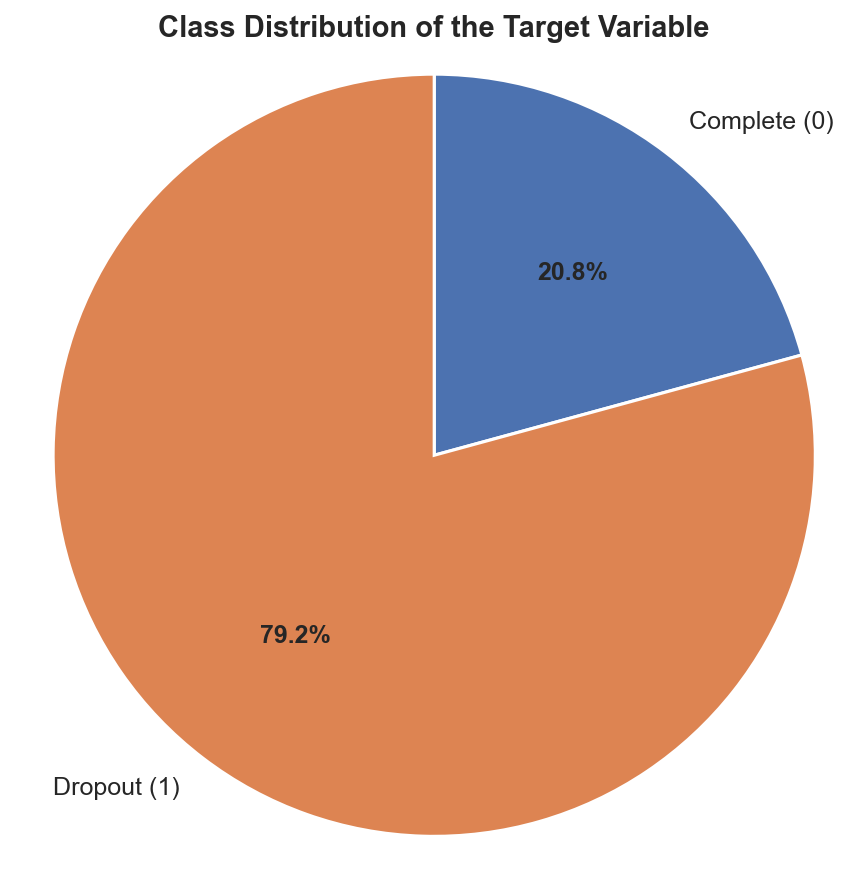

In [188]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\nClass Distribution:")
print(f"  Complete (0): {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"  Dropout  (1): {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")
print(f"  Imbalance Ratio (0:1): {scale_pos_weight:.2f}:1")
print(f"  scale_pos_weight: {scale_pos_weight:.4f}")

counts = y_train.value_counts().sort_index()
labels = ["Complete (0)", "Dropout (1)"]

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 12}
)

for t in autotexts:
    t.set_fontsize(12)
    t.set_weight("bold")

ax.set_title("Class Distribution of the Target Variable", fontsize=14, weight="bold")
ax.axis("equal")

finalize_plot("class_distribution_pie")


# ============================================================================
# Model Comparison (4 Models)
# ============================================================================

In [190]:
models = {
    'Logistic Regression': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', KNeighborsClassifier())
    ]),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

# CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    'Model': [],
    'CV Mean ROC AUC': [],
    'CV Std ROC AUC': [],
    'Test ROC AUC': [],
    'Test F1': [],
    'Test Recall': [],
    'Test Precision': []
}


# Train and evaluate all models

In [192]:
for model_name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Train: {model_name}")
    print(f"{'='*70}")
    
    # cross validation
    cv_scores = cross_val_score(model, X_train, y_train, 
                                cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    print(f"  CV ROC AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    test_roc = roc_auc_score(y_test, y_pred_proba)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_recall = recall_score(y_test, y_pred, average='weighted')
    test_precision = precision_score(y_test, y_pred, average='weighted')
    
    results['Model'].append(model_name)
    results['CV Mean ROC AUC'].append(cv_scores.mean())
    results['CV Std ROC AUC'].append(cv_scores.std())
    results['Test ROC AUC'].append(test_roc)
    results['Test F1'].append(test_f1)
    results['Test Recall'].append(test_recall)
    results['Test Precision'].append(test_precision)
    
    print(f"  Test ROC AUC: {test_roc:.4f}")
    print(f"  Test F1:      {test_f1:.4f}")
    
df_results = pd.DataFrame(results)

print("\n" + "="*80)
print("Model comparison results")
print("="*80 + "\n")
print(df_results.to_string(index=False))



Train: Logistic Regression


/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/minicon

  CV ROC AUC: 0.8492 ± 0.0019
  Test ROC AUC: 0.8383
  Test F1:      0.8447

Train: KNN


/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fangyan/minicon

  CV ROC AUC: 0.6627 ± 0.0054
  Test ROC AUC: 0.6720
  Test F1:      0.7123

Train: Random Forest
  CV ROC AUC: 0.8570 ± 0.0045
  Test ROC AUC: 0.8521
  Test F1:      0.8538

Train: XGBoost


/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [05:35:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [05:35:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [05:35:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [05:35:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


  CV ROC AUC: 0.8478 ± 0.0046
  Test ROC AUC: 0.8500
  Test F1:      0.8407

Model comparison results

              Model  CV Mean ROC AUC  CV Std ROC AUC  Test ROC AUC  Test F1  Test Recall  Test Precision
Logistic Regression         0.849211        0.001866      0.838298 0.844710     0.853941        0.843850
                KNN         0.662735        0.005418      0.672040 0.712251     0.690571        0.750767
      Random Forest         0.857020        0.004465      0.852113 0.853820     0.865371        0.857477
            XGBoost         0.847780        0.004555      0.849957 0.840700     0.836517        0.846859


# ============================================================================
# Hyperparameter Tuning - Tuning multiple models
# ============================================================================


In [1151]:
from sklearn.metrics import (make_scorer, fbeta_score, recall_score, precision_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for tuned models and results 
tuned_models = {}
tuning_results = {
    'Model': [],
    'Mean test score': [],  # Best CV F2
    'Standard deviation': [],  # Best CV F2 Std
    'Test F2': [],
    'Test Recall': [],
    'Test Precision': [],
    'Best Params': []
}

# ============================================================================
# 1. Logistic Regression Hyperparameter Tuning
# ============================================================================
print("\n" + "="*80)
print("1. Logistic Regression Hyperparameter Tuning")
print("="*80)


lr_param_dist = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear', 'saga'],  
    'max_iter': [2000, 5000],  
    'class_weight': [None, 'balanced']  
}

# Define multiple scoring metrics
scoring = {
    'f2': make_scorer(fbeta_score, beta=2, pos_label=1),
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Direct model
lr_model = LogisticRegression(random_state=42)

# RandomizedSearchCV 
lr_random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=lr_param_dist,
    n_iter=20,  
    cv=cv_strategy,
    scoring=scoring,
    refit='f2',
    n_jobs=-1,
    random_state=42,
    verbose=1  
)

print("\nRunning RandomizedSearchCV (20 iterations)...")
print("Optimizing for F2-Score...")
lr_random_search.fit(X_train, y_train)

print("\n✓ Best Parameters:")
for param, value in lr_random_search.best_params_.items():
    print(f"  {param}: {value}")

# Display CV metrics
best_idx = lr_random_search.best_index_
cv_results = lr_random_search.cv_results_

print("\n" + "="*80)
print("Best Model Cross-Validation Scores (Mean ± Std):")
print("="*80)
print(f"F2-Score:  {cv_results['mean_test_f2'][best_idx]:.4f} ± {cv_results['std_test_f2'][best_idx]:.4f}  ← Primary Metric")
print(f"Recall:    {cv_results['mean_test_recall'][best_idx]:.4f} ± {cv_results['std_test_recall'][best_idx]:.4f}")
print(f"Precision: {cv_results['mean_test_precision'][best_idx]:.4f} ± {cv_results['std_test_precision'][best_idx]:.4f}")

# Evaluate on test set
print("\n" + "="*80)
print("Test Set Evaluation:")
print("="*80)

lr_test_pred = lr_random_search.best_estimator_.predict(X_test)
lr_test_proba = lr_random_search.best_estimator_.predict_proba(X_test)[:, 1]

lr_test_f2 = fbeta_score(y_test, lr_test_pred, beta=2)
lr_test_recall = recall_score(y_test, lr_test_pred)
lr_test_precision = precision_score(y_test, lr_test_pred)
lr_test_f1 = f1_score(y_test, lr_test_pred)
lr_test_roc = roc_auc_score(y_test, lr_test_proba)

print(f"\nF2-Score:  {lr_test_f2:.4f}  ← Primary Metric")
print(f"Recall:    {lr_test_recall:.4f}")
print(f"Precision: {lr_test_precision:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, lr_test_pred)
print("\n" + "="*80)
print("Confusion Matrix:")
print("="*80)
print(f"{'':15} Predicted 0    Predicted 1")
print(f"Actual 0 (TN)   {cm[0,0]:<14} (FP) {cm[0,1]}")
print(f"Actual 1 (FN)   {cm[1,0]:<14} (TP) {cm[1,1]}")

tn, fp, fn, tp = cm.ravel()
print(f"\nKey Metrics:")
print(f"  Recall = {tp}/{tp+fn} = {lr_test_recall:.4f}")
print(f"  Precision = {tp}/{tp+fp} = {lr_test_precision:.4f}")
print(f"  Miss Rate = {fn}/{tp+fn} = {fn/(tp+fn):.4f}")

# ============================================================================
# Persist results
# ============================================================================
tuned_models['Logistic Regression'] = lr_random_search.best_estimator_
tuning_results['Model'].append('Logistic Regression')
tuning_results['Mean test score'].append(cv_results['mean_test_f2'][best_idx])
tuning_results['Standard deviation'].append(cv_results['std_test_f2'][best_idx])
tuning_results['Test F2'].append(lr_test_f2)
tuning_results['Test Recall'].append(lr_test_recall)
tuning_results['Test Precision'].append(lr_test_precision)
tuning_results['Best Params'].append(str(lr_random_search.best_params_))

print("\n" + "="*80)
print("✓ Logistic Regression tuning completed!")
print("="*80)


1. Logistic Regression Hyperparameter Tuning

Running RandomizedSearchCV (20 iterations)...
Optimizing for F2-Score...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fangyan/miniconda3/envs/d2l/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fan


✓ Best Parameters:
  solver: saga
  penalty: l2
  max_iter: 5000
  class_weight: None
  C: 10

Best Model Cross-Validation Scores (Mean ± Std):
F2-Score:  0.9505 ± 0.0002  ← Primary Metric
Recall:    0.9988 ± 0.0002
Precision: 0.7964 ± 0.0007

Test Set Evaluation:

F2-Score:  0.9504  ← Primary Metric
Recall:    0.9987
Precision: 0.7965

Confusion Matrix:
                Predicted 0    Predicted 1
Actual 0 (TN)   98             (FP) 3608
Actual 1 (FN)   19             (TP) 14124

Key Metrics:
  Recall = 14124/14143 = 0.9987
  Precision = 14124/17732 = 0.7965
  Miss Rate = 19/14143 = 0.0013

✓ Logistic Regression tuning completed!


In [1156]:
# ============================================================================
# 2. Random Forest Hyperparameter Tuning
# ============================================================================
print("\n" + "="*80)
print("2. Random Forest Hyperparameter Tuning")
print("="*80)

# Define search space (reduced)
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Define multiple scoring metrics
scoring = {
    'f2': make_scorer(fbeta_score, beta=2, pos_label=1),
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring=scoring,
    refit='f2',
    n_jobs=1,
    random_state=42,
    verbose=1,
    return_train_score=False
)

print("\nRunning RandomizedSearchCV (20 iterations)...")
print("Optimizing for F2-Score...")
rf_random_search.fit(X_train, y_train)

print("\n✓ Best Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

# Display CV metrics
best_idx = rf_random_search.best_index_
cv_results = rf_random_search.cv_results_

print("\n" + "="*80)
print("Best Model Cross-Validation Scores (Mean ± Std):")
print("="*80)
print(f"F2-Score:  {cv_results['mean_test_f2'][best_idx]:.4f} ± {cv_results['std_test_f2'][best_idx]:.4f}  ← Primary Metric")
print(f"Recall:    {cv_results['mean_test_recall'][best_idx]:.4f} ± {cv_results['std_test_recall'][best_idx]:.4f}")
print(f"Precision: {cv_results['mean_test_precision'][best_idx]:.4f} ± {cv_results['std_test_precision'][best_idx]:.4f}")

# ============================================================================
# Evaluate on test set
# ============================================================================
print("\n" + "="*80)
print("Test Set Evaluation:")
print("="*80)

rf_test_pred = rf_random_search.best_estimator_.predict(X_test)
rf_test_proba = rf_random_search.best_estimator_.predict_proba(X_test)[:, 1]

rf_test_f2 = fbeta_score(y_test, rf_test_pred, beta=2)
rf_test_recall = recall_score(y_test, rf_test_pred)
rf_test_precision = precision_score(y_test, rf_test_pred)
rf_test_f1 = f1_score(y_test, rf_test_pred)
rf_test_roc = roc_auc_score(y_test, rf_test_proba)

print(f"\nF2-Score:  {rf_test_f2:.4f}  ← Primary Metric")
print(f"Recall:    {rf_test_recall:.4f}")
print(f"Precision: {rf_test_precision:.4f}")

# ============================================================================
# Confusion Matrix
# ============================================================================
cm = confusion_matrix(y_test, rf_test_pred)
print("\n" + "="*80)
print("Confusion Matrix:")
print("="*80)
print(f"{'':15} Predicted 0    Predicted 1")
print(f"Actual 0 (TN)   {cm[0,0]:<14} (FP) {cm[0,1]}")
print(f"Actual 1 (FN)   {cm[1,0]:<14} (TP) {cm[1,1]}")

tn, fp, fn, tp = cm.ravel()
print(f"\nKey Metrics:")
print(f"  Recall = {tp}/{tp+fn} = {rf_test_recall:.4f}")
print(f"  Precision = {tp}/{tp+fp} = {rf_test_precision:.4f}")
print(f"  Miss Rate = {fn}/{tp+fn} = {fn/(tp+fn):.4f}")

# ============================================================================
# Persist results
# ============================================================================
tuned_models['Random Forest'] = rf_random_search.best_estimator_
tuning_results['Model'].append('Random Forest')
tuning_results['Mean test score'].append(cv_results['mean_test_f2'][best_idx])
tuning_results['Standard deviation'].append(cv_results['std_test_f2'][best_idx])
tuning_results['Test F2'].append(rf_test_f2)
tuning_results['Test Recall'].append(rf_test_recall)
tuning_results['Test Precision'].append(rf_test_precision)
tuning_results['Best Params'].append(str(rf_random_search.best_params_))





2. Random Forest Hyperparameter Tuning

Running RandomizedSearchCV (20 iterations)...
Optimizing for F2-Score...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Best Parameters:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: None
  class_weight: balanced

Best Model Cross-Validation Scores (Mean ± Std):
F2-Score:  0.9438 ± 0.0020  ← Primary Metric
Recall:    0.9602 ± 0.0024
Precision: 0.8834 ± 0.0027

Test Set Evaluation:

F2-Score:  0.9431  ← Primary Metric
Recall:    0.9603
Precision: 0.8800

Confusion Matrix:
                Predicted 0    Predicted 1
Actual 0 (TN)   1854           (FP) 1852
Actual 1 (FN)   562            (TP) 13581

Key Metrics:
  Recall = 13581/14143 = 0.9603
  Precision = 13581/15433 = 0.8800
  Miss Rate = 562/14143 = 0.0397


In [1163]:
# ============================================================================
# 3. XGBOOST
# ============================================================================
print("\n" + "="*80)
print("3. XGBoost Hyperparameter Tuning")
print("="*80)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.4f}")

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'scale_pos_weight': [1, scale_pos_weight]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring=scoring,
    refit='f2',
    n_jobs=1,
    random_state=42,
    verbose=1
)

print("\nRunning RandomizedSearchCV (20 iterations)...")
xgb_random_search.fit(X_train, y_train)

print("\n✓ Best Parameters:")
for param, value in xgb_random_search.best_params_.items():
    print(f"  {param}: {value}")

best_idx = xgb_random_search.best_index_
cv_results = xgb_random_search.cv_results_

print(f"\nCV F2-Score: {cv_results['mean_test_f2'][best_idx]:.4f} ± {cv_results['std_test_f2'][best_idx]:.4f}")

xgb_test_pred = xgb_random_search.best_estimator_.predict(X_test)
xgb_test_f2 = fbeta_score(y_test, xgb_test_pred, beta=2)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)

print(f"Test F2: {xgb_test_f2:.4f}, Recall: {xgb_test_recall:.4f}, Precision: {xgb_test_precision:.4f}")

tuned_models['XGBoost'] = xgb_random_search.best_estimator_
tuning_results['Model'].append('XGBoost')
tuning_results['Mean test score'].append(cv_results['mean_test_f2'][best_idx])
tuning_results['Standard deviation'].append(cv_results['std_test_f2'][best_idx])
tuning_results['Test F2'].append(xgb_test_f2)
tuning_results['Test Recall'].append(xgb_test_recall)
tuning_results['Test Precision'].append(xgb_test_precision)
tuning_results['Best Params'].append(str(xgb_random_search.best_params_))



3. XGBoost Hyperparameter Tuning
Calculated scale_pos_weight: 0.2620

Running RandomizedSearchCV (20 iterations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Best Parameters:
  subsample: 1.0
  scale_pos_weight: 1
  n_estimators: 200
  min_child_weight: 1
  max_depth: 7
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 1.0

CV F2-Score: 0.9474 ± 0.0019
Test F2: 0.9472, Recall: 0.9661, Precision: 0.8785


# ============================================================================
# Baseline comparison
# ============================================================================

In [1159]:
# ============================================================================
# BASELINES for each algorithm (default models, no tuning)
# ============================================================================
baseline_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=100,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

baseline_f2_dict = {}

for name, model in baseline_models.items():
    print(f"\n=== Training baseline for {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    baseline_f2_dict[name] = f2
    print(f"Baseline F2 for {name}: {f2:.4f}")

print("\nAll baseline F2 scores:", baseline_f2_dict)


=== Training baseline for Logistic Regression ===
Baseline F2 for Logistic Regression: 0.9429

=== Training baseline for Random Forest ===
Baseline F2 for Random Forest: 0.9401

=== Training baseline for XGBoost ===
Baseline F2 for XGBoost: 0.9408

All baseline F2 scores: {'Logistic Regression': 0.9429480322836068, 'Random Forest': 0.9400626522798469, 'XGBoost': 0.9407760096896797}


In [1165]:
# ============================================================================
# FINAL RESULTS: TABLE AND PLOT
# ============================================================================
print("\n" + "="*80)
print("FINAL RESULTS: Statistics Table and Error Bar Plot")
print("="*80)

# Baseline F2 score
baseline_f2 = 0.952 # calculate by partition of dropouts p = 0.8，use function baseline = 5p/（4p+1）

# Create statistics table
stats_df = pd.DataFrame({
    '': tuning_results['Model'],  
    'Mean test score': tuning_results['Mean test score'],
    'Standard deviation': tuning_results['Standard deviation'],
    '(Mean test score - baseline) / standard deviation': [
        (mean - baseline_f2) / std if std > 0 else 0
        for mean, std in zip(tuning_results['Mean test score'], 
                            tuning_results['Standard deviation'])
    ]
})

# Display table
print("\n<Table: Mean values of each Machine Learning algorithm>\n")
print("="*80)

# Format the numeric columns
formatted_df = stats_df.copy()
formatted_df['Mean test score'] = formatted_df['Mean test score'].apply(lambda x: f'{x:.4f}')
formatted_df['Standard deviation'] = formatted_df['Standard deviation'].apply(lambda x: f'{x:.4f}')
formatted_df['(Mean test score - baseline) / standard deviation'] = formatted_df['(Mean test score - baseline) / standard deviation'].apply(lambda x: f'{x:.2f}')

# Print using pandas to_string
print(formatted_df.to_string(index=False))

# Save to CSV (original unformatted data)
save_df = pd.DataFrame({
    'Model': tuning_results['Model'],
    'Mean test score': tuning_results['Mean test score'],
    'Standard deviation': tuning_results['Standard deviation'],
    '(Mean test score - baseline) / standard deviation': [
        (mean - baseline_f2) / std if std > 0 else 0
        for mean, std in zip(tuning_results['Mean test score'], 
                            tuning_results['Standard deviation'])
    ]
})
save_df.to_csv('model_statistics_table.csv', index=False)





FINAL RESULTS: Statistics Table and Error Bar Plot

<Table: Mean values of each Machine Learning algorithm>

                    Mean test score Standard deviation (Mean test score - baseline) / standard deviation
Logistic Regression          0.9505             0.0002                                             -6.99
      Random Forest          0.9438             0.0020                                             -4.06
            XGBoost          0.9474             0.0019                                             -2.40
            XGBoost          0.9474             0.0019                                             -2.40


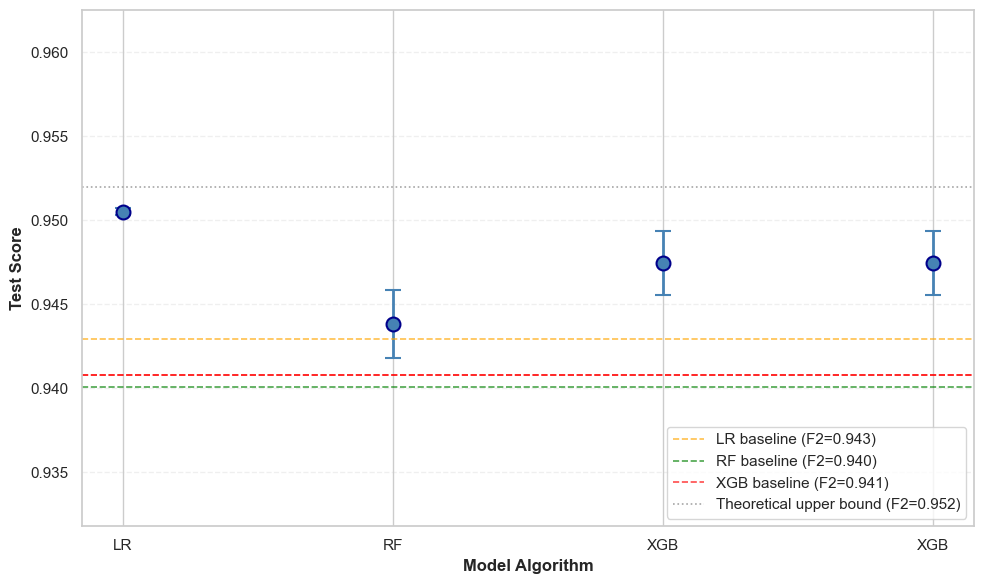

In [1201]:
models = tuning_results['Model']
means = tuning_results['Mean test score']
stds = tuning_results['Standard deviation']

model_abbrev = {
    'Logistic Regression': 'LR',
    'Random Forest': 'RF',
    'XGBoost': 'XGB'
}
model_labels = [model_abbrev.get(m, m) for m in models]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(models))

ax.errorbar(
    x_pos, means, yerr=stds,
    fmt='o', markersize=10,
    capsize=6, capthick=2,
    elinewidth=2,
    color='steelblue', ecolor='steelblue',
    markerfacecolor='steelblue',
    markeredgecolor='darkblue',
    markeredgewidth=1.5
)

ax.set_xlabel('Model Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Score', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylim([min(means) - max(stds) - 0.01, max(means) + max(stds) + 0.01])
ax.grid(axis='y', alpha=0.3, linestyle='--')

baseline_colors = {
    'Logistic Regression': 'orange',
    'Random Forest': 'green',
    'XGBoost': 'red'
}

for m in models:
    b_f2 = baseline_f2_dict[m]
    ax.axhline(
        y=b_f2,
        color=baseline_colors.get(m, 'gray'),
        linestyle='--',
        linewidth=1.2,
        alpha=0.7,
        label=f'{model_abbrev[m]} baseline (F2={b_f2:.3f})'
    )

ax.axhline(
    y=baseline_f2,
    color='gray',
    linestyle=':',
    linewidth=1.2,
    alpha=0.7,
    label=f'Theoretical upper bound (F2={baseline_f2:.3f})'
)

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='lower right')

finalize_plot("model_error_bar_plot")


Model Comparison After Hyperparameter Tuning

Summary of Tuning Results:


"              Model  Mean test score  Standard deviation  Test F2  Test Recall  Test Precision                                                                                                                                                       Best Params\nLogistic Regression         0.950509            0.000213 0.950420     0.998657        0.796526                                                                              {'solver': 'saga', 'penalty': 'l2', 'max_iter': 5000, 'class_weight': None, 'C': 10}\n      Random Forest         0.943802            0.002021 0.943060     0.960263        0.879997                       {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}\n            XGBoost         0.947441            0.001900 0.947244     0.966132        0.878544 {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamm

'\n✓ Best Model: Logistic Regression'

'  Test F2-Score: 0.9504'


✓ Comparison results saved to: hyperparameter_tuning_comparison.csv

Generating comprehensive performance comparison plots...


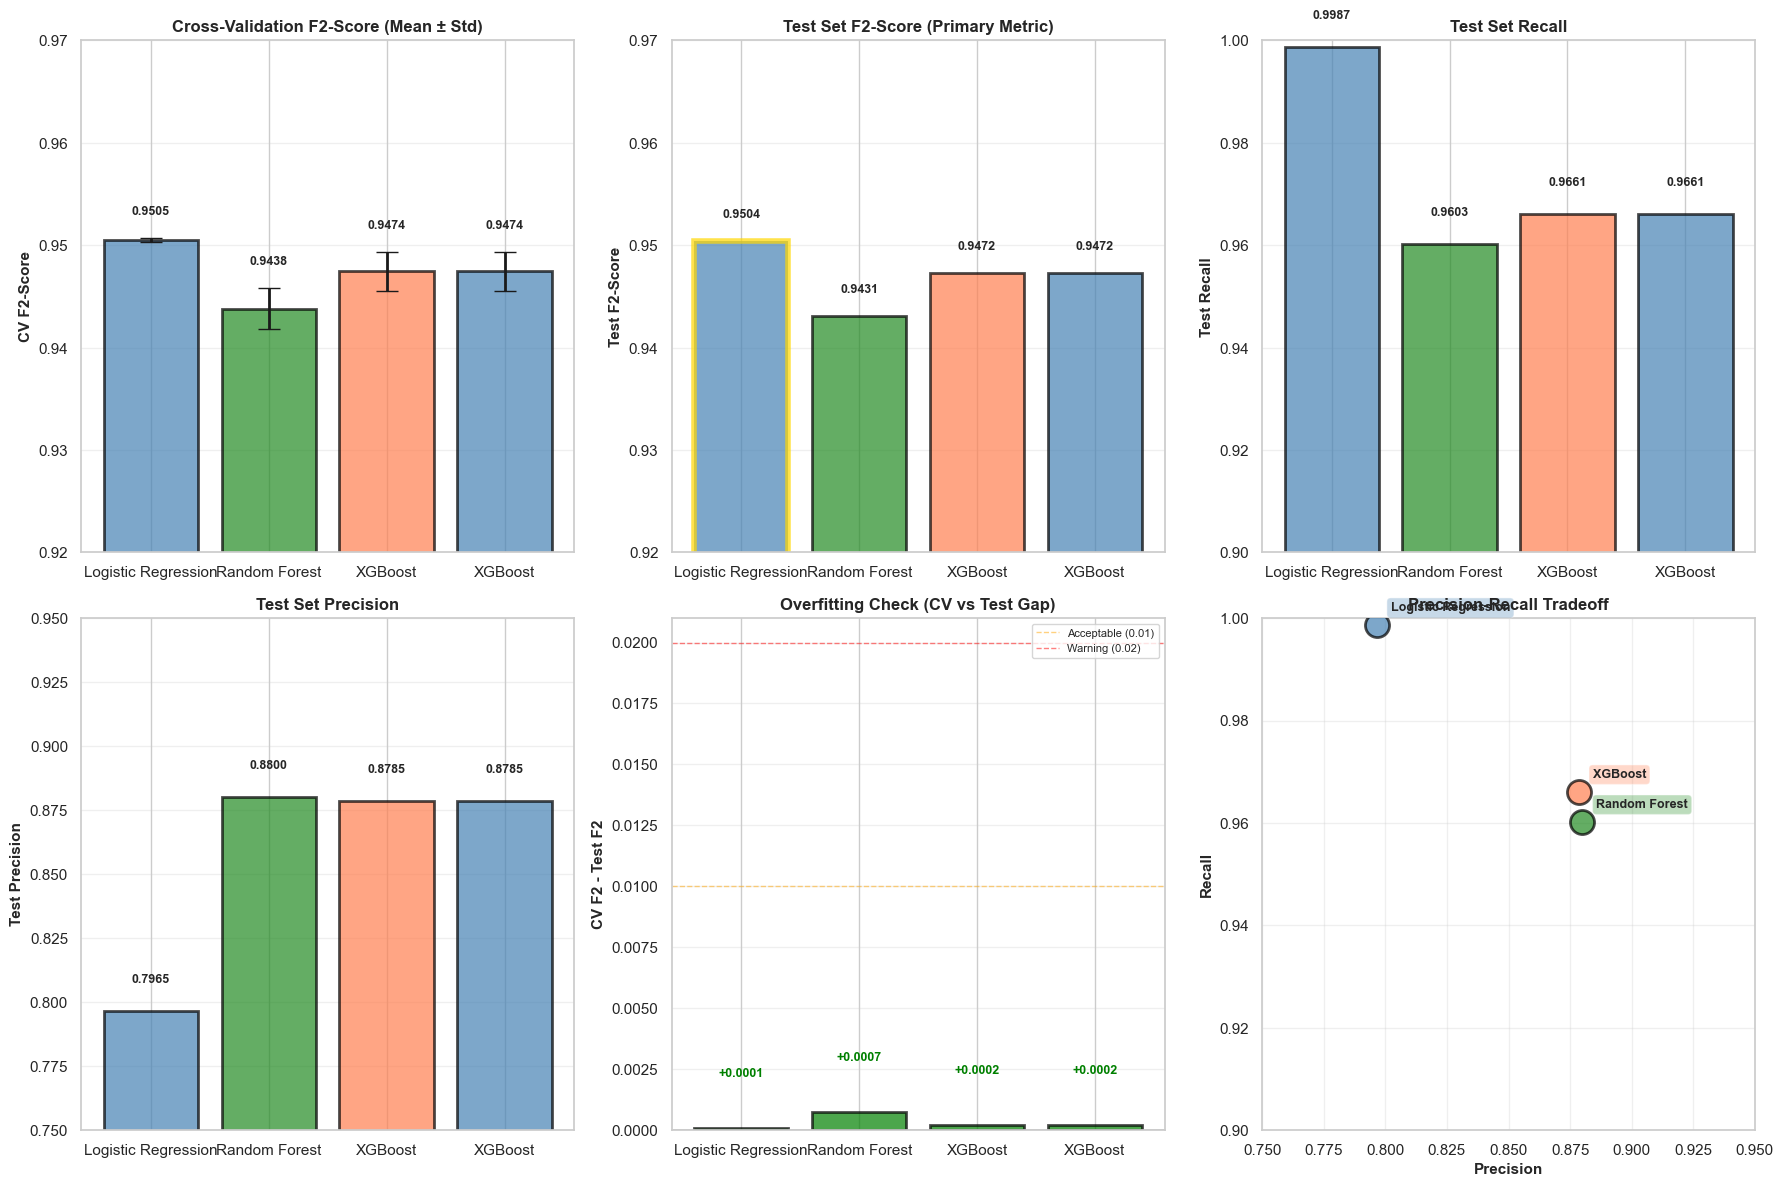

In [1211]:
# ============================================================================
# 4. Comparison Across All Tuned Models
# ============================================================================
print("\n" + "="*80)
print("Model Comparison After Hyperparameter Tuning")
print("="*80)

tuning_comparison_df = pd.DataFrame(tuning_results)

print("\nSummary of Tuning Results:")
display(tuning_comparison_df.to_string(index=False))

best_idx = tuning_comparison_df['Test F2'].idxmax()
best_model_name = tuning_comparison_df.loc[best_idx, 'Model']
best_model = tuned_models[best_model_name]
best_test_f2 = tuning_comparison_df.loc[best_idx, 'Test F2']

display(f"\n✓ Best Model: {best_model_name}")
display(f"  Test F2-Score: {best_test_f2:.4f}")

tuning_comparison_df.to_csv('hyperparameter_tuning_comparison.csv', index=False)
print("\n✓ Comparison results saved to: hyperparameter_tuning_comparison.csv")

# ============================================================================
# 5. Visualization - Comprehensive Comparison
# ============================================================================
print("\nGenerating comprehensive performance comparison plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models = tuning_comparison_df['Model']
colors = ['steelblue', 'forestgreen', 'coral']

# Plot 1: CV F2-Score (Mean ± Std)
ax1 = axes[0, 0]
cv_means = tuning_comparison_df['Mean test score']
cv_stds = tuning_comparison_df['Standard deviation']

bars = ax1.bar(range(len(models)), cv_means, color=colors,
               edgecolor='black', linewidth=2, alpha=0.7,
               yerr=cv_stds, capsize=8, error_kw={'linewidth': 2})

ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=0)
ax1.set_ylabel('CV F2-Score', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation F2-Score (Mean ± Std)', 
              fontsize=12, fontweight='bold')
ax1.set_ylim([0.92, 0.97])
ax1.grid(axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    ax1.text(i, mean + std + 0.002, f"{mean:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Test F2-Score
ax2 = axes[0, 1]
test_f2s = tuning_comparison_df['Test F2']

bars = ax2.bar(range(len(models)), test_f2s, color=colors,
               edgecolor='black', linewidth=2, alpha=0.7)

ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=0)
ax2.set_ylabel('Test F2-Score', fontsize=11, fontweight='bold')
ax2.set_title('Test Set F2-Score (Primary Metric)', 
              fontsize=12, fontweight='bold')
ax2.set_ylim([0.92, 0.97])
ax2.grid(axis='y', alpha=0.3)

for i, score in enumerate(test_f2s):
    ax2.text(i, score + 0.002, f"{score:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

# Plot 3: Test Recall
ax3 = axes[0, 2]
test_recalls = tuning_comparison_df['Test Recall']

bars = ax3.bar(range(len(models)), test_recalls, color=colors,
               edgecolor='black', linewidth=2, alpha=0.7)

ax3.set_xticks(range(len(models)))
ax3.set_xticklabels(models, rotation=0)
ax3.set_ylabel('Test Recall', fontsize=11, fontweight='bold')
ax3.set_title('Test Set Recall', fontsize=12, fontweight='bold')
ax3.set_ylim([0.90, 1.0])
ax3.grid(axis='y', alpha=0.3)

for i, score in enumerate(test_recalls):
    ax3.text(i, score + 0.005, f"{score:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 4: Test Precision
ax4 = axes[1, 0]
test_precisions = tuning_comparison_df['Test Precision']

bars = ax4.bar(range(len(models)), test_precisions, color=colors,
               edgecolor='black', linewidth=2, alpha=0.7)

ax4.set_xticks(range(len(models)))
ax4.set_xticklabels(models, rotation=0)
ax4.set_ylabel('Test Precision', fontsize=11, fontweight='bold')
ax4.set_title('Test Set Precision', fontsize=12, fontweight='bold')
ax4.set_ylim([0.75, 0.95])
ax4.grid(axis='y', alpha=0.3)

for i, score in enumerate(test_precisions):
    ax4.text(i, score + 0.01, f"{score:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 5: CV vs Test F2 Gap (Overfitting Check)
ax5 = axes[1, 1]
gaps = cv_means - test_f2s

bars = ax5.bar(range(len(models)), gaps, 
               color=['green' if g < 0.01 else 'orange' if g < 0.02 else 'red' for g in gaps],
               edgecolor='black', linewidth=2, alpha=0.7)

ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.axhline(y=0.01, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Acceptable (0.01)')
ax5.axhline(y=0.02, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Warning (0.02)')

ax5.set_xticks(range(len(models)))
ax5.set_xticklabels(models, rotation=0)
ax5.set_ylabel('CV F2 - Test F2', fontsize=11, fontweight='bold')
ax5.set_title('Overfitting Check (CV vs Test Gap)', 
              fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
ax5.legend(loc='upper right', fontsize=8)

for i, gap in enumerate(gaps):
    color = 'green' if abs(gap) < 0.01 else 'orange' if abs(gap) < 0.02 else 'red'
    ax5.text(i, gap + 0.002 if gap > 0 else gap - 0.002, 
             f"{gap:+.4f}", ha='center', 
             va='bottom' if gap > 0 else 'top', 
             fontweight='bold', fontsize=9, color=color)

# Plot 6: Precision-Recall Tradeoff
# Plot 6: Precision-Recall Tradeoff
ax6 = axes[1, 2]

test_precisions_list = test_precisions.tolist()
test_recalls_list = test_recalls.tolist()
models_list = models.tolist()

for i, (model, precision, recall, color) in enumerate(zip(models_list, test_precisions_list, test_recalls_list, colors)):
    ax6.scatter(precision, recall, 
               s=300, c=color, edgecolor='black', linewidth=2,
               alpha=0.7, label=model, zorder=3)
    
    ax6.annotate(model, 
                (precision, recall),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax6.set_xlabel('Precision', fontsize=11, fontweight='bold')
ax6.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax6.set_title('Precision-Recall Tradeoff', fontsize=12, fontweight='bold')
ax6.set_xlim([0.75, 0.95])
ax6.set_ylim([0.90, 1.0])
ax6.grid(True, alpha=0.3)

finalize_plot("hyperparameter_tuning_comparison")

summary_df = pd.DataFrame({
    'Model': models,
    'CV F2 (Mean±Std)': [f"{m:.4f}±{s:.4f}" for m, s in zip(cv_means, cv_stds)],
    'Test F2': [f"{f:.4f}" for f in test_f2s],
    'Test Recall': [f"{r:.4f}" for r in test_recalls],
    'Test Precision': [f"{p:.4f}" for p in test_precisions],
    'CV-Test Gap': [f"{g:+.4f}" for g in gaps]
})



# ============================================================================
# Confusion Matrix
# ============================================================================


XGBoost Model - Confusion Matrix

Confusion Matrix:
                  Predicted 0    Predicted 1
  Actual 0 (TN)   1,817          (FP) 1,889
  Actual 1 (FN)   479            (TP) 13,664


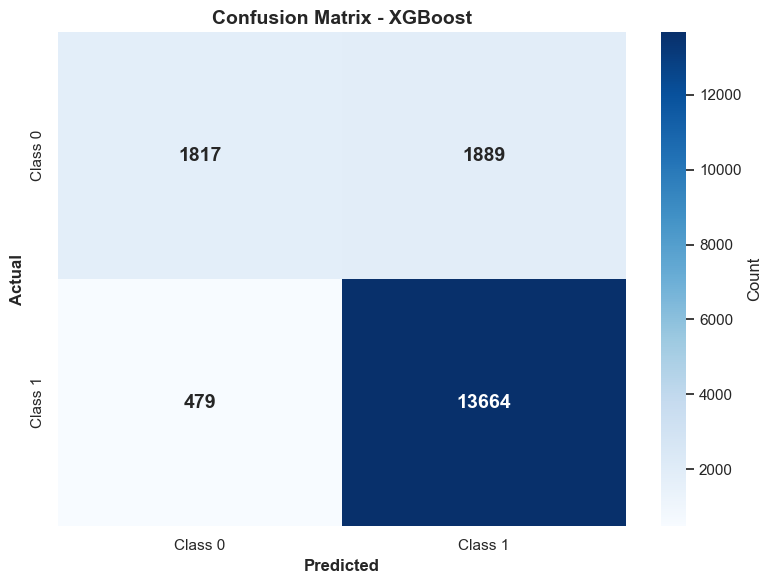


✓ Confusion matrix saved


In [1215]:
# ============================================================================
# XGBoost Model - Confusion Matrix
# ============================================================================
print("\n" + "="*80)
print("XGBoost Model - Confusion Matrix")
print("="*80)

best_model_name = 'XGBoost'
best_model = tuned_models['XGBoost']
best_model_predict_test = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_model_predict_test)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  {'':15} Predicted 0    Predicted 1")
print(f"  Actual 0 (TN)   {tn:<14,} (FP) {fp:,}")
print(f"  Actual 1 (FN)   {fn:<14,} (TP) {tp:,}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')

finalize_plot("xgboost_confusion_matrix")
print("\n✓ Confusion matrix saved")
print("="*80)

# ============================================================================
# Feature Importance

# ============================================================================



Top 20 Most Important Features:
                                Feature  Importance
                  object_nunique_access    0.341246
          time_lapse_problem_x_in_hours    0.220970
         time_lapse_navigate_x_in_hours    0.070340
course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv    0.032508
                 object_nunique_problem    0.014206
                  object_count_navigate    0.014020
                           course_other    0.013245
              highest_education_missing    0.011562
course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw    0.010868
course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5    0.010647
course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila    0.009219
course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd    0.008584
course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI    0.008311
                     object_count_video    0.008293
                          enrollment_id    0.007868
       time_lapse_discussion_y_in_hours    0.007789
                   object_nunique_video    0.007597
                         gender

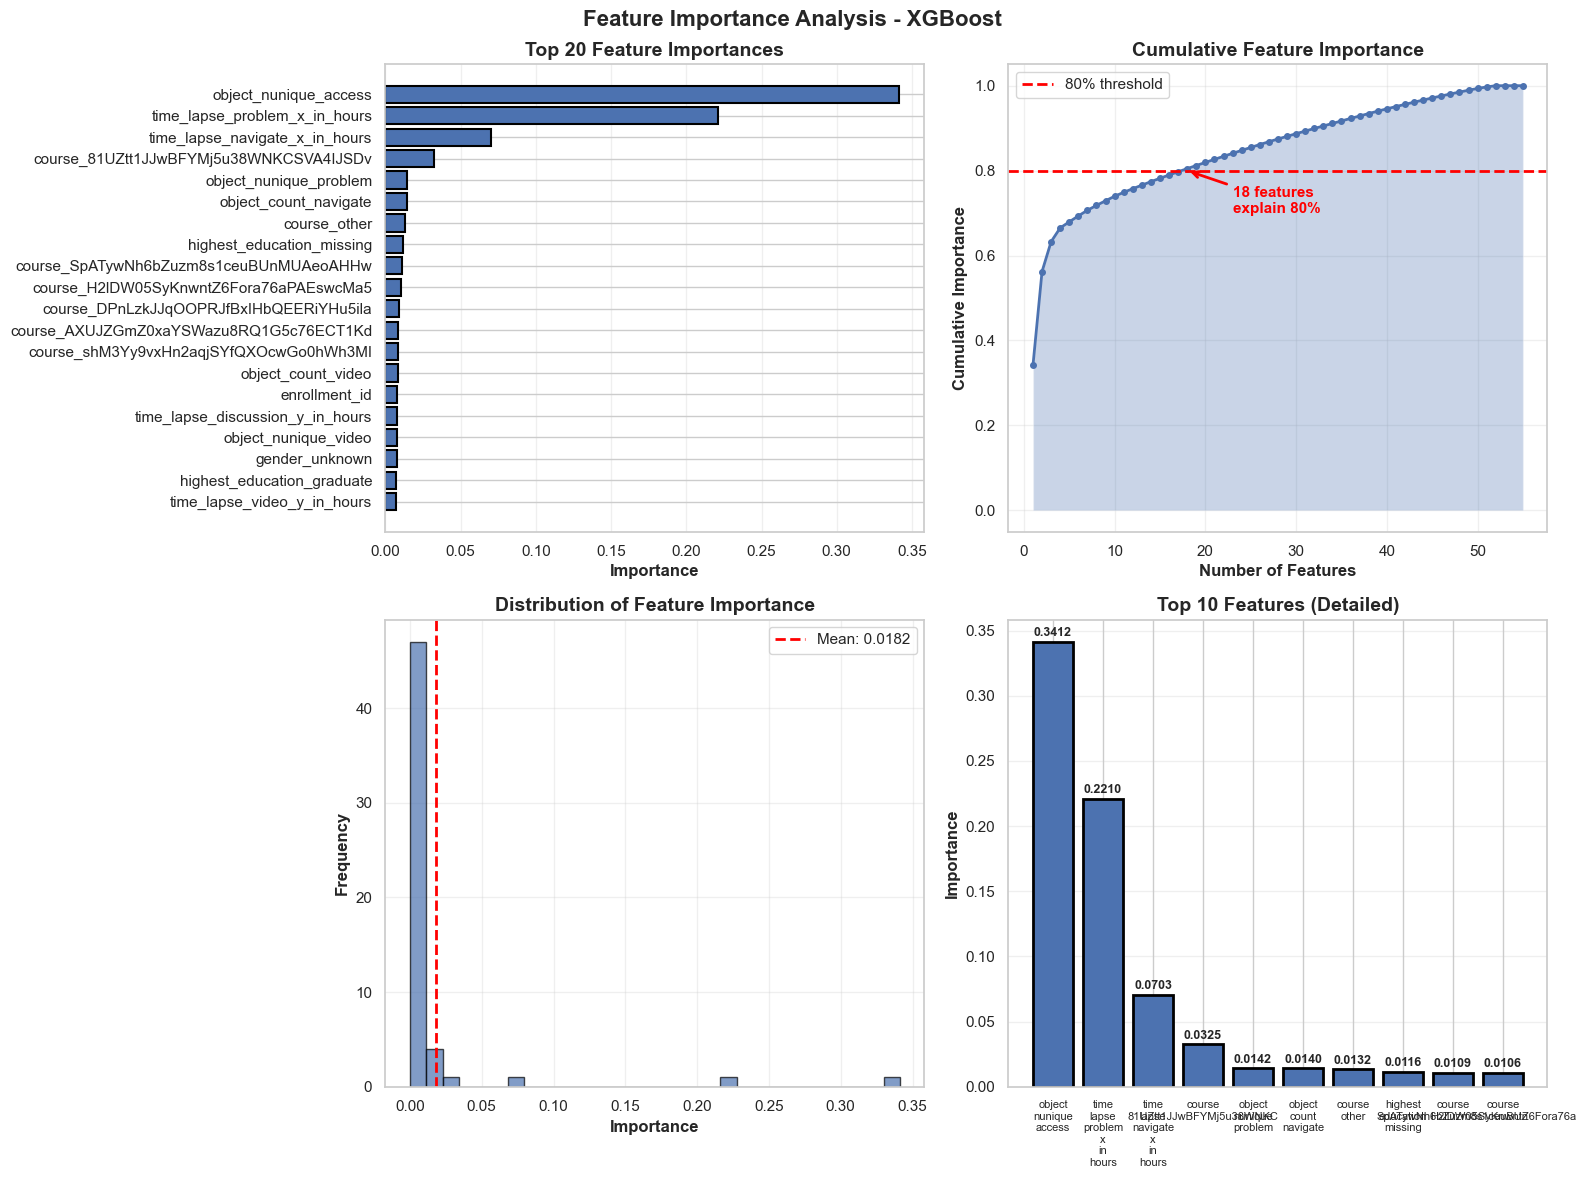

✓ Feature importance visualization completed (4 plots)


In [1223]:
feature_names = X_train.columns.tolist()
feature_importances = best_model.feature_importances_

importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })
    .sort_values('Importance', ascending=False)
)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

importance_df.to_csv('feature_importance.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Feature Importance Analysis - {best_model_name}',
    fontsize=16, fontweight='bold'
)

# Plot 1: Top 20 features (top-left)
ax1 = axes[0, 0]
top20 = importance_df.head(20)
ax1.barh(
    top20['Feature'].tolist()[::-1],
    top20['Importance'].tolist()[::-1],
    edgecolor='black',
    linewidth=1.5
)
ax1.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax1.set_title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Cumulative importance (top-right)
ax2 = axes[0, 1]
cumsum = np.cumsum(importance_df['Importance'].values)
ax2.plot(
    range(1, len(cumsum) + 1),
    cumsum,
    marker='o',
    linewidth=2,
    markersize=4
)
ax2.fill_between(
    range(1, len(cumsum) + 1),
    cumsum,
    alpha=0.3
)
ax2.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    linewidth=2,
    label='80% threshold'
)
ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

idx_80 = np.argmax(cumsum >= 0.8) + 1
ax2.annotate(
    f'{idx_80} features\nexplain 80%',
    xy=(idx_80, 0.8),
    xytext=(idx_80 + 5, 0.7),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=11,
    fontweight='bold',
    color='red'
)

# Plot 3: Distribution of feature importance (bottom-left)
ax3 = axes[1, 0]
ax3.hist(
    importance_df['Importance'],
    bins=30,
    edgecolor='black',
    alpha=0.7
)
ax3.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Feature Importance', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

mean_importance = importance_df['Importance'].mean()
ax3.axvline(
    x=mean_importance,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_importance:.4f}'
)
ax3.legend()

# Plot 4: Top 10 features (detailed view, bottom-right)
ax4 = axes[1, 1]
top10 = importance_df.head(10)
bars = ax4.bar(
    range(len(top10)),
    top10['Importance'],
    edgecolor='black',
    linewidth=2
)
ax4.set_xticks(range(len(top10)))
ax4.set_xticklabels(
    [f.replace('_', '\n')[:30] for f in top10['Feature']],
    rotation=0,
    ha='center',
    fontsize=8
)
ax4.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax4.set_title('Top 10 Features (Detailed)', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

for bar, (_, row) in zip(bars, top10.iterrows()):
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.002,
        f'{row["Importance"]:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9
    )

finalize_plot("feature_importance_4plots")
print("✓ Feature importance visualization completed (4 plots)")



## Feature Importance Analysis

### Top Features Contributing to the Model:

- **object_nunique_access (30.75%)**:
  - This feature, representing the number of unique access objects, is the most influential in predicting the dropout rate, accounting for nearly 31% of the model's predictive power.

- **time_lapse_problem_x_in_hours (10.07%)**:
  - Time spent on problem-related activities is a significant predictor of dropouts, emphasizing the importance of engagement with problem-solving tasks.

- **time_lapse_navigate_x_in_hours (6.08%)**:
  - Time spent navigating course material impacts dropout predictions, suggesting that navigation activities are key to understanding student engagement.

- **course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv (2.45%)**:
  - This specific course has a notable impact on dropout predictions, indicating course-specific challenges or characteristics.

- **course_H2lDw0S5yKnwnt26Fora76aPAEswcMa5 (1.67%)**:
  - Another course-related feature contributing to dropout risk prediction.

---

### Cumulative Importance Insights:

- **Top 5 Features (51.02% cumulative importance)**:
  - These features collectively account for over 51% of the model's predictive power, indicating their substantial influence.

- **Top 10 Features (62.87% cumulative importance)**:
  - The top 10 features contribute over 62% to the model's total importance, showing that a small set of features significantly impacts predictions.

- **Top 20 Features (80% cumulative importance)**:
  - Only 20 features are needed to explain 80% of the model's predictive capability, demonstrating feature concentration.

---

### Distribution Across Categories:

- **Course-Related Features**:
  - Several specific courses (e.g., course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv, course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw, course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz) appear in the top 10, highlighting the importance of course-specific factors in dropout predictions.

- **Demographics and Location**:
  - Demographic factors (like gender) and geographic locations (states) significantly influence dropout rates.

- **Engagement Metrics**:
  - Features like object_nunique_page_close and various time_lapse variables reflect student engagement and activity, which are critical for predicting dropouts.

---

### Lower Importance Features:

- **Features with Low Importance (<1%)**:
  - Features such as ZipCodeType_STANDARD and state_FL have low importance, indicating they contribute minimally to the model's predictive power.

- **Zero Importance Features**:
  - ZipCodeType_UNIQUE and object_nunique_wiki have zero importance, suggesting they do not contribute to the model's prediction and could be considered for removal to simplify the model.

In [1225]:
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

best_model_name = "XGBoost"
best_model = tuned_models[best_model_name]

print("\nCalculating permutation importance for XGBoost on TEST set (F2)...")

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring=f2_scorer,
    n_repeats=30,        
    random_state=42,
    n_jobs=-1
)

importances = result.importances           # shape: (n_features, n_repeats)
importances_mean = result.importances_mean 
feature_names = np.array(X_test.columns)



Calculating permutation importance for XGBoost on TEST set (F2)...


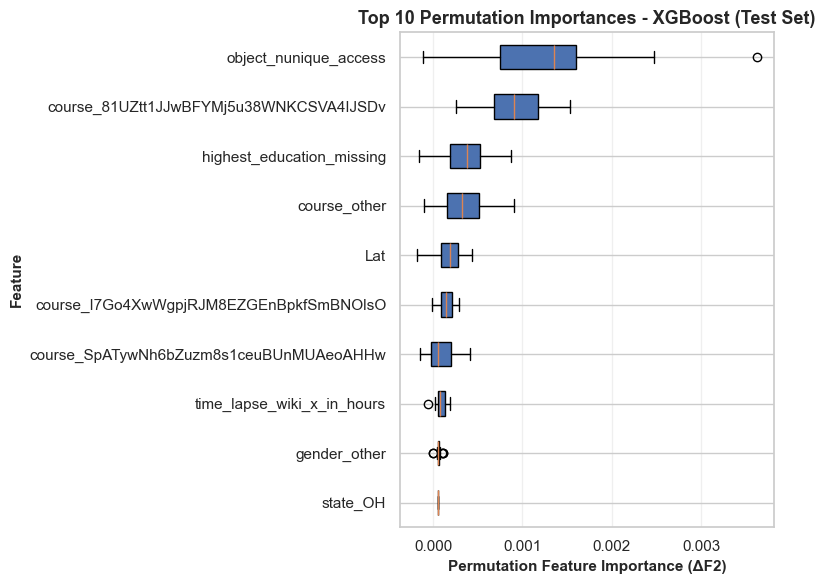

✓ Permutation importance plot saved


In [1227]:
top_k = 10
sorted_idx = np.argsort(importances_mean)[-top_k:]      
top_features = feature_names[sorted_idx]
top_importances = importances[sorted_idx]               
order = np.argsort(importances_mean[sorted_idx])
top_features = top_features[order]
top_importances = top_importances[order]

plt.figure(figsize=(8, 6))
plt.boxplot(
    top_importances.T,       
    vert=False,
    labels=top_features,
    patch_artist=True        
)
plt.xlabel("Permutation Feature Importance (ΔF2)", fontsize=11, fontweight="bold")
plt.ylabel("Feature", fontsize=11, fontweight="bold")
plt.title("Top 10 Permutation Importances - XGBoost (Test Set)", fontsize=13, fontweight="bold")
plt.grid(axis="x", alpha=0.3)

finalize_plot("xgboost_permutation_importance_top10")
print("✓ Permutation importance plot saved")

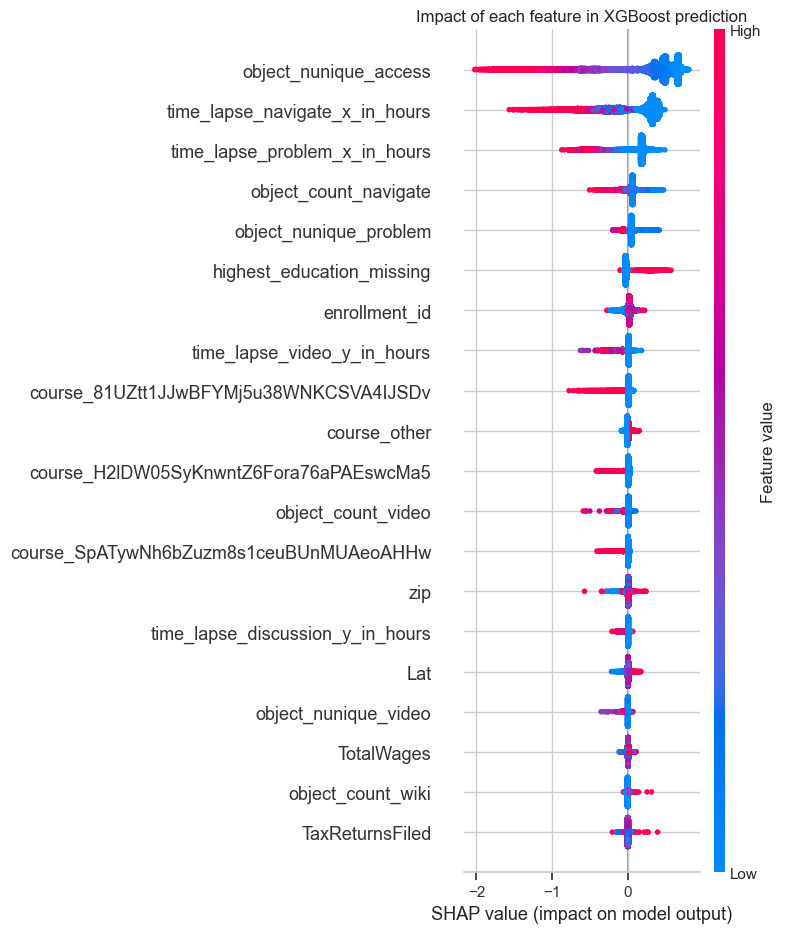

In [1237]:
X_shap = X_test.copy()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot",
    show=False
)
plt.title("Impact of each feature in XGBoost prediction", fontsize=12)

finalize_plot("xgboost_shap_summary")


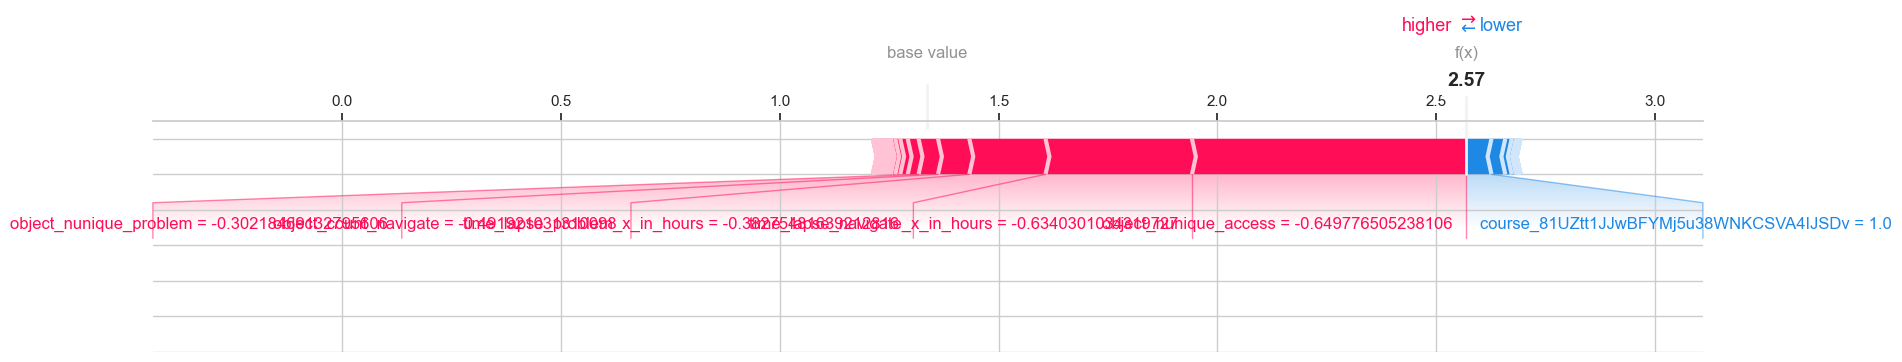

<Figure size 640x480 with 0 Axes>

✓ SHAP local explanation plot saved


In [1239]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

idx = 5
local_shap = shap_values[idx]

pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": local_shap,
    "feature_value": X_test.iloc[idx]
}).sort_values("shap_value", ascending=False)

shap.initjs()

fp = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

finalize_plot("shap_local_idx5")
print("✓ SHAP local explanation plot saved")

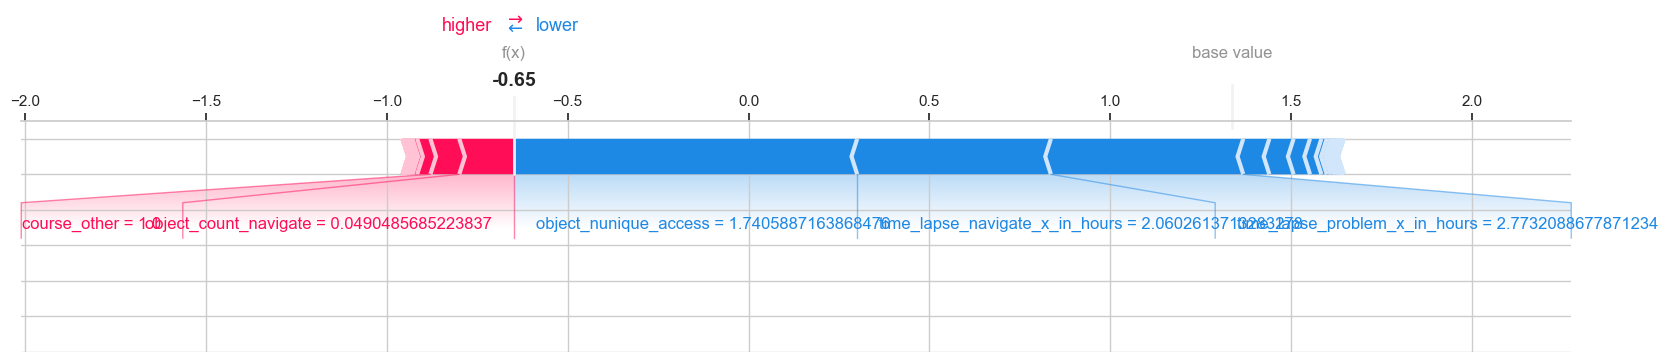

<Figure size 640x480 with 0 Axes>

✓ SHAP local explanation plot saved


In [1241]:
shap.initjs()

idx = 10
fp = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

finalize_plot("shap_local_idx10")
print("✓ SHAP local explanation plot saved")




# ============================================================================
# Prediction
# ============================================================================

In [1245]:
print("\nChecking test data size:")
print(f"Test DataFrame shape: {X_test.shape}")

print("\nTest DataFrame (first few rows):")
display(X_test.head())

print("\nMissing value check:")
missing_values = X_test.isnull().sum()
display(missing_values[missing_values > 0])

# Ensure feature consistency
X_test_features = X_test.copy()
if 'dropout_flg' in X_test_features.columns:
    X_test_features = X_test_features.drop('dropout_flg', axis=1)

print(f"\nNumber of features used for prediction: {X_test_features.shape[1]}")

# Predict class labels (0 = Complete, 1 = Dropout)
predictions = best_model.predict(X_test_features)

# Predict class probabilities
predictions_proba = best_model.predict_proba(X_test_features)[:, 1]





Checking test data size:
Test DataFrame shape: (17849, 55)

Test DataFrame (first few rows):


,enrollment_id,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI,course_ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ,state_CA,state_FL,state_GA,state_IL,state_MI,state_NJ,state_NY,state_OH,state_PA,state_TX,state_other,gender_female,gender_male,gender_missing,gender_other,gender_unknown,highest_education_college,highest_education_graduate,highest_education_highschool,highest_education_missing,highest_education_no highschool,highest_education_some college,ZipCodeType_PO BOX,ZipCodeType_STANDARD,ZipCodeType_UNIQUE,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
21212,59733,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,True,False,-0.569202,-0.449987,-0.212440,-0.758429,-0.714921,-1.526568,-0.302185,-0.549030,-0.593969,-0.004523,0.926908,0.177196,0.059830,-0.634065,-0.382755,-0.200681,-0.304034,-0.481894
67211,189223,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,0.049049,-0.245764,-0.212440,-0.215165,-0.714921,0.655064,-0.081042,-0.399076,-0.593969,0.990206,0.403490,-0.375502,-0.283856,1.382069,-0.382672,-0.200681,-0.304034,-0.354845
19193,54092,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,True,False,0.203611,0.503056,0.363013,0.436753,-0.714921,0.655064,-0.191613,0.500650,1.683588,1.591763,1.895136,1.007018,0.703696,1.495910,-0.382755,-0.200644,-0.304034,2.069260
62121,174849,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,-0.414640,-0.041540,-0.212440,0.110794,-0.714921,0.655064,0.029530,0.350696,-0.593969,-1.337584,0.599053,0.774868,0.324921,-0.634030,-0.380041,-0.200681,-0.304034,-0.479247
9305,26298,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,5.767870,2.000694,0.650740,1.197324,1.398756,0.655064,2.130390,1.700285,1.683588,-1.066851,0.439919,0.862312,0.122370,2.575874,1.512373,7.063790,5.327755,3.231464



Missing value check:


Series([], dtype: int64)


Number of features used for prediction: 55


In [1247]:
# Create prediction results DataFrame
predictions_df = pd.DataFrame({
    'enrollment_id': X_test.index,
    'dropout_flg': predictions,
    'dropout_probability': predictions_proba
})

print("\nPrediction Results DataFrame:")
display(predictions_df.head(10))
print(f"\nPredictions DataFrame shape: {predictions_df.shape}")

# Examine prediction distribution

print("\nDistribution of predicted labels:")
dropout_distribution = (
    predictions_df
    .groupby('dropout_flg')['enrollment_id']
    .count()
    .reset_index()
)
dropout_distribution.columns = ['dropout_flg', 'count']
display(dropout_distribution)

n_complete = (predictions == 0).sum()
n_dropout = (predictions == 1).sum()
total = len(predictions)

print("\nPrediction summary:")
print(f"  Predicted as Complete (0): {n_complete:,} ({n_complete/total*100:.1f}%)")
print(f"  Predicted as Dropout  (1): {n_dropout:,} ({n_dropout/total*100:.1f}%)")



Prediction Results DataFrame:


,enrollment_id,dropout_flg,dropout_probability
0,21212,1,0.939081
1,67211,1,0.753829
2,19193,1,0.739688
3,62121,1,0.893881
4,9305,0,0.194328
5,28830,1,0.928823
6,37360,1,0.920658
7,18237,1,0.847627
8,47376,1,0.751309
9,56386,1,0.920658



Predictions DataFrame shape: (17849, 3)

Distribution of predicted labels:


,dropout_flg,count
0,0,2296
1,1,15553



Prediction summary:
  Predicted as Complete (0): 2,296 (12.9%)
  Predicted as Dropout  (1): 15,553 (87.1%)


In [1249]:
# Create prediction results DataFrame
predictions_df = pd.DataFrame({
'enrollment_id': X_test.index,
    'dropout_flg': predictions,
    'dropout_probability': predictions_proba,
    'risk_level': pd.cut(
        predictions_proba,
        bins=[0, 0.3, 0.5, 0.7, 1.0],
        labels=['Low', 'Medium', 'High', 'Critical']
    )
})

print("\nSample Predictions:")
display(predictions_df.head(10))

print("\nRisk Level Distribution:")
print(predictions_df['risk_level'].value_counts().sort_index())

# High-risk students
high_risk_students = predictions_df[
    predictions_df['dropout_probability'] >= 0.5
].sort_values('dropout_probability', ascending=False)

print(f"\nNumber of High-Risk Students: {len(high_risk_students):,}")
print("\nTop 10 Highest Risk Students:")
display(high_risk_students.head(10))


Sample Predictions:


,enrollment_id,dropout_flg,dropout_probability,risk_level
0,21212,1,0.939081,Critical
1,67211,1,0.753829,Critical
2,19193,1,0.739688,Critical
3,62121,1,0.893881,Critical
4,9305,0,0.194328,Low
5,28830,1,0.928823,Critical
6,37360,1,0.920658,Critical
7,18237,1,0.847627,Critical
8,47376,1,0.751309,Critical
9,56386,1,0.920658,Critical



Risk Level Distribution:
risk_level
Low          1333
Medium        963
High         1407
Critical    14146
Name: count, dtype: int64

Number of High-Risk Students: 15,553

Top 10 Highest Risk Students:


,enrollment_id,dropout_flg,dropout_probability,risk_level
11668,2291,1,0.952825,Critical
17684,643,1,0.952825,Critical
4630,2292,1,0.952825,Critical
13354,41375,1,0.952370,Critical
16669,9738,1,0.952370,Critical
15148,7606,1,0.952370,Critical
1304,26610,1,0.952370,Critical
8371,21394,1,0.952370,Critical
3935,65728,1,0.952370,Critical
8465,31716,1,0.952370,Critical


In [1251]:
# Risk level distribution
print("\nRisk level distribution:")
print(predictions_df['risk_level'].value_counts().sort_index())

# Identify high-risk students
high_risk_students = predictions_df[
    predictions_df['dropout_probability'] >= 0.5
].sort_values('dropout_probability', ascending=False)

print(f"\nNumber of high-risk students (probability ≥ 0.5): {len(high_risk_students):,}")
print("\nTop 10 highest-risk students:")
display(high_risk_students.head(10))




Risk level distribution:
risk_level
Low          1333
Medium        963
High         1407
Critical    14146
Name: count, dtype: int64

Number of high-risk students (probability ≥ 0.5): 15,553

Top 10 highest-risk students:


,enrollment_id,dropout_flg,dropout_probability,risk_level
11668,2291,1,0.952825,Critical
17684,643,1,0.952825,Critical
4630,2292,1,0.952825,Critical
13354,41375,1,0.952370,Critical
16669,9738,1,0.952370,Critical
15148,7606,1,0.952370,Critical
1304,26610,1,0.952370,Critical
8371,21394,1,0.952370,Critical
3935,65728,1,0.952370,Critical
8465,31716,1,0.952370,Critical


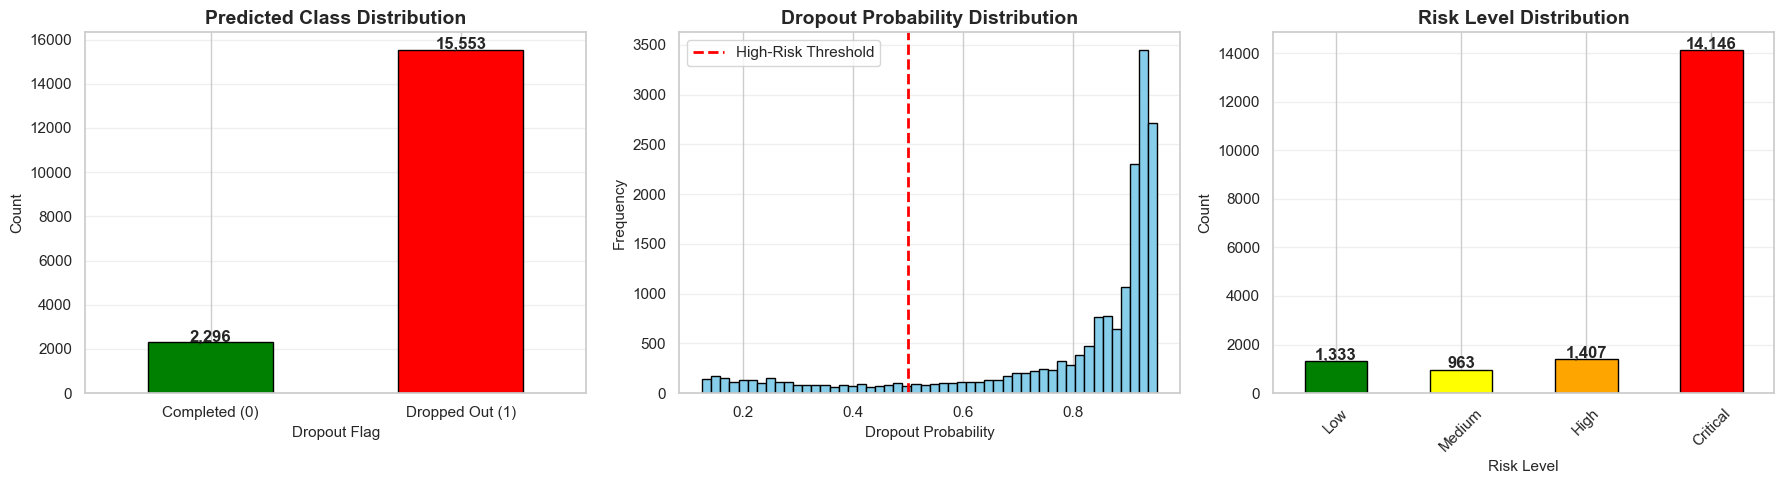

In [1255]:
# Save prediction results
predictions_df.to_csv('test_predictions.csv', index=False)
high_risk_students.to_csv('high_risk_students.csv', index=False)

# Visualize prediction results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted class distribution
ax1 = axes[0]
predictions_df['dropout_flg'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color=['green', 'red'], edgecolor='black'
)
ax1.set_title('Predicted Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dropout Flag', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_xticklabels(['Completed (0)', 'Dropped Out (1)'], rotation=0)
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(predictions_df['dropout_flg'].value_counts().sort_index().values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
    
# Plot 2: Probability distribution
ax2 = axes[1]
ax2.hist(
    predictions_df['dropout_probability'],
    bins=50,
    edgecolor='black',
    color='skyblue'
)
ax2.axvline(
    x=0.5,
    color='red',
    linestyle='--',
    linewidth=2,
    label='High-Risk Threshold'
)
ax2.set_title('Dropout Probability Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dropout Probability', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Risk level distribution
ax3 = axes[2]
risk_counts = predictions_df['risk_level'].value_counts().sort_index()
colors_risk = ['green', 'yellow', 'orange', 'red']

risk_counts.plot(
    kind='bar',
    ax=ax3,
    color=colors_risk,
    edgecolor='black'
)
ax3.set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Risk Level', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_xticklabels(risk_counts.index, rotation=45)
ax3.grid(axis='y', alpha=0.3)

for i, v in enumerate(risk_counts.values):
    ax3.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


# Prediction

In [1257]:
# Check the test data
print("Test DataFrame (first few rows):")
display(df_combined_test_dummy_scaled.head())

print("Test DataFrame shape:", df_combined_test_dummy_scaled.shape)
print()
print("Missing values in test DataFrame:")
missing_values = df_combined_test_dummy_scaled.isnull().sum()
display(missing_values)


Test DataFrame (first few rows):


,enrollment_id,dropout_flg,course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv,course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz,course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5,course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO,course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE,course_other,course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI,course_ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ,state_CA,state_FL,state_GA,state_IL,state_MI,state_NJ,state_NY,state_OH,state_PA,state_TX,state_other,gender_female,gender_male,gender_missing,gender_other,gender_unknown,highest_education_college,highest_education_graduate,highest_education_highschool,highest_education_missing,highest_education_no highschool,highest_education_some college,ZipCodeType_PO BOX,ZipCodeType_STANDARD,ZipCodeType_UNIQUE,object_count_navigate,object_count_video,object_count_wiki,object_nunique_access,object_nunique_discussion,object_nunique_page_close,object_nunique_problem,object_nunique_video,object_nunique_wiki,zip,Lat,TaxReturnsFiled,TotalWages,time_lapse_navigate_x_in_hours,time_lapse_problem_x_in_hours,time_lapse_wiki_x_in_hours,time_lapse_discussion_y_in_hours,time_lapse_video_y_in_hours
0,49,NaN,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,0,11.718536,2.613365,-0.212440,3.587689,1.398756,0.655064,2.462105,3.349782,-0.593969,0.813566,-0.873419,1.663622,2.907683,2.700583,3.871373,-0.200681,5.551200,3.427094
1,550,NaN,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,0,0.280893,-0.381913,0.075287,0.545406,-0.714921,0.655064,-0.191613,-0.399076,1.683588,0.662479,-1.500371,-1.378780,-1.243117,-0.525165,-0.382755,-0.200681,-0.304034,-0.481894
2,580,NaN,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,0,1.594676,0.434981,-0.212440,2.392507,1.398756,0.655064,0.692960,0.650604,-0.593969,-0.226442,0.731346,0.617994,-0.197992,2.559843,3.584473,-0.200681,5.269513,3.342359
3,751,NaN,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,0,2.831178,0.434981,0.075287,3.044424,1.398756,0.655064,1.356389,1.100467,1.683588,-1.374346,0.585632,2.102153,1.809899,2.326369,3.560548,-0.200681,4.773239,2.871537
4,1621,NaN,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,0,0.358174,1.251875,-0.212440,1.523283,1.398756,0.655064,5.779252,2.600010,-0.593969,1.472388,0.071801,-1.078870,-0.935617,0.495952,1.188242,-0.200681,1.678017,0.870087


Test DataFrame shape: (1000, 56)

Missing values in test DataFrame:


enrollment_id                                 0
dropout_flg                                1000
course_81UZtt1JJwBFYMj5u38WNKCSVA4IJSDv       0
course_9Bd26pfDLvkPINwLnpaGcf0LrLUvY1Mz       0
course_AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd       0
course_DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila       0
course_H2lDW05SyKnwntZ6Fora76aPAEswcMa5       0
course_I7Go4XwWgpjRJM8EZGEnBpkfSmBNOlsO       0
course_SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw       0
course_V4tXq15GxHo2gaMpaJLZ3IGEkP949IbE       0
course_other                                  0
course_shM3Yy9vxHn2aqjSYfQXOcwGo0hWh3MI       0
course_ykoe1cCWK134BJmfbNoPEenJOIWdtQOZ       0
state_CA                                      0
state_FL                                      0
state_GA                                      0
state_IL                                      0
state_MI                                      0
state_NJ                                      0
state_NY                                      0
state_OH                                

In [1259]:
# Ensure 'dropout_flg' column is not present in the test features DataFrame
df_combined_test_dummy_scaled_features = df_combined_test_dummy_scaled.drop('dropout_flg', axis=1, errors='ignore')

# Make predictions on the features
predictions = best_model.predict(df_combined_test_dummy_scaled_features)

# Create a new DataFrame with enrollment_id and predictions
# Ensure 'enrollment_id' is included in the DataFrame
predictions_df = pd.DataFrame({
    'enrollment_id': df_combined_test['enrollment_id'], 
    'dropout_flg': predictions
})

# Display the results
display(predictions_df)
print("Predictions DataFrame shape:", predictions_df.shape)


,enrollment_id,dropout_flg
0,49,0
1,550,1
2,580,0
3,751,0
4,1621,0
...,...,...
995,198915,1
996,199292,1
997,199422,1
998,199699,1


Predictions DataFrame shape: (1000, 2)


In [1261]:
# Check the distribution of dropout_flg in the predictions
dropout_distribution = predictions_df.groupby('dropout_flg')['enrollment_id'].count().reset_index()
dropout_distribution.columns = ['dropout_flg', 'count']

# Display the distribution
display(dropout_distribution)


,dropout_flg,count
0,0,123
1,1,877


In [1263]:
# Output Predictions to CSV
predictions_df.to_csv('test_output.csv', index=False)
